In [1]:
%load_ext autoreload
%autoreload 2

# 量子传感仿真平台测试
本笔记演示利用仿真平台进行各种量子传感协议

## test1: Rabi振荡


qubit state before evolution: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]


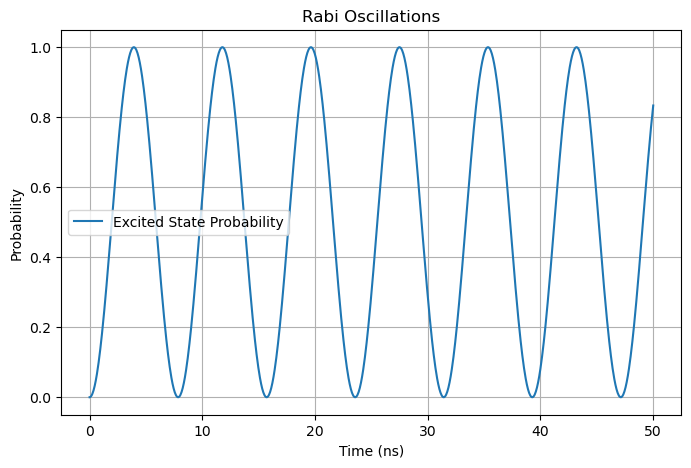

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,  
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

# 总仿真时长
t_list = np.linspace(0, 50, 1000)  # ns

# 创建Protocal对象，设置测量协议和参数
protocal = Protocal(
    type = 0,
    params = {
        't_list': t_list,
    }
)

# 运行测量协议
protocal.initialize(qubit,state = 0)

print(f"qubit state before evolution: {qubit.state}")

results = protocal.evolve(qubit)

# 分析结果
analysis = Analysis()

p_e = analysis.get_expectation_values(results, e_ops_index = 0)

# 绘制结果
plt.figure(figsize=(8, 5))
plt.plot(t_list, p_e, label='Excited State Probability')
plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Rabi Oscillations')
plt.legend()
plt.grid()
plt.show()



## test2: Ramsey 干涉
- 需要完善：无法模拟非恒定信号的情况，如包络是高斯函数时
- 由于响应函数为余弦函数的绝对值，因此还原磁场时首先要考虑余弦函数的周期性和对称性，可能会有多个解，需要结合实际参数值以及估计的磁场范围判断正负值。

phase: 70.11663204766569
Fitted detuning: 0.0492 GHz, Estimated magnetic field amplitude: 0.994067 Wb
Estimated magnetic field amplitude: 0.009991 Wb
Calculated detuning for 0.01 flux change: -0.0493 GHz
Cosine of flux change: -0.9941


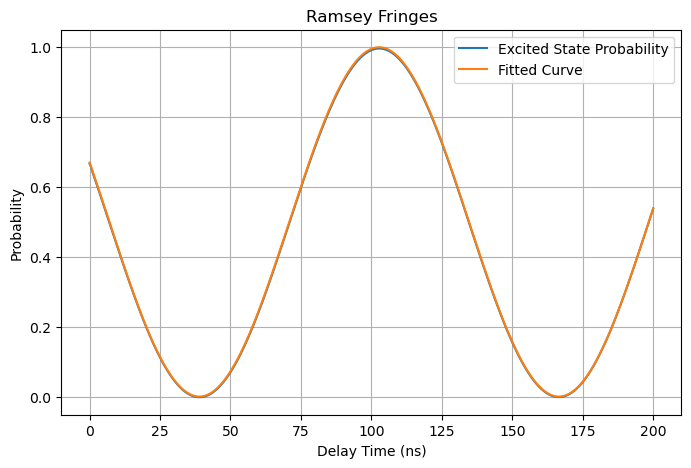

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)
Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
# 总仿真时长

protocal = Protocal(1)

protocal.initialize(qubit,state = 0)

tau_list, p_e_list, popt, pcov = protocal.evolve(qubit)
p_e_opt = lambda tau, A, Delta, phi: 0.5 * (1 + A * np.cos(Delta * tau + phi))
Delta_opt = popt[1]
phase = popt[2] * 180 / np.pi  # 将相位转换为度
print("phase:", phase)
cosPhi_amp = (((Delta_opt + qubit.frequency) + qubit.EC)**2)/(8 * qubit.EC * qubit.EJ_0)
Phi_amp = (1 / np.pi) * np.arccos(-abs(cosPhi_amp)) - qubit.flux
print(f"Fitted detuning: {Delta_opt:.4f} GHz, Estimated magnetic field amplitude: {cosPhi_amp:.6f} Wb")
print(f"Estimated magnetic field amplitude: {Phi_amp:.6f} Wb")
Delta = qubit.frequency - (np.sqrt(8 * qubit.EC * qubit.EJ_0 * abs(np.cos(np.pi * (qubit.flux + 0.01)))) - qubit.EC)
Cos = np.cos(np.pi * (qubit.flux + 0.01))
print(f"Calculated detuning for 0.01 flux change: {Delta:.4f} GHz")
print(f"Cosine of flux change: {Cos:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(tau_list, p_e_list, label='Excited State Probability')
plt.plot(tau_list, p_e_opt(tau_list, *popt), label='Fitted Curve')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Ramsey Fringes')
plt.legend()
plt.grid()
plt.show()


# test3: Ramsey干涉（加磁场）


In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubits = []
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
))

qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.15,
    state = 0,
    n_levels = 2
))
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.3,
    state = 0,
    n_levels = 2
))

# 总仿真时长

protocal = Protocal(1)

results = []
for i in range(3):
    protocal.initialize(qubits[i],state = 0)
    results.append(protocal.evolve(qubits[i]))



plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(protocal.params['tau_list'], results[i], label=f'Qubit {i+1} Excited State Probability')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Ramsey Fringes')
plt.legend()
plt.grid()
plt.show()


KeyboardInterrupt: 

# spin echo

c:\Users\21034\anaconda3\envs\qutip-env\Lib\site-packages\qutip\core\coefficient.py:192: RuntimeWarning: invalid value encountered in divide
  return coefficient_builders[type_](base, **kwargs)


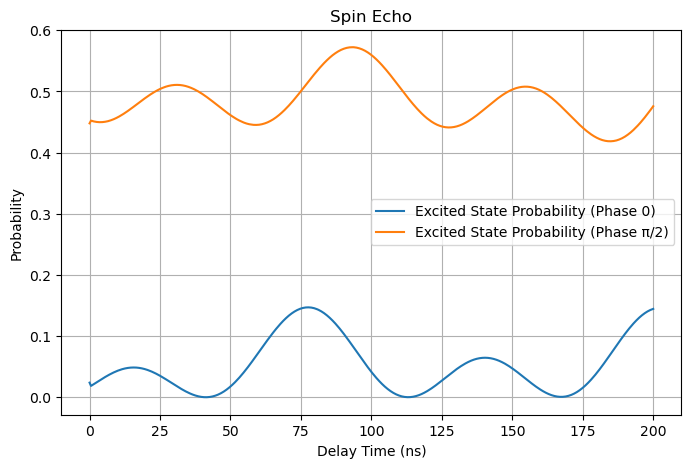

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)
Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
# 总仿真时长

protocal = Protocal(2)

protocal.initialize(qubit,state = 0)

tau_list, p_e_list = protocal.evolve(qubit)
plt.figure(figsize=(8, 5))
plt.plot(tau_list, p_e_list[0], label='Excited State Probability (Phase 0)')
plt.plot(tau_list, p_e_list[1], label='Excited State Probability (Phase π/2)')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Spin Echo')

plt.legend()
plt.grid()
plt.show()


## test4: 密度矩阵模拟求核函数
- stim脉冲的幅值不能太大（导致相位超过$2\pi$），也不能太小（小于脉冲信号幅值）
- 可以增加采样率以减少毛刺
- 由于stim脉冲并未理想delta函数，需要对核函数进行标准化（除以高斯函数面积），标准化后的核函数幅值不一定为1，且标准化后的核函数才可以用于准确还原磁场信号

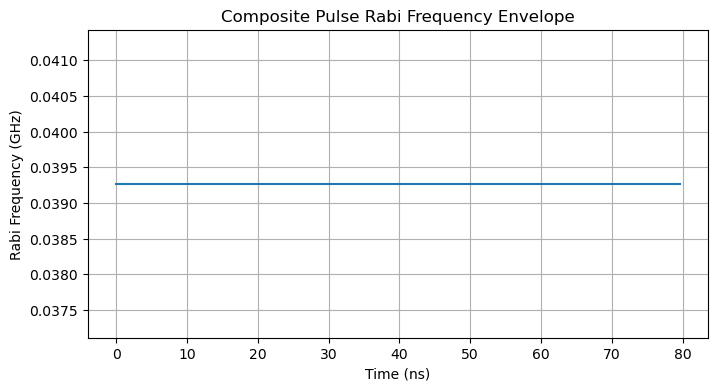

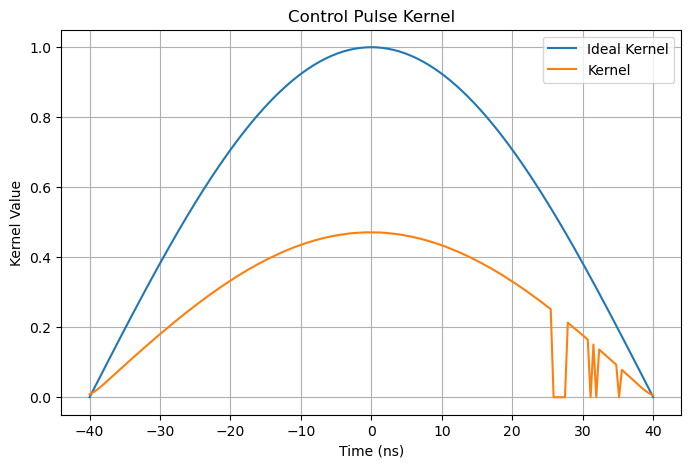

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()
# 使用列表函数代替lambda函数，用时为原来的1/3
control_pulse.get_kernel(qubit)
t_samples, kernel = control_pulse.t_samples, control_pulse.kernel
#t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
t_max = t_samples[max_index]
t_roll = t_samples - t_max
control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_roll]
plt.figure(figsize=(8, 5))
plt.plot(t_roll,kernel_id, label='Ideal Kernel')
plt.plot(t_roll, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

## test5: 瞬态磁场传感协议

注意EC和EJ的单位是rad GHz，T1和T2的单位是ns，频率的单位是GHz，时间的单位是ns。

使用列表函数运算时间是原来的2/3

对于存在突变的磁场还原效果不是很好，会出现振幅不一致，信号振荡的情况

工作点的选取对于还原结果也有影响，在最佳工作点处效果较好，形状和振幅都能还原，但是在其他工作点可以还原出形状，但是振幅不对

Qubit frequency at optimal work point: 23.7522 GHz
Work point flux: 0.9553


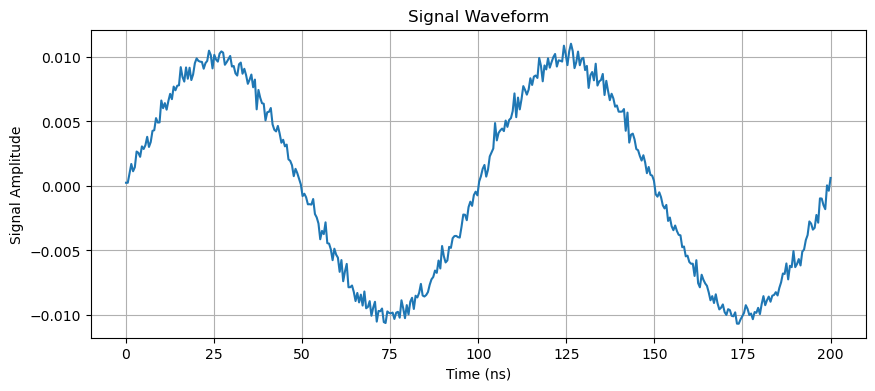

create control pulse
start measurement
Sliding measurement with 439 samples took 8.15 seconds
Sliding measurement with 439 samples took 3.60 seconds
Results saved to: result/diferent signal\transient_field_sensing_results(sinusoidal, wiener).png


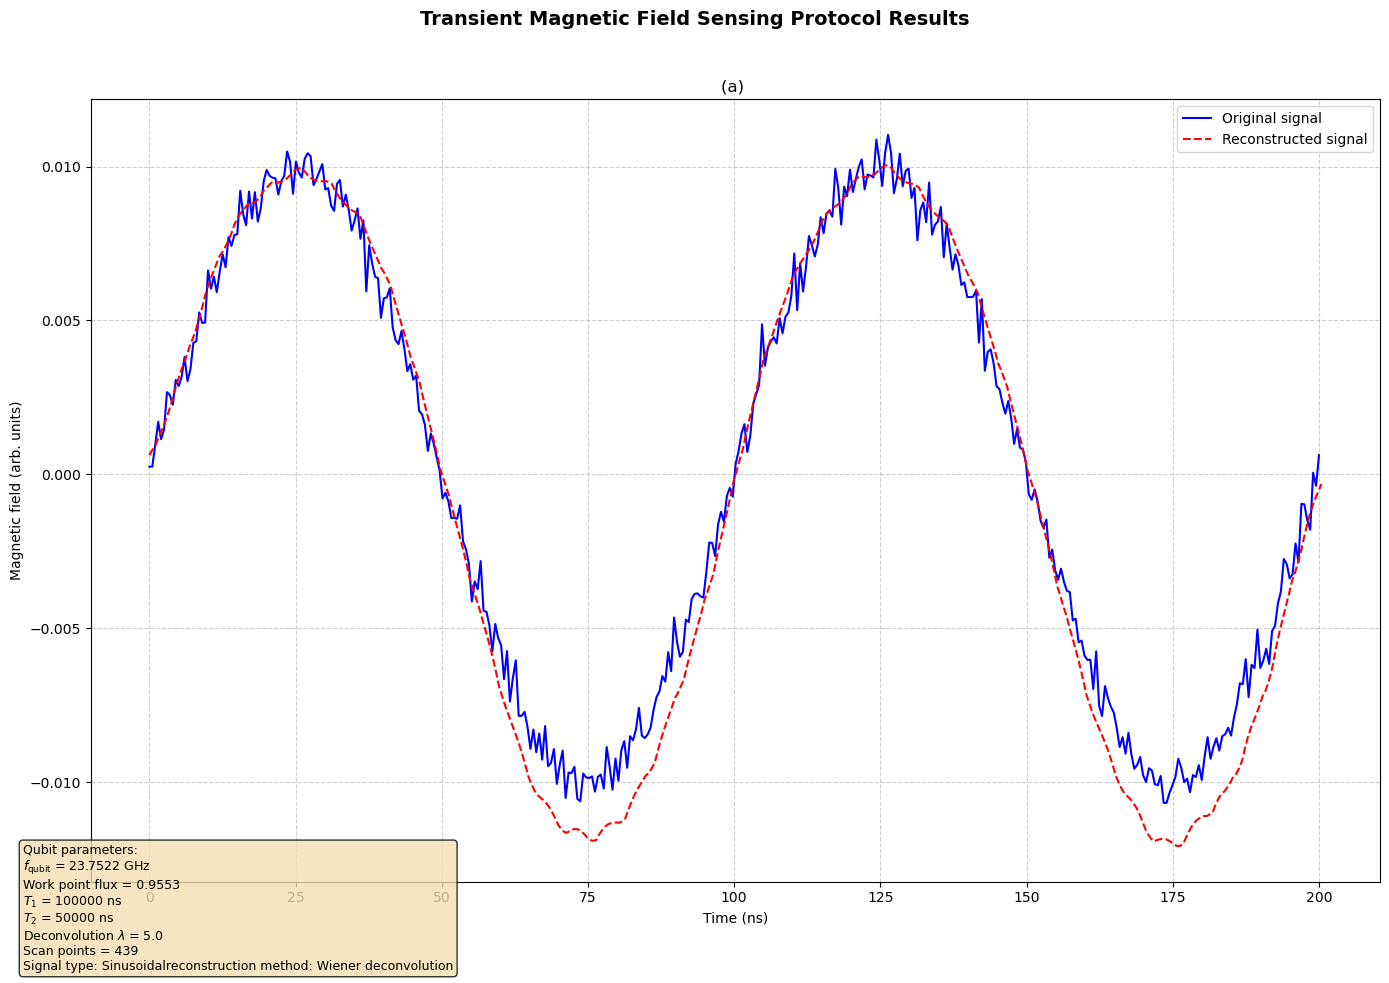

Data saved to: result/diferent signal\reconstruction_data(sinusoidal, wiener).npz


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象（与test5相同参数）
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
print(f"Qubit frequency at optimal work point: {qubit.frequency:.4f} GHz")
print(f"Work point flux: {qubit.flux:.4f}")

protocal = Protocal(4)
protocal.initialize(qubit, state=0)
# 获取所有返回值，包括原始磁场信号Phi
t_samples, kernel, scan_list, delta_p, p_e, Phi_signal, control_pulse = protocal.evolve(qubit)

analysis = Analysis()
dt = scan_list[1] - scan_list[0]
# 维纳反卷积，lambda=5.0
B_lists, B_recon = analysis.wiener_deconvolution(delta_p, kernel, dt, lambdas=5.0)

# 原始磁场信号
original_signal = Phi_signal.signal
original_time = Phi_signal.t_list

# 创建符合期刊标准的成果图
fig = plt.figure(figsize=(14, 10))
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})




# 子图4: 重建磁场 vs 原始磁场
ax4 = plt.subplot(1, 1, 1)
ax4.plot(original_time, original_signal, 'b--', linewidth=1.5, label='Original signal')
ax4.plot(B_lists, B_recon, 'r-', linewidth=1.5, label='Reconstructed signal')
ax4.set_xlabel('Time (ns)')
ax4.set_ylabel('Magnetic field (arb. units)')
ax4.set_title('(a) ')
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend()

# 添加信息文本框
# info_text = (
#     f'Qubit parameters:\n'
#     f'$f_{{\\mathrm{{qubit}}}}$ = {qubit.frequency:.4f} GHz\n'
#     f'Work point flux = {qubit.flux:.4f}\n'
#     f'$T_1$ = {qubit.T1:.0f} ns\n'
#     f'$T_2$ = {qubit.T2:.0f} ns\n'
#     f'Deconvolution $\\lambda$ = {5.0}\n'
#     f'Scan points = {len(scan_list)}\n'
#     f'Signal type: Sinusoidal'
#     f'reconstruction method: Wiener deconvolution'
# )
plt.figtext(0.02, 0.02, info_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Transient Magnetic Field Sensing Protocol Results', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.96])  # 为底部文本框留出空间

# 确保输出目录存在
output_dir = 'result/diferent signal'
os.makedirs(output_dir, exist_ok=True)

# 保存图形
output_path = os.path.join(output_dir, 'transient_field_sensing_results(sinusoidal, wiener).png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Results saved to: {output_path}')

# 显示图形
plt.show()

# 可选：保存数据供后续分析
data_path = os.path.join(output_dir, 'reconstruction_data(sinusoidal, wiener).npz')
np.savez(data_path,
         original_time=original_time,
         original_signal=original_signal,
         scan_list=scan_list,
         delta_p=delta_p,
         t_samples=t_samples,
         kernel=kernel,
         B_lists=B_lists,
         B_recon=B_recon)
print(f'Data saved to: {data_path}')

qubit frequency: 23.752187318820848


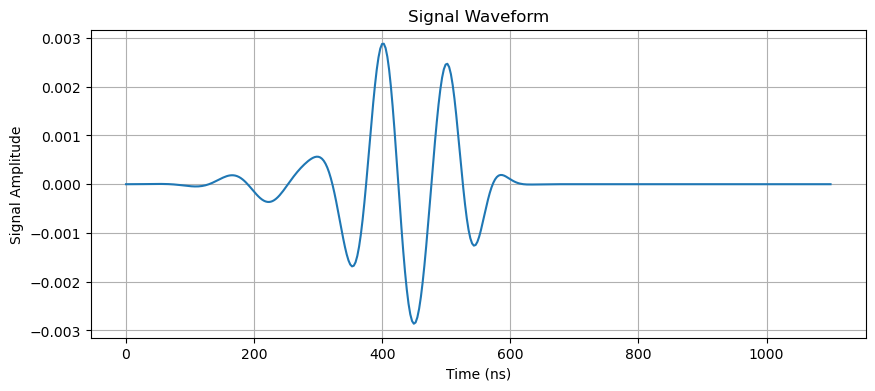

create control pulse
start measurement
Sliding measurement with 439 samples took 4.34 seconds
Sliding measurement with 439 samples took 3.22 seconds
t_samples: 40 ,scan_list: 439
B: [ 1.24183998e-05  9.24553781e-06  5.46582680e-06  1.25117942e-06
 -3.19444571e-06 -7.64528277e-06 -1.18714193e-05 -1.56464562e-05
 -1.87572766e-05 -2.10157297e-05 -2.22608760e-05 -2.23756130e-05
 -2.12896024e-05 -1.90306800e-05 -1.55746394e-05 -1.05977422e-05
 -4.53734574e-06  2.41978563e-06  9.99710164e-06  1.77387302e-05
  2.50531710e-05  3.12708964e-05  3.57238526e-05  3.77945336e-05
  3.69639610e-05  3.28194936e-05  2.50761822e-05  1.31975498e-05
  1.00830259e-06 -1.32703638e-05 -2.85723394e-05 -4.36448608e-05
 -5.73882199e-05 -6.89830947e-05 -7.77993740e-05 -8.33120212e-05
 -8.50861039e-05 -8.28599068e-05 -7.65409187e-05 -6.61302638e-05
 -5.17102380e-05 -3.35067521e-05 -1.19026083e-05  1.25507856e-05
  3.91123001e-05  6.68129127e-05  9.44629547e-05  1.20744560e-04
  1.44389703e-04  1.64350196e-04  1.79

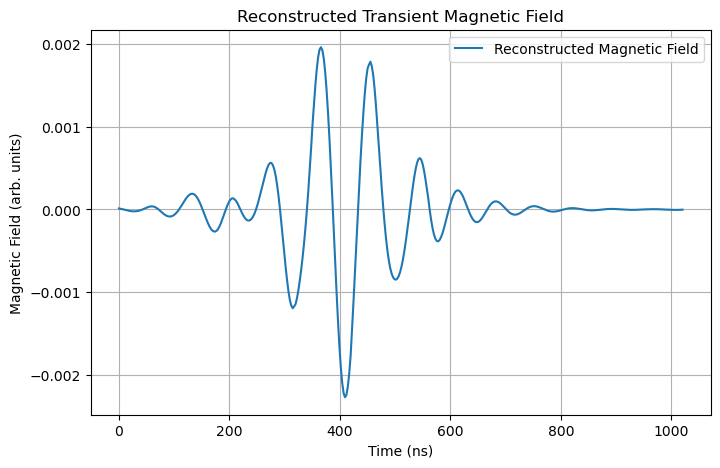

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
print(f"qubit frequency: {qubit.frequency}")
protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _= protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()



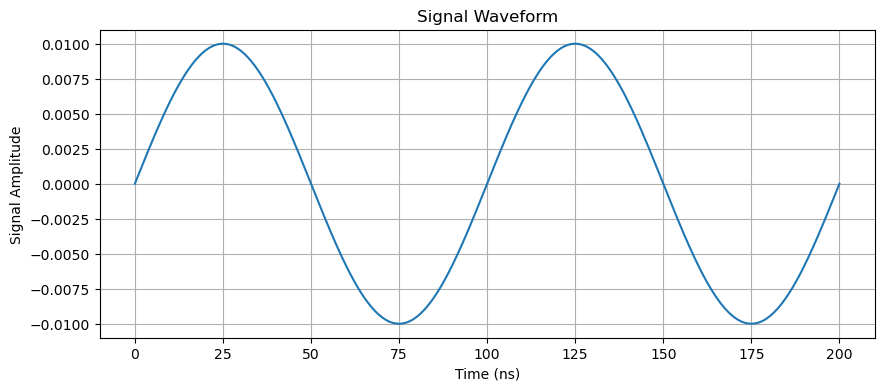

create control pulse
start measurement
Sliding measurement with 439 samples took 7.44 seconds
Sliding measurement with 439 samples took 26.42 seconds
t_samples: 40 ,scan_list: 439
B: [ 3.70549452e-03  2.88979126e-03  2.92535935e-03  5.11023289e-03
  6.78671512e-03  4.36783537e-03  4.99141083e-03  9.16373194e-03
  1.19824141e-02  1.48442870e-02  1.51023695e-02  1.86255761e-02
  1.37255228e-02  1.01158499e-02  1.24959083e-02  1.31717119e-02
  1.35052010e-02  1.40563465e-02  1.31014100e-02  1.39840638e-02
  1.84935541e-02  2.12780367e-02  1.91993194e-02  1.98258106e-02
  1.46375971e-02  7.91214971e-03  9.61071129e-03  1.07817825e-02
  1.13128058e-02  1.52208432e-02  1.42623868e-02  1.15574302e-02
  1.61491976e-02  1.86539106e-02  1.84939964e-02  1.81554174e-02
  1.18395645e-02  1.00312650e-02  1.27093067e-02  1.10146537e-02
  1.28048628e-02  9.84671775e-03  7.35815027e-03  5.77293886e-03
  7.16628008e-03  1.06774307e-02  7.23343211e-03  3.98089677e-03
  5.64980129e-03  5.83357082e-03  1.2

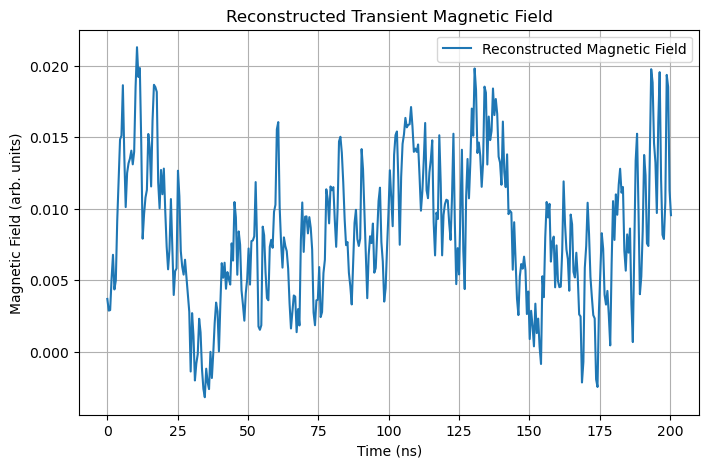

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _= protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


# 非线性响应优化：考虑hammerstein-wiener滤波

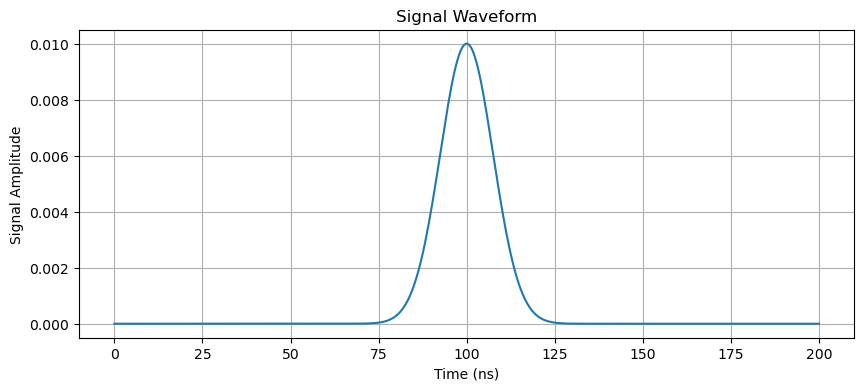

create control pulse
start measurement
Sliding measurement with 439 samples took 11.54 seconds
Sliding measurement with 439 samples took 9.69 seconds
t_samples: 40 ,scan_list: 439


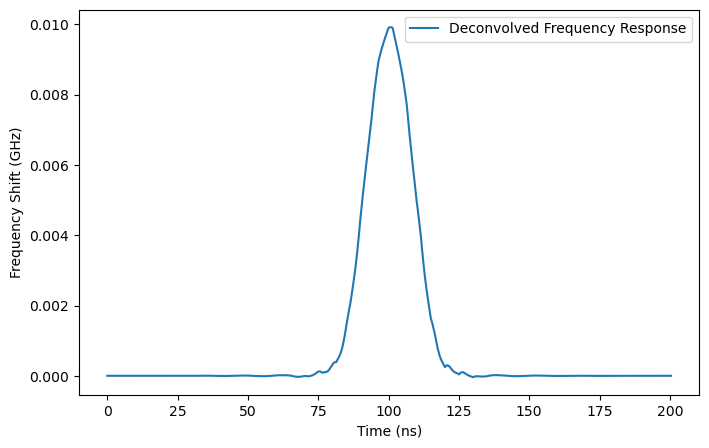

B: [5.92687724e-05 6.35015337e-05 6.58347382e-05 6.62512070e-05
 6.45167021e-05 6.04307184e-05 5.35508835e-05 4.26959854e-05
 2.39386050e-05            nan            nan            nan
            nan            nan            nan            nan
            nan            nan            nan            nan
            nan            nan 2.23148082e-05 5.40743518e-05
 7.32353832e-05 8.76172963e-05 9.85739050e-05 1.06501150e-04
 1.11506898e-04 1.13547481e-04 1.12408553e-04 1.07906043e-04
 9.95109920e-05 8.64062107e-05 6.65624537e-05 3.03900325e-05
            nan            nan            nan            nan
            nan            nan            nan            nan
            nan            nan            nan            nan
            nan 3.87679790e-05 8.74648456e-05 1.17402487e-04
 1.39850334e-04 1.56905813e-04 1.69196962e-04 1.76880854e-04
 1.79860122e-04 1.77913973e-04 1.70615074e-04 1.57277816e-04
 1.36606321e-04 1.05417480e-04 4.91236581e-05            nan
            nan      

c:\Users\21034\Desktop\Workspace\Sensing project\Sensing-Project\src\analysis.py:168: RuntimeWarning: invalid value encountered in arccos
  B = (1 / np.pi) * np.arccos((omega + qubit.frequency + qubit.EC) ** 2 / (8 * qubit.EC * qubit.EJ) )   # 根据Transmon的频率-磁场关系，得到磁场响应


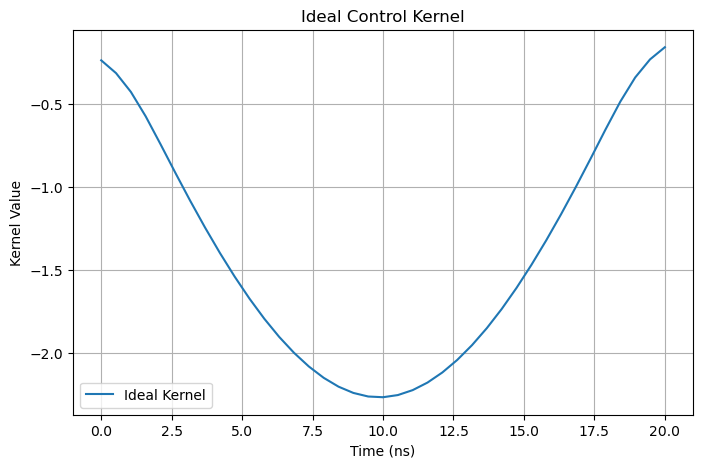

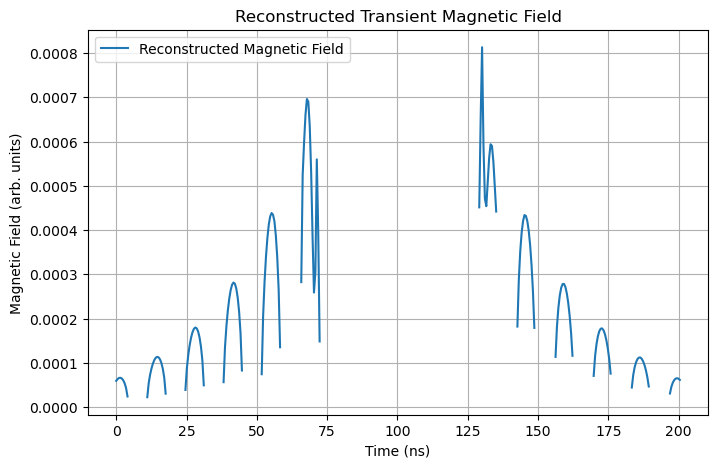

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _ = protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.hammerstein_wiener_deconvolution(qubit, results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')

plt.figure(figsize=(8, 5))
plt.plot(t_samples, kernel, label='Ideal Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Ideal Control Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


# 非线性响应优化：全密度矩阵模拟
问题
- 使用BSpline基时，伴随法求的雅可比矩阵与有限差分法求的雅可比矩阵不一致
- B_guess本来就是从原磁场反卷积得到，res应该较小，实际为0.06左右。
- 使用fourier基时，在第二次迭代之后，res保持在0.041902，但是res本应该在0处收敛。检查优化算法的实现，极小点应该在res=0处
- 还原的磁场随res减小开始振荡，比res较大时更偏离设定磁场h
- 前向传播和伴随法求雅可比矩阵的时间为5秒左右，可优化
- 思考这个方法能否在实际中使用：能否完美适应出实验环境，能否还原出磁场信号，能否在合理时间内完成优化。

性能
- 在两轮循环之后可以基本还原原磁场的大致形状和幅值，但是对于细节部分不能很好还原，并且res值最多可以优化到0.02，数量级上较高于tol，因此还原出的波形会有一些瑕疵，且如果原磁场比较复杂，或者有突变，则还原结果可能会振荡

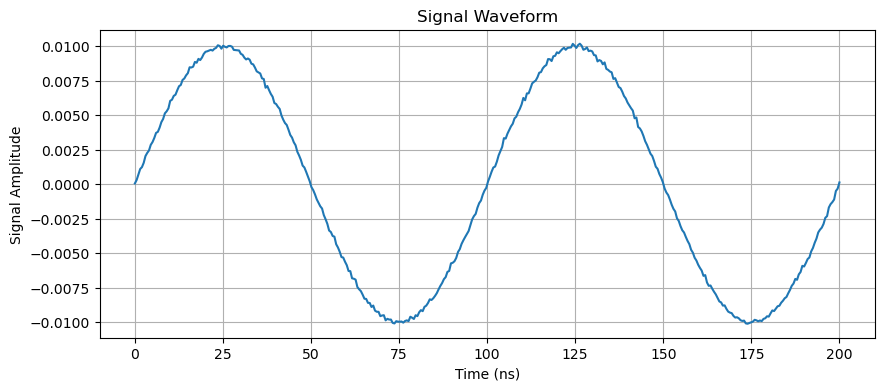

create control pulse
start measurement
Sliding measurement with 439 samples took 7.26 seconds
Sliding measurement with 439 samples took 3.40 seconds
B: [ 4.98547013e-04  6.63367942e-04  8.15764014e-04  1.05296168e-03
  1.29265629e-03  1.54453091e-03  1.82732873e-03  2.14755807e-03
  2.50228847e-03  2.88219730e-03  3.21535173e-03  3.52549400e-03
  3.78660789e-03  4.10416598e-03  4.39935395e-03  4.65204778e-03
  4.93439350e-03  5.25854031e-03  5.61724965e-03  5.99799902e-03
  6.30465877e-03  6.57256660e-03  6.77857766e-03  7.01859708e-03
  7.23371587e-03  7.35791368e-03  7.51555793e-03  7.70749786e-03
  7.94206127e-03  8.21252475e-03  8.39571078e-03  8.54536707e-03
  8.63353186e-03  8.75375536e-03  8.85896696e-03  8.84366250e-03
  8.87719403e-03  8.96335955e-03  9.09501915e-03  9.26741251e-03
  9.35604640e-03  9.47100818e-03  9.55601392e-03  9.54337886e-03
  9.54389479e-03  9.56278212e-03  9.61065082e-03  9.68814001e-03
  9.78481808e-03  9.89241589e-03  9.96640225e-03  1.00031204e-02
  1

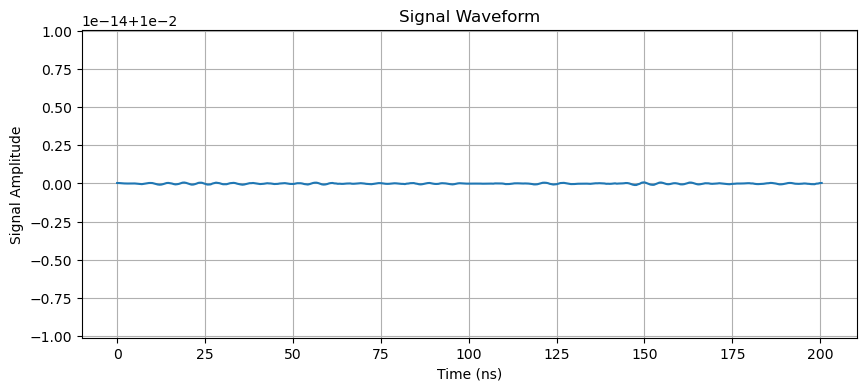

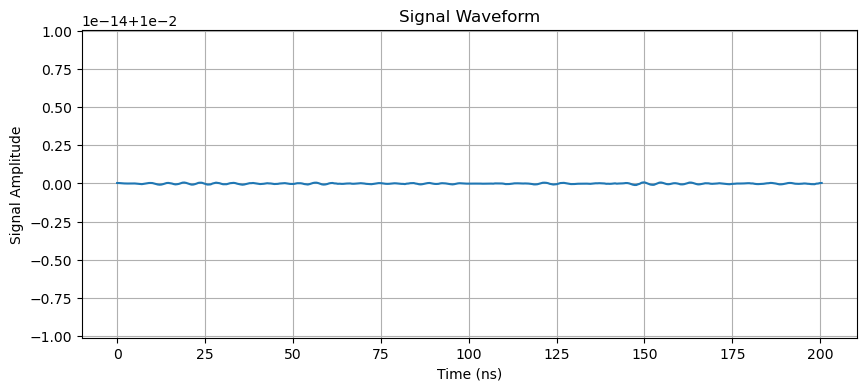

Forward simulation time: 3.46 s
Jacobian computation time: 7.22 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.304157, adj=0.304160, ratio=1.0000
  t=50.23: fd=0.304157, adj=0.304160, ratio=1.0000
  t=100.46: fd=0.304157, adj=0.304160, ratio=1.0000
  t=150.68: fd=0.304157, adj=0.304160, ratio=1.0000
  t=200.41: fd=0.304157, adj=0.304160, ratio=1.0000
Forward simulation time: 3.56 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.18392086e-08 -2.99583198e-03 -1.18796085e-02
 -2.65119493e-02]
FinDiff J[:,0] = [ 2.16149321e-07 -2.32741271e-04 -3.62243219e-03 -1.26199419e-02
 -2.75001670e-02]
Ratio: [0.00000000e+00 5.08685397e-05 8.27022239e-01 9.41336227e-01
 9.64065029e-01]
Forward simulation time: 5.48 s
Iter 0: res=7.317902, res_trial=2.247454, mu=5.000000e-04


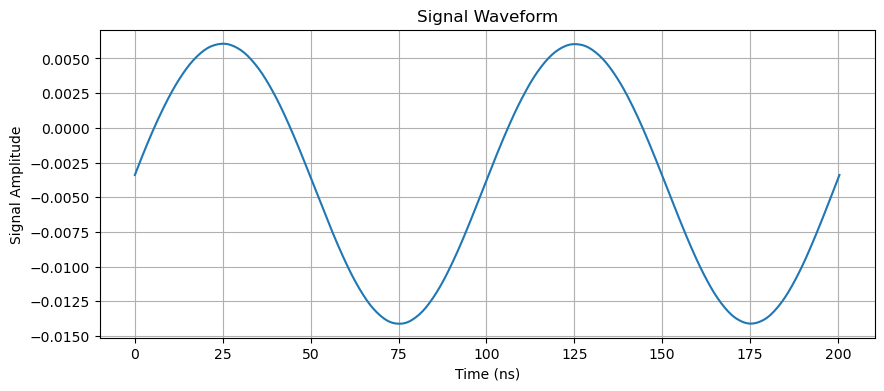

Forward simulation time: 5.56 s
Jacobian computation time: 10.15 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.422052, adj=0.422056, ratio=1.0000
  t=50.23: fd=0.424890, adj=0.424893, ratio=1.0000
  t=100.46: fd=0.422932, adj=0.422935, ratio=1.0000
  t=150.68: fd=0.426293, adj=0.426296, ratio=1.0000
  t=200.41: fd=0.422052, adj=0.422056, ratio=1.0000
Forward simulation time: 5.58 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.62815289e-08 -4.12530920e-03 -1.64095667e-02
 -3.65221779e-02]
FinDiff J[:,0] = [-8.96167807e-05  1.51302585e-03 -8.62579489e-03 -1.85035169e-02
 -3.65435606e-02]
Ratio: [-0.00000000e+00 -1.07609060e-05  4.78252643e-01  8.86835013e-01
  9.99414872e-01]
Forward simulation time: 5.50 s
Iter 1: res=2.247454, res_trial=0.202267, mu=2.500000e-04


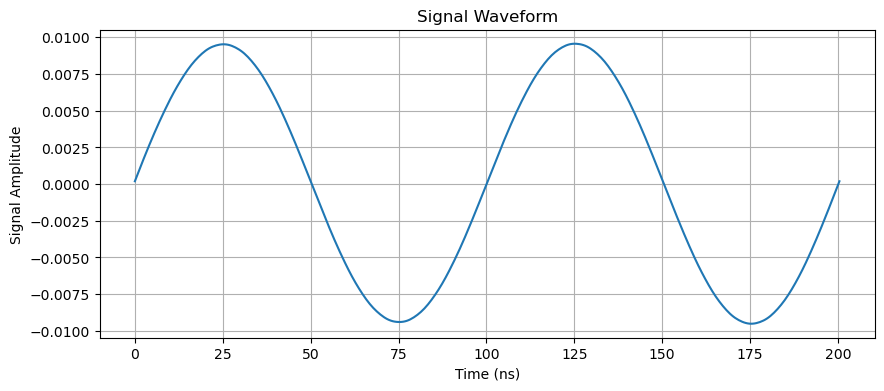

Forward simulation time: 5.56 s
Jacobian computation time: 9.98 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.390421, adj=0.390424, ratio=1.0000
  t=50.23: fd=0.391712, adj=0.391715, ratio=1.0000
  t=100.46: fd=0.389849, adj=0.389852, ratio=1.0000
  t=150.68: fd=0.393105, adj=0.393108, ratio=1.0000
  t=200.41: fd=0.390421, adj=0.390424, ratio=1.0000
Forward simulation time: 5.51 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.50580778e-08 -3.81667717e-03 -1.51703084e-02
 -3.37581222e-02]
FinDiff J[:,0] = [ 0.00169749  0.00548441 -0.00459532 -0.01646461 -0.03345153]
Ratio: [ 0.00000000e+00 -2.74561719e-06  8.30557729e-01  9.21388806e-01
  1.00916541e+00]
Forward simulation time: 5.60 s
Iter 2: res=0.202267, res_trial=0.073637, mu=1.250000e-04


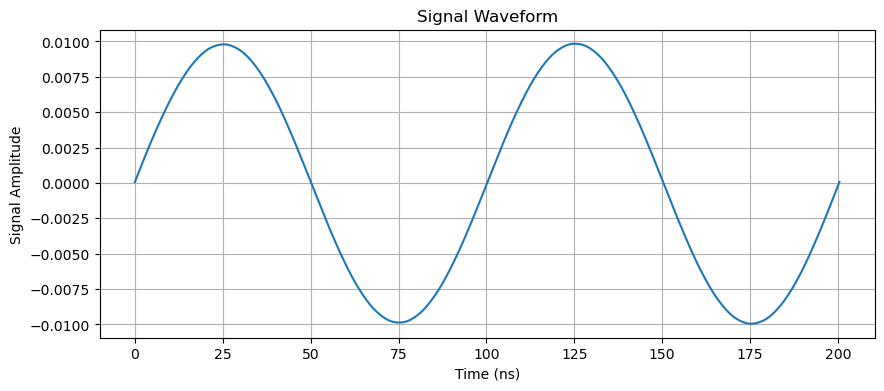

Forward simulation time: 5.49 s
Jacobian computation time: 10.12 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391529, adj=0.391532, ratio=1.0000
  t=50.23: fd=0.392555, adj=0.392558, ratio=1.0000
  t=100.46: fd=0.390661, adj=0.390664, ratio=1.0000
  t=150.68: fd=0.393922, adj=0.393925, ratio=1.0000
  t=200.41: fd=0.391529, adj=0.391532, ratio=1.0000
Forward simulation time: 5.50 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.50979697e-08 -3.82678469e-03 -1.52108560e-02
 -3.38451481e-02]
FinDiff J[:,0] = [-0.00153935 -0.00517541 -0.00019848 -0.01691755 -0.02800783]
Ratio: [-0.00000000e+00  2.91725111e-06  1.92802328e+01  8.99117041e-01
  1.20841742e+00]
Forward simulation time: 5.57 s
Iter 3: res=0.073637, res_trial=0.062660, mu=6.250000e-05


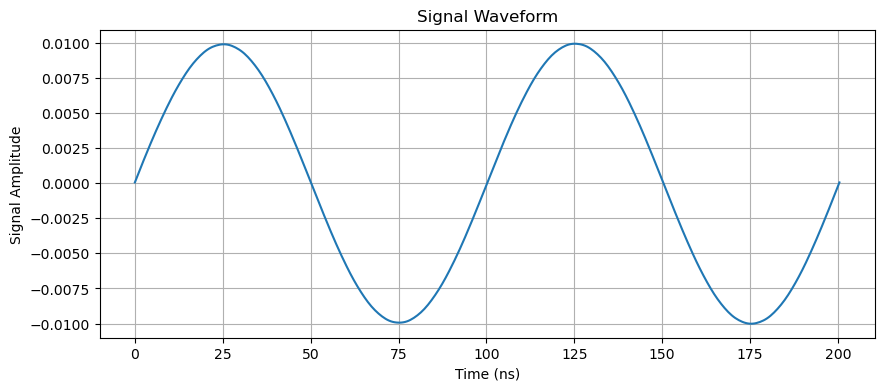

Forward simulation time: 5.59 s
Jacobian computation time: 10.14 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391593, adj=0.391597, ratio=1.0000
  t=50.23: fd=0.392509, adj=0.392513, ratio=1.0000
  t=100.46: fd=0.390618, adj=0.390621, ratio=1.0000
  t=150.68: fd=0.393903, adj=0.393906, ratio=1.0000
  t=200.41: fd=0.391593, adj=0.391597, ratio=1.0000
Forward simulation time: 5.54 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51002298e-08 -3.82735722e-03 -1.52131537e-02
 -3.38499553e-02]
FinDiff J[:,0] = [-0.00123473  0.0008823  -0.00447948 -0.01756707 -0.03440123]
Ratio: [-0.00000000e+00 -1.71145821e-05  8.54420792e-01  8.66004211e-01
  9.83975133e-01]
Forward simulation time: 5.57 s
Iter 4: res=0.062660, res_trial=0.061390, mu=3.125000e-05


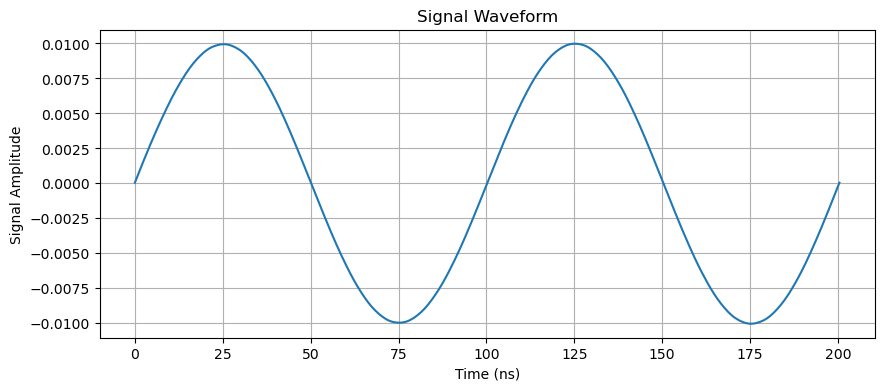

Forward simulation time: 5.58 s
Jacobian computation time: 10.30 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391676, adj=0.391679, ratio=1.0000
  t=50.23: fd=0.392538, adj=0.392541, ratio=1.0000
  t=100.46: fd=0.390644, adj=0.390648, ratio=1.0000
  t=150.68: fd=0.393933, adj=0.393936, ratio=1.0000
  t=200.41: fd=0.391676, adj=0.391679, ratio=1.0000
Forward simulation time: 5.59 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51037155e-08 -3.82824044e-03 -1.52166967e-02
 -3.38582252e-02]
FinDiff J[:,0] = [ 0.00120663  0.00055352 -0.00756068 -0.01663537 -0.03620623]
Ratio: [ 0.00000000e+00 -2.72866839e-05  5.06335189e-01  9.14719601e-01
  9.35149135e-01]
Forward simulation time: 5.53 s
Iter 5: res=0.061390, res_trial=0.060928, mu=1.562500e-05


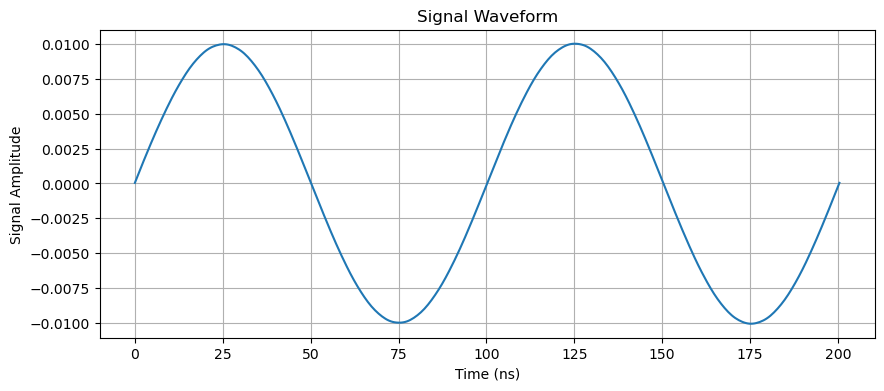

Forward simulation time: 5.62 s
Jacobian computation time: 10.09 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391742, adj=0.391745, ratio=1.0000
  t=50.23: fd=0.392572, adj=0.392575, ratio=1.0000
  t=100.46: fd=0.390675, adj=0.390679, ratio=1.0000
  t=150.68: fd=0.393959, adj=0.393962, ratio=1.0000
  t=200.41: fd=0.391742, adj=0.391745, ratio=1.0000
Forward simulation time: 5.46 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51065816e-08 -3.82896669e-03 -1.52196098e-02
 -3.38651476e-02]
FinDiff J[:,0] = [-0.00193682  0.00375654 -0.00321978 -0.01374331 -0.03150013]
Ratio: [-0.00000000e+00 -4.02141169e-06  1.18920021e+00  1.10741922e+00
  1.07507972e+00]
Forward simulation time: 5.68 s
Iter 6: res=0.060928, res_trial=0.060662, mu=7.812500e-06


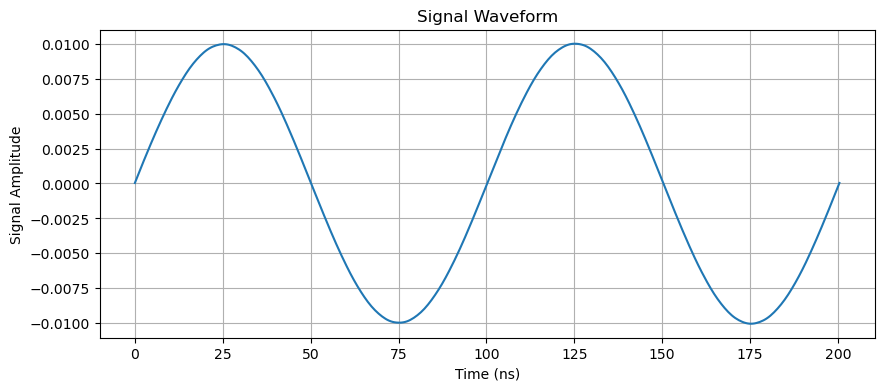

Forward simulation time: 5.71 s
Jacobian computation time: 10.59 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391789, adj=0.391792, ratio=1.0000
  t=50.23: fd=0.392597, adj=0.392600, ratio=1.0000
  t=100.46: fd=0.390699, adj=0.390702, ratio=1.0000
  t=150.68: fd=0.393977, adj=0.393980, ratio=1.0000
  t=200.41: fd=0.391789, adj=0.391792, ratio=1.0000
Forward simulation time: 5.65 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51086754e-08 -3.82949724e-03 -1.52217377e-02
 -3.38702478e-02]
FinDiff J[:,0] = [-0.00074381 -0.00165691 -0.007186   -0.0169569  -0.03559   ]
Ratio: [-0.00000000e+00  9.11861068e-06  5.32910782e-01  8.97672161e-01
  9.51678849e-01]
Forward simulation time: 5.91 s
Iter 7: res=0.060662, res_trial=0.060496, mu=3.906250e-06


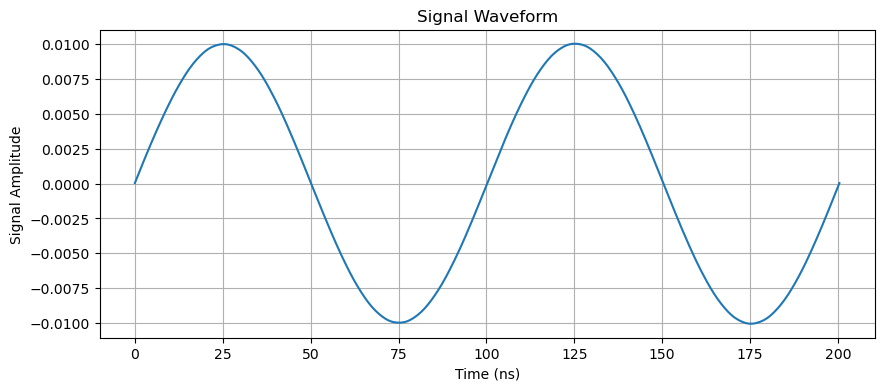

Forward simulation time: 5.34 s
Jacobian computation time: 10.13 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391822, adj=0.391825, ratio=1.0000
  t=50.23: fd=0.392615, adj=0.392618, ratio=1.0000
  t=100.46: fd=0.390715, adj=0.390718, ratio=1.0000
  t=150.68: fd=0.393988, adj=0.393991, ratio=1.0000
  t=200.41: fd=0.391822, adj=0.391825, ratio=1.0000
Forward simulation time: 6.01 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51101761e-08 -3.82987751e-03 -1.52232629e-02
 -3.38739415e-02]
FinDiff J[:,0] = [ 0.00251206 -0.00706276 -0.00890663 -0.01244666 -0.04231766]
Ratio: [0.00000000e+00 2.13941414e-06 4.30003167e-01 1.22308004e+00
 8.00468159e-01]
Forward simulation time: 5.61 s
Iter 8: res=0.060496, res_trial=0.060392, mu=1.953125e-06


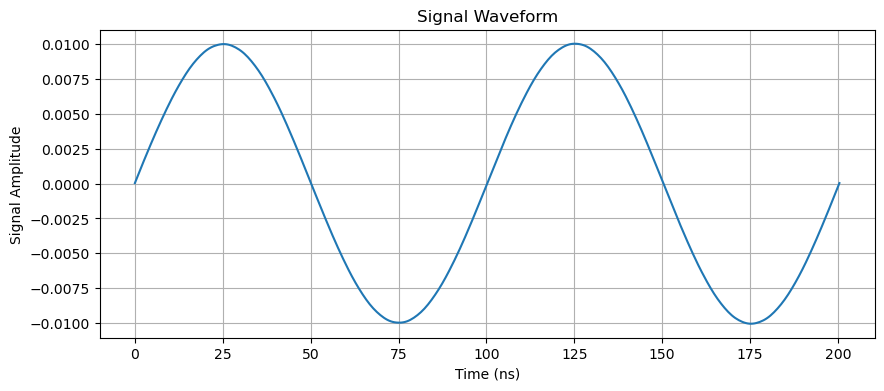

Forward simulation time: 5.98 s
Jacobian computation time: 10.32 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391845, adj=0.391848, ratio=1.0000
  t=50.23: fd=0.392628, adj=0.392631, ratio=1.0000
  t=100.46: fd=0.390725, adj=0.390728, ratio=1.0000
  t=150.68: fd=0.393996, adj=0.393999, ratio=1.0000
  t=200.41: fd=0.391845, adj=0.391848, ratio=1.0000
Forward simulation time: 5.31 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51112563e-08 -3.83015121e-03 -1.52243608e-02
 -3.38766443e-02]
FinDiff J[:,0] = [-0.00041598  0.00047707 -0.00243504 -0.01496322 -0.03030466]
Ratio: [-0.00000000e+00 -3.16749261e-05  1.57293296e+00  1.01745194e+00
  1.11786928e+00]
Forward simulation time: 5.92 s
Iter 9: res=0.060392, res_trial=0.060324, mu=9.765625e-07


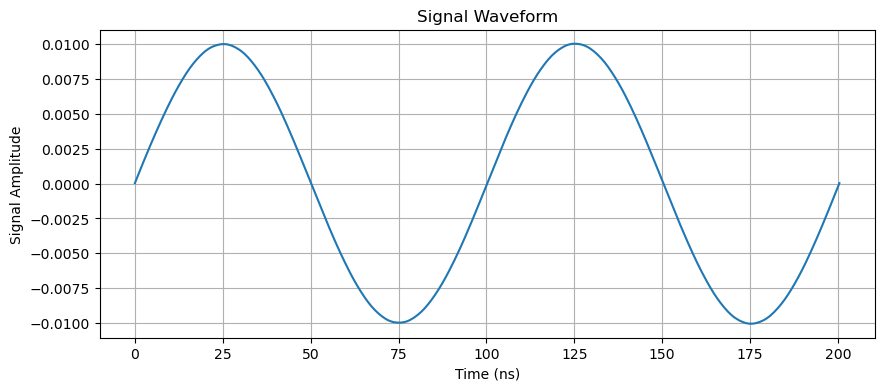

Forward simulation time: 5.64 s
Jacobian computation time: 10.35 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391861, adj=0.391864, ratio=1.0000
  t=50.23: fd=0.392637, adj=0.392640, ratio=1.0000
  t=100.46: fd=0.390732, adj=0.390735, ratio=1.0000
  t=150.68: fd=0.394002, adj=0.394005, ratio=1.0000
  t=200.41: fd=0.391861, adj=0.391864, ratio=1.0000
Forward simulation time: 5.35 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51120406e-08 -3.83034995e-03 -1.52251578e-02
 -3.38786423e-02]
FinDiff J[:,0] = [-0.00448867 -0.00058227 -0.00517601 -0.01121638 -0.03665851]
Ratio: [-0.00000000e+00  2.59534746e-05  7.40019913e-01  1.35740374e+00
  9.24168609e-01]
Forward simulation time: 5.75 s
Iter 10: res=0.060324, res_trial=0.060280, mu=4.882813e-07


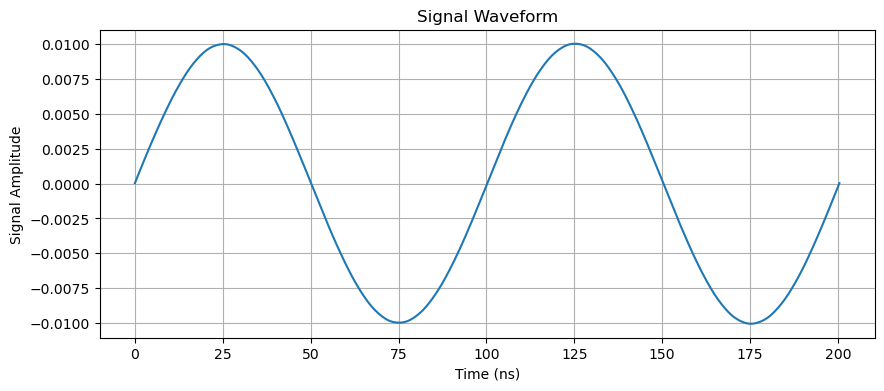

Forward simulation time: 5.38 s
Jacobian computation time: 10.19 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391873, adj=0.391876, ratio=1.0000
  t=50.23: fd=0.392644, adj=0.392647, ratio=1.0000
  t=100.46: fd=0.390736, adj=0.390739, ratio=1.0000
  t=150.68: fd=0.394006, adj=0.394009, ratio=1.0000
  t=200.41: fd=0.391873, adj=0.391876, ratio=1.0000
Forward simulation time: 5.58 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51126124e-08 -3.83049488e-03 -1.52257390e-02
 -3.38800792e-02]
FinDiff J[:,0] = [ 0.0010695   0.00121036 -0.00577111 -0.01562403 -0.04019573]
Ratio: [ 0.00000000e+00 -1.24860915e-05  6.63736097e-01  9.74507602e-01
  8.42877620e-01]
Forward simulation time: 5.37 s
Iter 11: res=0.060280, res_trial=0.060251, mu=2.441406e-07


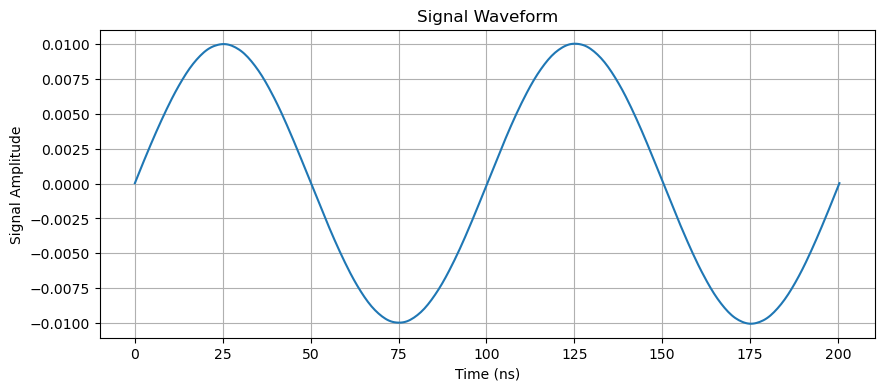

Forward simulation time: 5.35 s
Jacobian computation time: 10.22 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391881, adj=0.391884, ratio=1.0000
  t=50.23: fd=0.392648, adj=0.392651, ratio=1.0000
  t=100.46: fd=0.390739, adj=0.390742, ratio=1.0000
  t=150.68: fd=0.394009, adj=0.394012, ratio=1.0000
  t=200.41: fd=0.391881, adj=0.391884, ratio=1.0000
Forward simulation time: 5.63 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51130285e-08 -3.83060033e-03 -1.52261618e-02
 -3.38811031e-02]
FinDiff J[:,0] = [ 0.0061807  -0.00740576 -0.00350096 -0.01486462 -0.03914287]
Ratio: [0.00000000e+00 2.04071354e-06 1.09415701e+00 1.02432237e+00
 8.65575379e-01]
Forward simulation time: 5.52 s
Iter 12: res=0.060251, res_trial=0.060232, mu=1.220703e-07


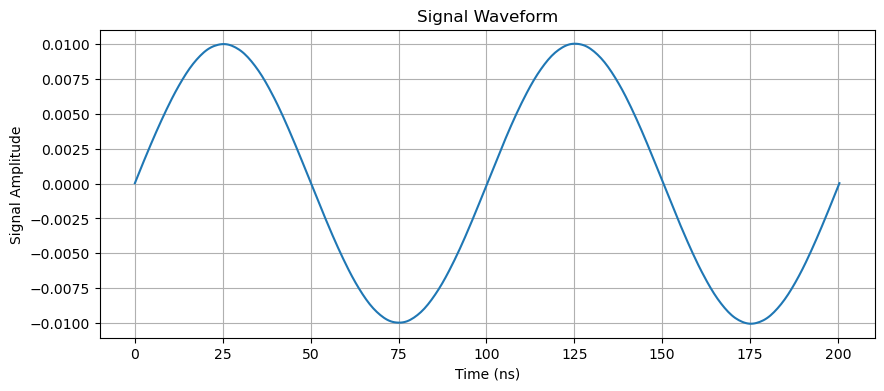

Forward simulation time: 5.62 s
Jacobian computation time: 10.08 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391887, adj=0.391890, ratio=1.0000
  t=50.23: fd=0.392652, adj=0.392655, ratio=1.0000
  t=100.46: fd=0.390740, adj=0.390743, ratio=1.0000
  t=150.68: fd=0.394011, adj=0.394014, ratio=1.0000
  t=200.41: fd=0.391887, adj=0.391890, ratio=1.0000
Forward simulation time: 5.80 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51133284e-08 -3.83067634e-03 -1.52264665e-02
 -3.38820280e-02]
FinDiff J[:,0] = [-0.00801394 -0.00145032 -0.00312554 -0.01676956 -0.02560533]
Ratio: [-0.00000000e+00  1.04206636e-05  1.22560506e+00  9.07982681e-01
  1.32324098e+00]
Forward simulation time: 5.27 s
Iter 13: res=0.060232, res_trial=0.060219, mu=6.103516e-08


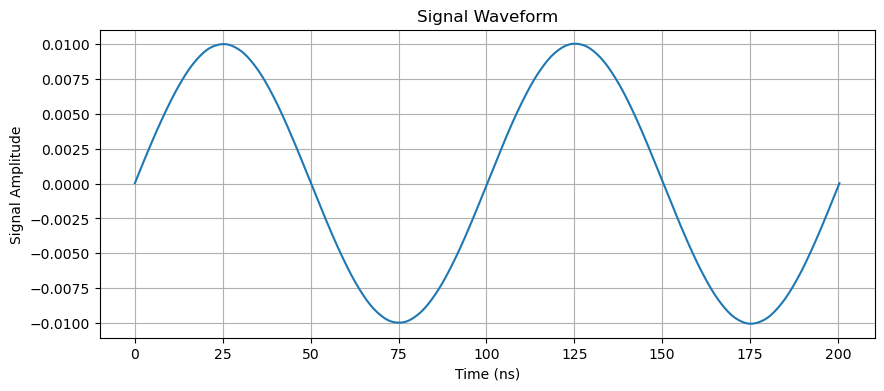

Forward simulation time: 6.02 s
Jacobian computation time: 9.89 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391890, adj=0.391893, ratio=1.0000
  t=50.23: fd=0.392655, adj=0.392658, ratio=1.0000
  t=100.46: fd=0.390741, adj=0.390744, ratio=1.0000
  t=150.68: fd=0.394013, adj=0.394016, ratio=1.0000
  t=200.41: fd=0.391890, adj=0.391893, ratio=1.0000
Forward simulation time: 5.63 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51135399e-08 -3.83072993e-03 -1.52266814e-02
 -3.38826148e-02]
FinDiff J[:,0] = [ 0.00121375  0.00183819  0.00029405 -0.01342684 -0.0365755 ]
Ratio: [ 0.00000000e+00 -8.22195479e-06 -1.30273243e+01  1.13404828e+00
  9.26374716e-01]
Forward simulation time: 5.08 s
Iter 14: res=0.060219, res_trial=0.060210, mu=3.051758e-08


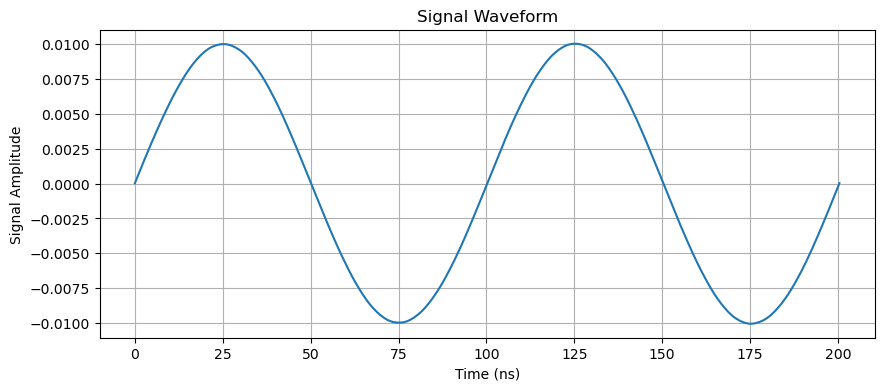

Forward simulation time: 5.67 s
Jacobian computation time: 10.25 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391892, adj=0.391896, ratio=1.0000
  t=50.23: fd=0.392658, adj=0.392661, ratio=1.0000
  t=100.46: fd=0.390740, adj=0.390743, ratio=1.0000
  t=150.68: fd=0.394015, adj=0.394018, ratio=1.0000
  t=200.41: fd=0.391892, adj=0.391896, ratio=1.0000
Forward simulation time: 5.70 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51136836e-08 -3.83076637e-03 -1.52268274e-02
 -3.38830313e-02]
FinDiff J[:,0] = [-0.00083872  0.00593948  0.00080696 -0.01254472 -0.02959397]
Ratio: [-0.00000000e+00 -2.54461460e-06 -4.74712902e+00  1.21380329e+00
  1.14493040e+00]
Forward simulation time: 5.11 s
Iter 15: res=0.060210, res_trial=0.060203, mu=1.525879e-08


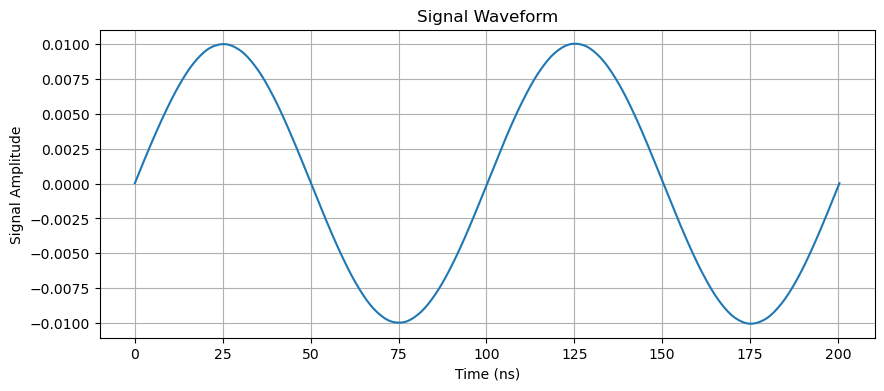

Forward simulation time: 5.78 s
Jacobian computation time: 10.19 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391894, adj=0.391897, ratio=1.0000
  t=50.23: fd=0.392660, adj=0.392663, ratio=1.0000
  t=100.46: fd=0.390740, adj=0.390743, ratio=1.0000
  t=150.68: fd=0.394016, adj=0.394019, ratio=1.0000
  t=200.41: fd=0.391894, adj=0.391897, ratio=1.0000
Forward simulation time: 5.59 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51137745e-08 -3.83078941e-03 -1.52269198e-02
 -3.38833149e-02]
FinDiff J[:,0] = [ 0.00041186  0.00421056 -0.01512791 -0.01686191 -0.04476871]
Ratio: [ 0.00000000e+00 -3.58949344e-06  2.53226547e-01  9.03036244e-01
  7.56852670e-01]
Forward simulation time: 5.17 s
Iter 16: res=0.060203, res_trial=0.060199, mu=1.000000e-08


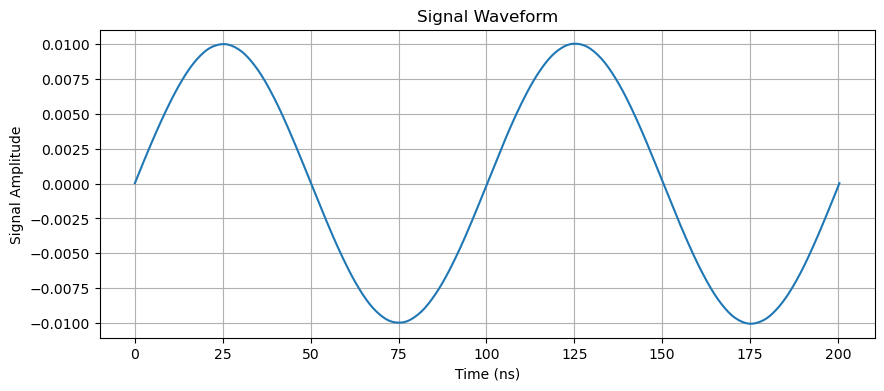

Forward simulation time: 5.59 s
Jacobian computation time: 10.13 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391894, adj=0.391897, ratio=1.0000
  t=50.23: fd=0.392662, adj=0.392665, ratio=1.0000
  t=100.46: fd=0.390738, adj=0.390742, ratio=1.0000
  t=150.68: fd=0.394017, adj=0.394020, ratio=1.0000
  t=200.41: fd=0.391894, adj=0.391897, ratio=1.0000
Forward simulation time: 5.79 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51138241e-08 -3.83080201e-03 -1.52269702e-02
 -3.38834939e-02]
FinDiff J[:,0] = [-0.00291958 -0.00249875 -0.00987317 -0.01481639 -0.03200768]
Ratio: [-0.00000000e+00  6.04856437e-06  3.88001164e-01  1.02771099e+00
  1.05860512e+00]
Forward simulation time: 5.22 s
Iter 17: res=0.060199, res_trial=0.060195, mu=1.000000e-08


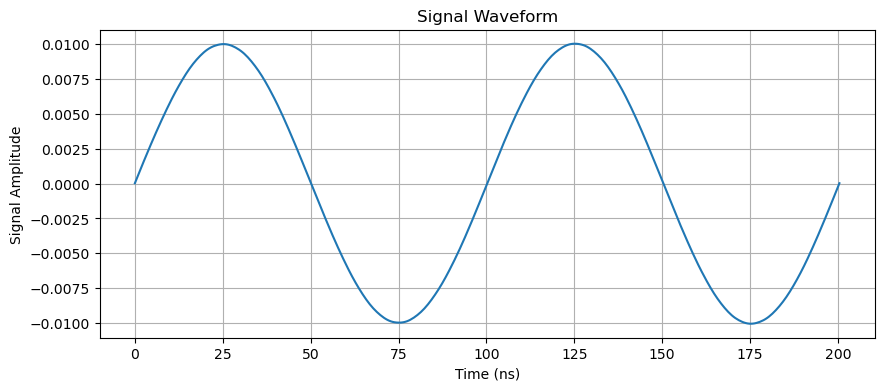

Forward simulation time: 5.90 s
Jacobian computation time: 10.30 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391893, adj=0.391896, ratio=1.0000
  t=50.23: fd=0.392664, adj=0.392667, ratio=1.0000
  t=100.46: fd=0.390737, adj=0.390740, ratio=1.0000
  t=150.68: fd=0.394018, adj=0.394021, ratio=1.0000
  t=200.41: fd=0.391893, adj=0.391896, ratio=1.0000
Forward simulation time: 5.68 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51138414e-08 -3.83080639e-03 -1.52269877e-02
 -3.38835909e-02]
FinDiff J[:,0] = [ 0.00200889  0.0020019   0.00205936 -0.01350486 -0.03171384]
Ratio: [ 0.00000000e+00 -7.54974260e-06 -1.86018932e+00  1.12751910e+00
  1.06841637e+00]
Forward simulation time: 5.44 s
Iter 18: res=0.060195, res_trial=0.060192, mu=1.000000e-08


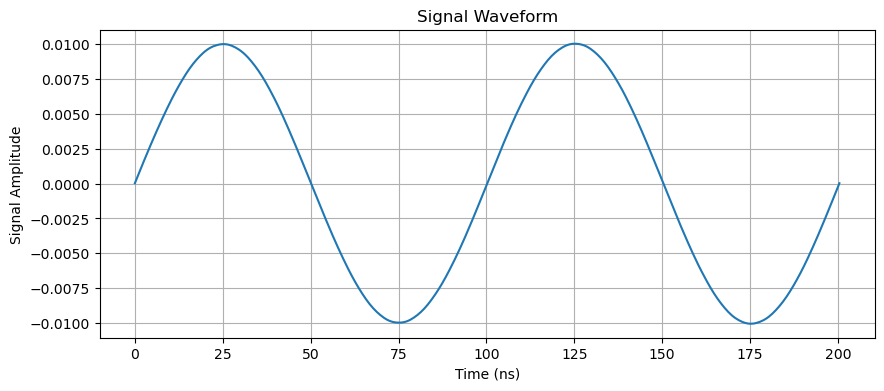

Forward simulation time: 5.72 s
Jacobian computation time: 10.19 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391892, adj=0.391895, ratio=1.0000
  t=50.23: fd=0.392665, adj=0.392669, ratio=1.0000
  t=100.46: fd=0.390736, adj=0.390739, ratio=1.0000
  t=150.68: fd=0.394019, adj=0.394022, ratio=1.0000
  t=200.41: fd=0.391892, adj=0.391895, ratio=1.0000
Forward simulation time: 5.81 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51138331e-08 -3.83080429e-03 -1.52269792e-02
 -3.38836223e-02]
FinDiff J[:,0] = [-0.00291714  0.00106251  0.00046486 -0.01970953 -0.03745882]
Ratio: [-0.00000000e+00 -1.42246849e-05 -8.24069441e+00  7.72569442e-01
  9.04556574e-01]
Forward simulation time: 5.29 s
Iter 19: res=0.060192, res_trial=0.060190, mu=1.000000e-08


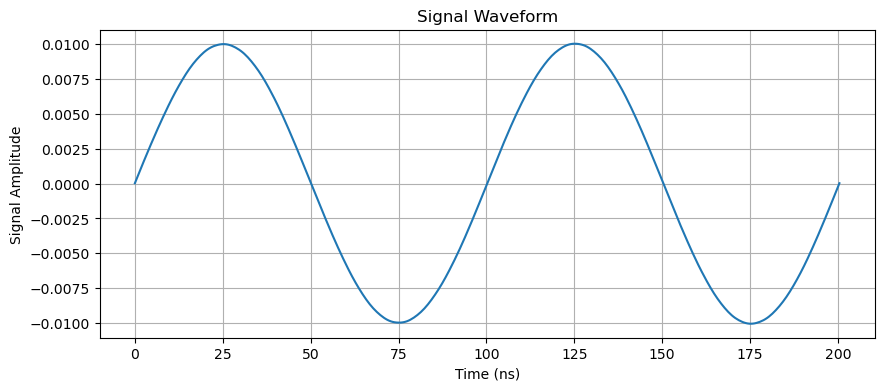

Forward simulation time: 5.89 s
Jacobian computation time: 10.56 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391891, adj=0.391894, ratio=1.0000
  t=50.23: fd=0.392667, adj=0.392670, ratio=1.0000
  t=100.46: fd=0.390734, adj=0.390737, ratio=1.0000
  t=150.68: fd=0.394020, adj=0.394023, ratio=1.0000
  t=200.41: fd=0.391891, adj=0.391894, ratio=1.0000
Forward simulation time: 5.86 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51138046e-08 -3.83079710e-03 -1.52269502e-02
 -3.38836028e-02]
FinDiff J[:,0] = [-0.00181237  0.00324699 -0.00465664 -0.01693251 -0.03269436]
Ratio: [-0.00000000e+00 -4.65471522e-06  8.22652678e-01  8.99272872e-01
  1.03637448e+00]
Forward simulation time: 5.43 s
Iter 20: res=0.060190, res_trial=0.060188, mu=1.000000e-08


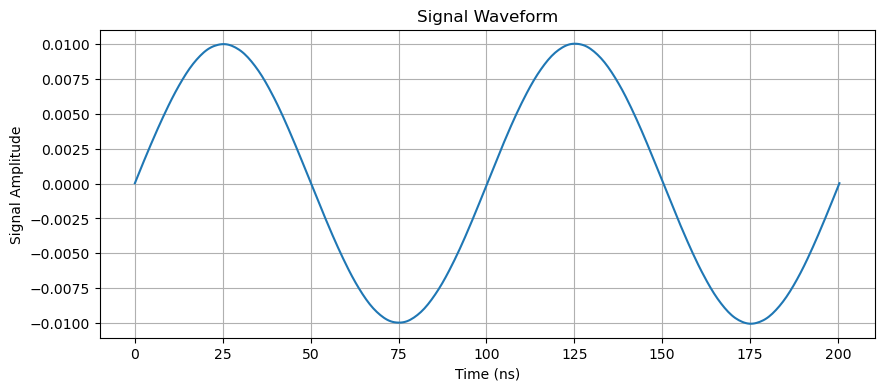

Forward simulation time: 5.71 s
Jacobian computation time: 10.40 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391889, adj=0.391892, ratio=1.0000
  t=50.23: fd=0.392669, adj=0.392672, ratio=1.0000
  t=100.46: fd=0.390732, adj=0.390736, ratio=1.0000
  t=150.68: fd=0.394020, adj=0.394023, ratio=1.0000
  t=200.41: fd=0.391889, adj=0.391892, ratio=1.0000
Forward simulation time: 5.73 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51137602e-08 -3.83078585e-03 -1.52269050e-02
 -3.38835422e-02]
FinDiff J[:,0] = [-0.00225792 -0.00247031 -0.00081379 -0.01716586 -0.03304515]
Ratio: [-0.00000000e+00  6.11816533e-06  4.70731982e+00  8.87046078e-01
  1.02537125e+00]
Forward simulation time: 5.17 s
Iter 21: res=0.060188, res_trial=0.060186, mu=1.000000e-08


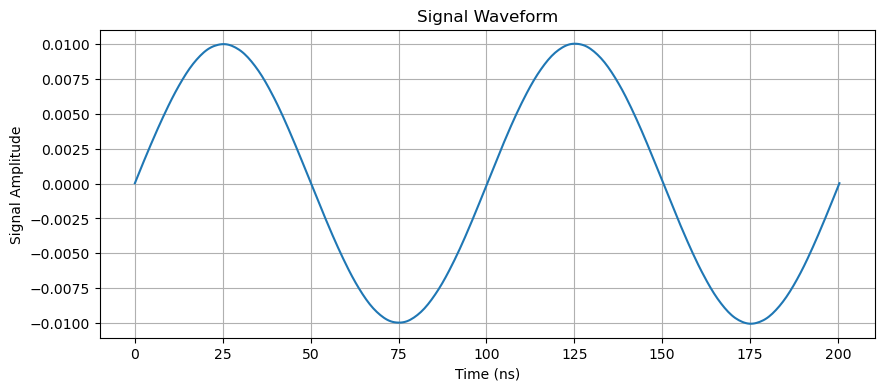

Forward simulation time: 5.83 s
Jacobian computation time: 10.16 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391887, adj=0.391890, ratio=1.0000
  t=50.23: fd=0.392670, adj=0.392673, ratio=1.0000
  t=100.46: fd=0.390731, adj=0.390734, ratio=1.0000
  t=150.68: fd=0.394021, adj=0.394024, ratio=1.0000
  t=200.41: fd=0.391887, adj=0.391890, ratio=1.0000
Forward simulation time: 5.50 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51137033e-08 -3.83077145e-03 -1.52268472e-02
 -3.38834491e-02]
FinDiff J[:,0] = [-0.00350736 -0.00019587 -0.00676022 -0.01603173 -0.03590339]
Ratio: [-0.00000000e+00  7.71636036e-05  5.66663559e-01  9.49794653e-01
  9.43739646e-01]
Forward simulation time: 5.15 s
Iter 22: res=0.060186, res_trial=0.060184, mu=1.000000e-08


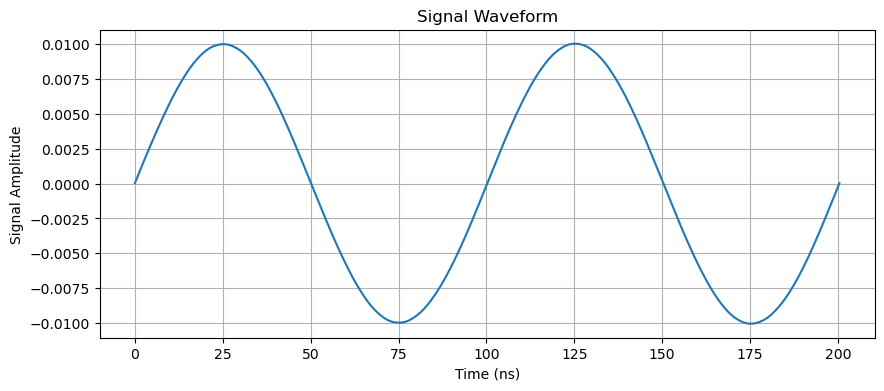

Forward simulation time: 5.51 s
Jacobian computation time: 10.27 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391885, adj=0.391888, ratio=1.0000
  t=50.23: fd=0.392672, adj=0.392675, ratio=1.0000
  t=100.46: fd=0.390729, adj=0.390732, ratio=1.0000
  t=150.68: fd=0.394021, adj=0.394025, ratio=1.0000
  t=200.41: fd=0.391885, adj=0.391888, ratio=1.0000
Forward simulation time: 5.56 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51136369e-08 -3.83075463e-03 -1.52267796e-02
 -3.38833310e-02]
FinDiff J[:,0] = [ 0.00282064 -0.00801851 -0.00197442 -0.01456661 -0.03464013]
Ratio: [0.00000000e+00 1.88484385e-06 1.94019351e+00 1.04532070e+00
 9.78152656e-01]
Forward simulation time: 5.72 s
Iter 23: res=0.060184, res_trial=0.060183, mu=1.000000e-08


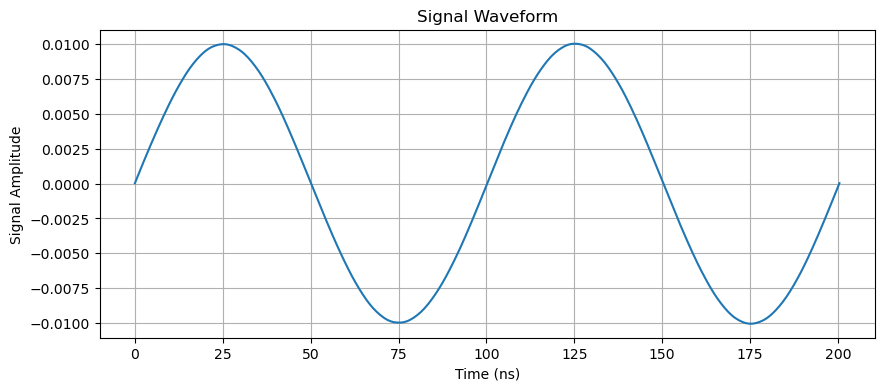

Forward simulation time: 5.10 s
Jacobian computation time: 10.53 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391882, adj=0.391885, ratio=1.0000
  t=50.23: fd=0.392673, adj=0.392676, ratio=1.0000
  t=100.46: fd=0.390727, adj=0.390730, ratio=1.0000
  t=150.68: fd=0.394022, adj=0.394025, ratio=1.0000
  t=200.41: fd=0.391882, adj=0.391885, ratio=1.0000
Forward simulation time: 5.49 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51135627e-08 -3.83073585e-03 -1.52267042e-02
 -3.38831929e-02]
FinDiff J[:,0] = [-0.00274486  0.00340378 -0.00521988 -0.01092467 -0.03994193]
Ratio: [-0.00000000e+00 -4.44022596e-06  7.33874345e-01  1.39379034e+00
  8.48311369e-01]
Forward simulation time: 5.60 s
Iter 24: res=0.060183, res_trial=0.060182, mu=1.000000e-08


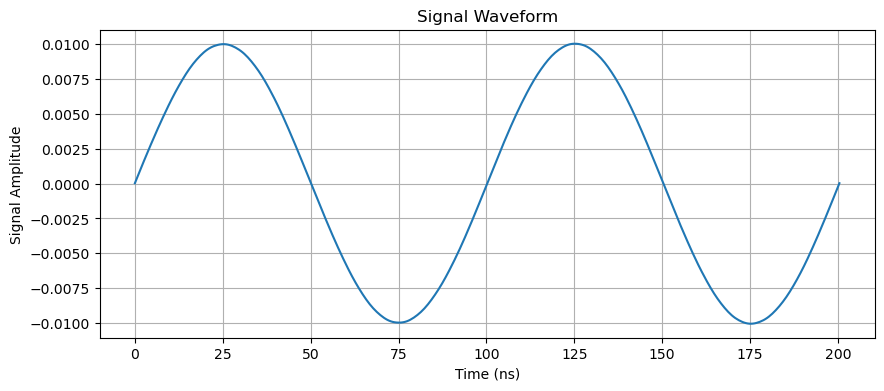

Forward simulation time: 5.29 s
Jacobian computation time: 10.29 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391880, adj=0.391883, ratio=1.0000
  t=50.23: fd=0.392675, adj=0.392678, ratio=1.0000
  t=100.46: fd=0.390726, adj=0.390729, ratio=1.0000
  t=150.68: fd=0.394022, adj=0.394026, ratio=1.0000
  t=200.41: fd=0.391880, adj=0.391883, ratio=1.0000
Forward simulation time: 5.68 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51134828e-08 -3.83071562e-03 -1.52266230e-02
 -3.38830391e-02]
FinDiff J[:,0] = [ 0.00109436  0.00120428 -0.00603801 -0.01891683 -0.03002217]
Ratio: [ 0.00000000e+00 -1.25497596e-05  6.34433450e-01  8.04924612e-01
  1.12860071e+00]
Forward simulation time: 5.59 s
Iter 25: res=0.060182, res_trial=0.060180, mu=1.000000e-08


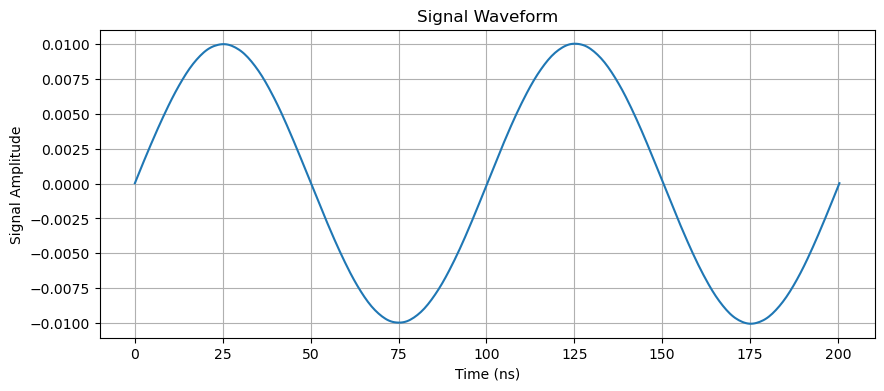

Forward simulation time: 5.72 s
Jacobian computation time: 10.73 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391877, adj=0.391880, ratio=1.0000
  t=50.23: fd=0.392676, adj=0.392679, ratio=1.0000
  t=100.46: fd=0.390724, adj=0.390727, ratio=1.0000
  t=150.68: fd=0.394023, adj=0.394026, ratio=1.0000
  t=200.41: fd=0.391877, adj=0.391880, ratio=1.0000
Forward simulation time: 7.09 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51133985e-08 -3.83069425e-03 -1.52265372e-02
 -3.38828735e-02]
FinDiff J[:,0] = [-7.39605488e-05 -2.13218402e-03 -3.40294903e-03 -1.43012934e-02
 -3.62405295e-02]
Ratio: [-0.00000000e+00  7.08822425e-06  1.12569839e+00  1.06469651e+00
  9.34944216e-01]
Forward simulation time: 6.95 s
Iter 26: res=0.060180, res_trial=0.060179, mu=1.000000e-08


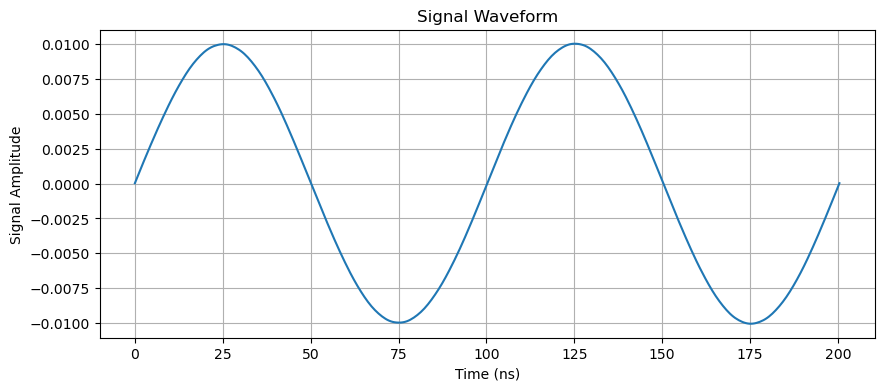

Forward simulation time: 7.21 s
Jacobian computation time: 12.17 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391875, adj=0.391878, ratio=1.0000
  t=50.23: fd=0.392678, adj=0.392681, ratio=1.0000
  t=100.46: fd=0.390722, adj=0.390725, ratio=1.0000
  t=150.68: fd=0.394023, adj=0.394026, ratio=1.0000
  t=200.41: fd=0.391875, adj=0.391878, ratio=1.0000
Forward simulation time: 6.48 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51133108e-08 -3.83067205e-03 -1.52264481e-02
 -3.38826988e-02]
FinDiff J[:,0] = [-0.00397992  0.00484171 -0.00381676 -0.01152321 -0.03519554]
Ratio: [-0.00000000e+00 -3.12147919e-06  1.00364469e+00  1.32137243e+00
  9.62698674e-01]
Forward simulation time: 7.12 s
Iter 27: res=0.060179, res_trial=0.060178, mu=1.000000e-08


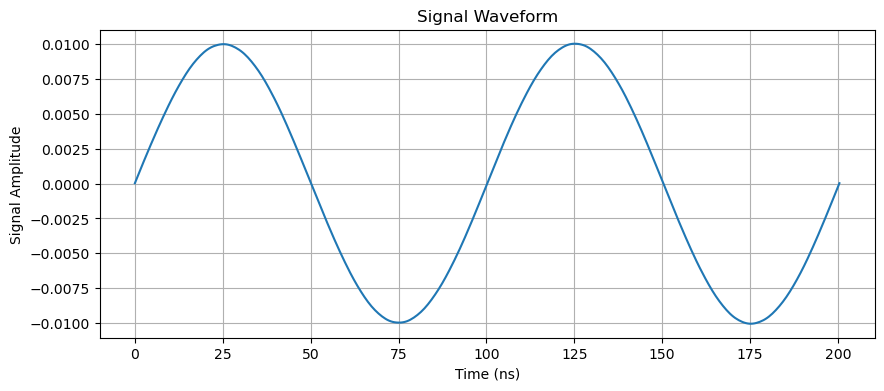

Forward simulation time: 6.81 s
Jacobian computation time: 13.14 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391872, adj=0.391875, ratio=1.0000
  t=50.23: fd=0.392679, adj=0.392682, ratio=1.0000
  t=100.46: fd=0.390721, adj=0.390724, ratio=1.0000
  t=150.68: fd=0.394024, adj=0.394027, ratio=1.0000
  t=200.41: fd=0.391872, adj=0.391875, ratio=1.0000
Forward simulation time: 7.28 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51132207e-08 -3.83064922e-03 -1.52263564e-02
 -3.38825168e-02]
FinDiff J[:,0] = [ 0.00020728 -0.00400399  0.00010352 -0.01659686 -0.03493876]
Ratio: [ 0.00000000e+00  3.77454141e-06 -3.70039280e+01  9.17424091e-01
  9.69768696e-01]
Forward simulation time: 7.14 s
Iter 28: res=0.060178, res_trial=0.060177, mu=1.000000e-08


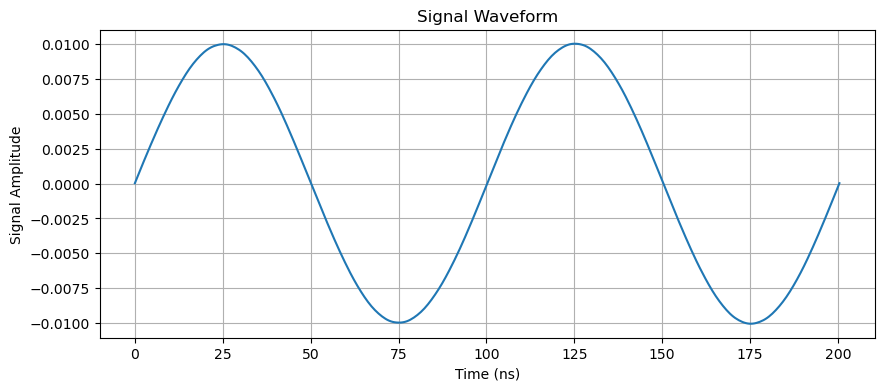

Forward simulation time: 7.52 s
Jacobian computation time: 12.84 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391869, adj=0.391872, ratio=1.0000
  t=50.23: fd=0.392681, adj=0.392684, ratio=1.0000
  t=100.46: fd=0.390719, adj=0.390722, ratio=1.0000
  t=150.68: fd=0.394024, adj=0.394027, ratio=1.0000
  t=200.41: fd=0.391869, adj=0.391872, ratio=1.0000
Forward simulation time: 5.43 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51131291e-08 -3.83062603e-03 -1.52262633e-02
 -3.38823302e-02]
FinDiff J[:,0] = [ 0.00743451  0.00299729 -0.00141738 -0.01529653 -0.039408  ]
Ratio: [ 0.00000000e+00 -5.04226338e-06  2.70261055e+00  9.95406512e-01
  8.59782957e-01]
Forward simulation time: 5.73 s
Iter 29: res=0.060177, res_trial=0.060176, mu=1.000000e-08


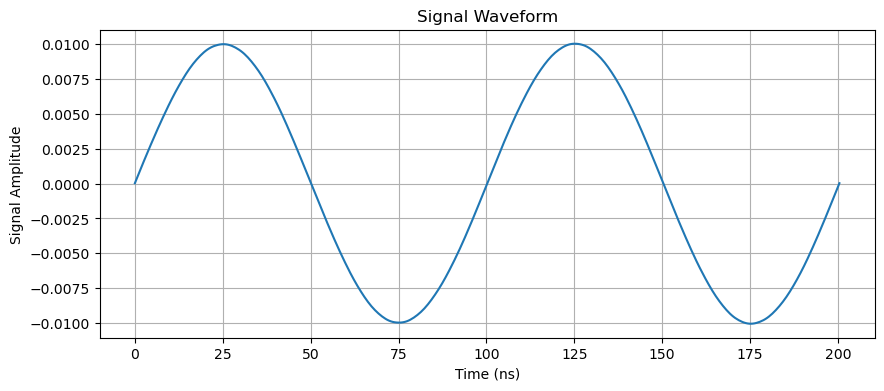

Forward simulation time: 5.29 s
Jacobian computation time: 10.08 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391866, adj=0.391870, ratio=1.0000
  t=50.23: fd=0.392682, adj=0.392685, ratio=1.0000
  t=100.46: fd=0.390718, adj=0.390721, ratio=1.0000
  t=150.68: fd=0.394025, adj=0.394028, ratio=1.0000
  t=200.41: fd=0.391866, adj=0.391870, ratio=1.0000
Forward simulation time: 5.66 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51130364e-08 -3.83060257e-03 -1.52261692e-02
 -3.38821400e-02]
FinDiff J[:,0] = [ 0.0067976  -0.00107583 -0.00719074 -0.01468333 -0.03472272]
Ratio: [0.00000000e+00 1.40478186e-05 5.32713279e-01 1.03696965e+00
 9.75791690e-01]
Forward simulation time: 5.19 s
Iter 30: res=0.060176, res_trial=0.060175, mu=1.000000e-08


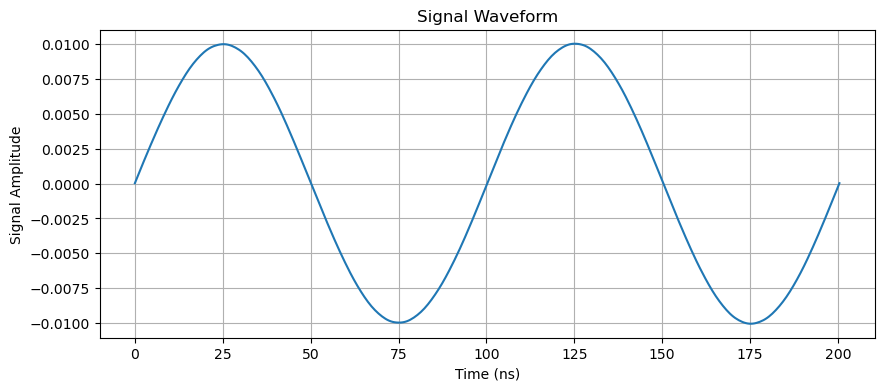

Forward simulation time: 5.35 s
Jacobian computation time: 10.34 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391864, adj=0.391867, ratio=1.0000
  t=50.23: fd=0.392683, adj=0.392687, ratio=1.0000
  t=100.46: fd=0.390716, adj=0.390720, ratio=1.0000
  t=150.68: fd=0.394025, adj=0.394028, ratio=1.0000
  t=200.41: fd=0.391864, adj=0.391867, ratio=1.0000
Forward simulation time: 5.60 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51129432e-08 -3.83057893e-03 -1.52260743e-02
 -3.38819477e-02]
FinDiff J[:,0] = [ 0.00314147 -0.00076239 -0.00095329 -0.01907278 -0.03322298]
Ratio: [0.00000000e+00 1.98230496e-05 4.01825689e+00 7.98314526e-01
 1.01983462e+00]
Forward simulation time: 5.08 s
Iter 31: res=0.060175, res_trial=0.060174, mu=1.000000e-08


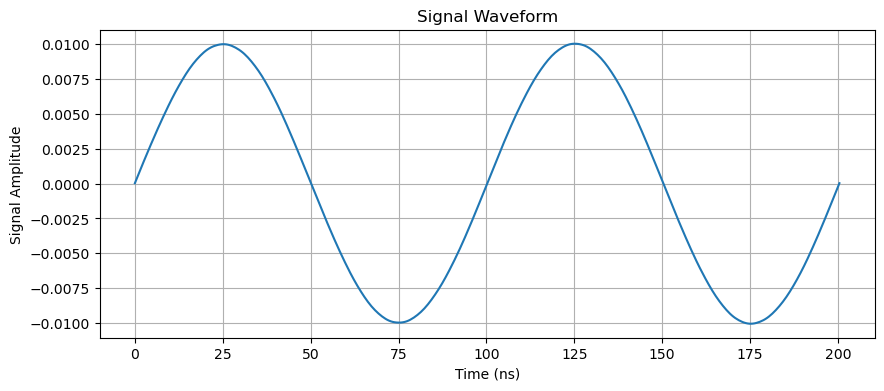

Forward simulation time: 5.45 s
Jacobian computation time: 10.25 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391861, adj=0.391864, ratio=1.0000
  t=50.23: fd=0.392685, adj=0.392688, ratio=1.0000
  t=100.46: fd=0.390715, adj=0.390718, ratio=1.0000
  t=150.68: fd=0.394025, adj=0.394029, ratio=1.0000
  t=200.41: fd=0.391861, adj=0.391864, ratio=1.0000
Forward simulation time: 5.83 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51128497e-08 -3.83055527e-03 -1.52259793e-02
 -3.38817540e-02]
FinDiff J[:,0] = [-0.00126705  0.00264454 -0.00286764 -0.01316827 -0.03686141]
Ratio: [-0.00000000e+00 -5.71474042e-06  1.33578467e+00  1.15626253e+00
  9.19166103e-01]
Forward simulation time: 5.35 s
Iter 32: res=0.060174, res_trial=0.060174, mu=1.000000e-08


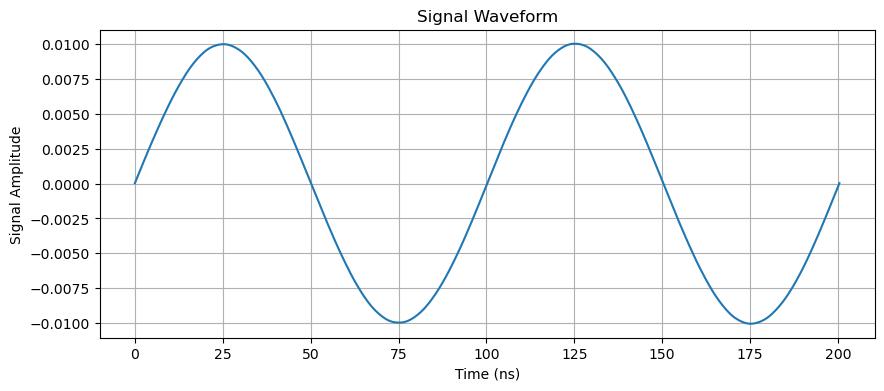

Forward simulation time: 6.22 s
Jacobian computation time: 11.14 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391858, adj=0.391862, ratio=1.0000
  t=50.23: fd=0.392686, adj=0.392689, ratio=1.0000
  t=100.46: fd=0.390714, adj=0.390717, ratio=1.0000
  t=150.68: fd=0.394026, adj=0.394029, ratio=1.0000
  t=200.41: fd=0.391858, adj=0.391862, ratio=1.0000
Forward simulation time: 6.85 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51127563e-08 -3.83053160e-03 -1.52258843e-02
 -3.38815592e-02]
FinDiff J[:,0] = [-0.00346065  0.00239834 -0.00820227 -0.0216675  -0.03024612]
Ratio: [-0.00000000e+00 -6.30132774e-06  4.67008809e-01  7.02706039e-01
  1.12019535e+00]
Forward simulation time: 5.37 s
Iter 33: res=0.060174, res_trial=0.060173, mu=1.000000e-08


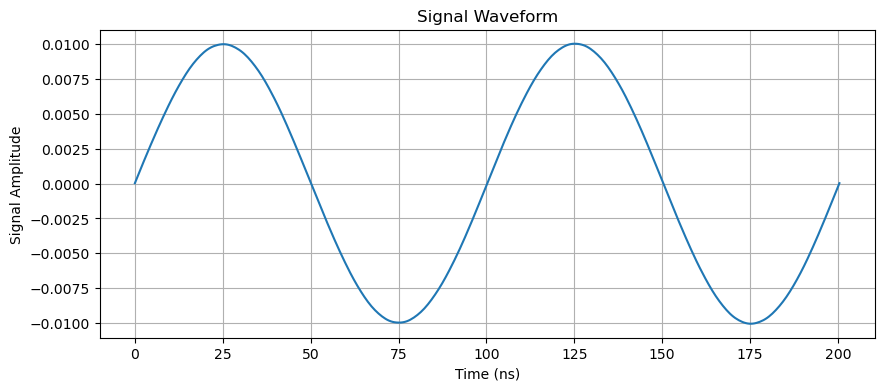

Forward simulation time: 5.89 s
Jacobian computation time: 10.31 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391856, adj=0.391859, ratio=1.0000
  t=50.23: fd=0.392687, adj=0.392691, ratio=1.0000
  t=100.46: fd=0.390713, adj=0.390716, ratio=1.0000
  t=150.68: fd=0.394026, adj=0.394029, ratio=1.0000
  t=200.41: fd=0.391856, adj=0.391859, ratio=1.0000
Forward simulation time: 5.66 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51126632e-08 -3.83050804e-03 -1.52257897e-02
 -3.38813646e-02]
FinDiff J[:,0] = [ 3.33348409e-03 -4.66241823e-05 -5.26632307e-03 -1.30846152e-02
 -3.40665142e-02]
Ratio: [0.00000000e+00 3.24137872e-04 7.27359106e-01 1.16364062e+00
 9.94565054e-01]
Forward simulation time: 5.90 s
Iter 34: res=0.060173, res_trial=0.060172, mu=1.000000e-08


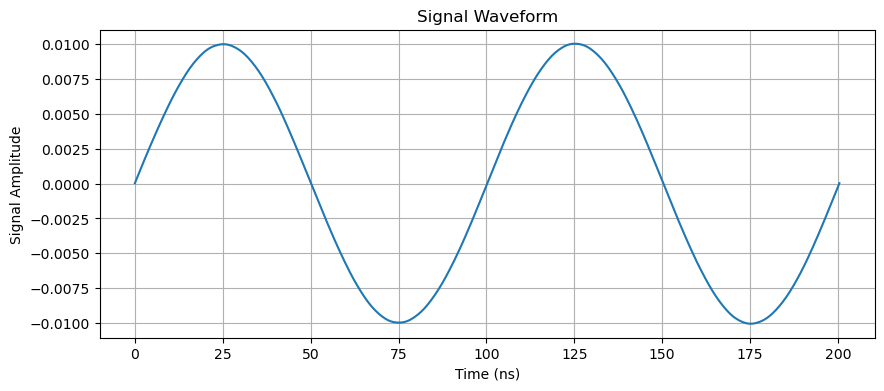

Forward simulation time: 5.28 s
Jacobian computation time: 10.65 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391853, adj=0.391856, ratio=1.0000
  t=50.23: fd=0.392689, adj=0.392692, ratio=1.0000
  t=100.46: fd=0.390712, adj=0.390715, ratio=1.0000
  t=150.68: fd=0.394027, adj=0.394030, ratio=1.0000
  t=200.41: fd=0.391853, adj=0.391856, ratio=1.0000
Forward simulation time: 5.65 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51125706e-08 -3.83048457e-03 -1.52256955e-02
 -3.38811702e-02]
FinDiff J[:,0] = [-0.00647037 -0.00190429 -0.00250587 -0.01624448 -0.03239529]
Ratio: [-0.00000000e+00  7.93606943e-06  1.52860226e+00  9.37284184e-01
  1.04586729e+00]
Forward simulation time: 5.98 s
Iter 35: res=0.060172, res_trial=0.060171, mu=1.000000e-08


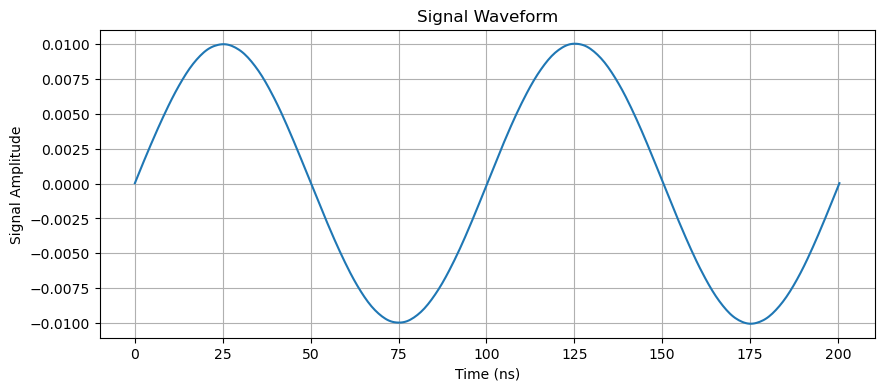

Forward simulation time: 5.66 s
Jacobian computation time: 10.57 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391851, adj=0.391854, ratio=1.0000
  t=50.23: fd=0.392690, adj=0.392693, ratio=1.0000
  t=100.46: fd=0.390710, adj=0.390714, ratio=1.0000
  t=150.68: fd=0.394027, adj=0.394030, ratio=1.0000
  t=200.41: fd=0.391851, adj=0.391854, ratio=1.0000
Forward simulation time: 5.85 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51124788e-08 -3.83046131e-03 -1.52256022e-02
 -3.38809776e-02]
FinDiff J[:,0] = [ 0.00257721  0.00290301 -0.00780158 -0.01805402 -0.03387162]
Ratio: [ 0.00000000e+00 -5.20579182e-06  4.90985075e-01  8.43335782e-01
  1.00027622e+00]
Forward simulation time: 5.66 s
Iter 36: res=0.060171, res_trial=0.060170, mu=1.000000e-08


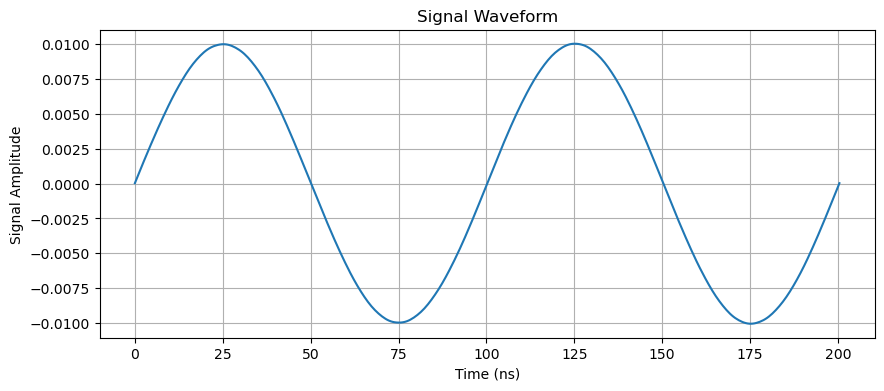

Forward simulation time: 5.88 s
Jacobian computation time: 10.33 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391848, adj=0.391851, ratio=1.0000
  t=50.23: fd=0.392691, adj=0.392694, ratio=1.0000
  t=100.46: fd=0.390709, adj=0.390712, ratio=1.0000
  t=150.68: fd=0.394028, adj=0.394031, ratio=1.0000
  t=200.41: fd=0.391848, adj=0.391851, ratio=1.0000
Forward simulation time: 5.85 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51123880e-08 -3.83043832e-03 -1.52255099e-02
 -3.38807862e-02]
FinDiff J[:,0] = [-0.00224592 -0.00572522 -0.01157793 -0.01483127 -0.03433938]
Ratio: [-0.00000000e+00  2.63961912e-06  3.30839755e-01  1.02658171e+00
  9.86645165e-01]
Forward simulation time: 5.34 s
Iter 37: res=0.060170, res_trial=0.060170, mu=1.000000e-08


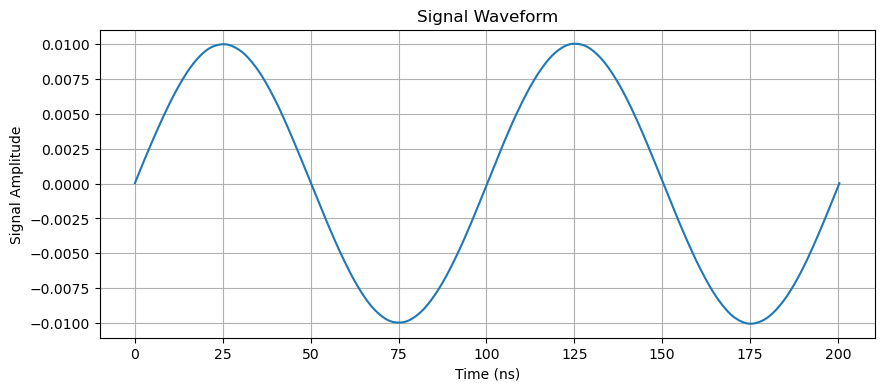

Forward simulation time: 5.72 s
Jacobian computation time: 10.22 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391846, adj=0.391849, ratio=1.0000
  t=50.23: fd=0.392692, adj=0.392696, ratio=1.0000
  t=100.46: fd=0.390708, adj=0.390711, ratio=1.0000
  t=150.68: fd=0.394028, adj=0.394031, ratio=1.0000
  t=200.41: fd=0.391846, adj=0.391849, ratio=1.0000
Forward simulation time: 5.38 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51122977e-08 -3.83041546e-03 -1.52254181e-02
 -3.38805954e-02]
FinDiff J[:,0] = [-0.0034012  -0.00472281 -0.00177059 -0.01912785 -0.0285306 ]
Ratio: [-0.00000000e+00  3.19985227e-06  2.16335774e+00  7.95981846e-01
  1.18751766e+00]
Forward simulation time: 5.99 s
Iter 38: res=0.060170, res_trial=0.060169, mu=1.000000e-08


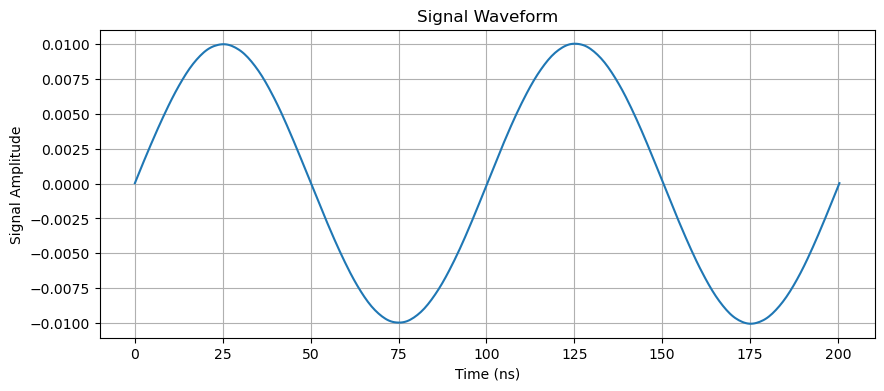

Forward simulation time: 6.17 s
Jacobian computation time: 10.79 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391843, adj=0.391846, ratio=1.0000
  t=50.23: fd=0.392694, adj=0.392697, ratio=1.0000
  t=100.46: fd=0.390707, adj=0.390710, ratio=1.0000
  t=150.68: fd=0.394028, adj=0.394031, ratio=1.0000
  t=200.41: fd=0.391843, adj=0.391846, ratio=1.0000
Forward simulation time: 6.03 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51122085e-08 -3.83039286e-03 -1.52253274e-02
 -3.38804069e-02]
FinDiff J[:,0] = [ 4.20922741e-05 -2.10527585e-03 -6.56222610e-03 -1.74846340e-02
 -3.63887734e-02]
Ratio: [0.00000000e+00 7.17825576e-06 5.83703275e-01 8.70783306e-01
 9.31067572e-01]
Forward simulation time: 5.34 s
Iter 39: res=0.060169, res_trial=0.060168, mu=1.000000e-08


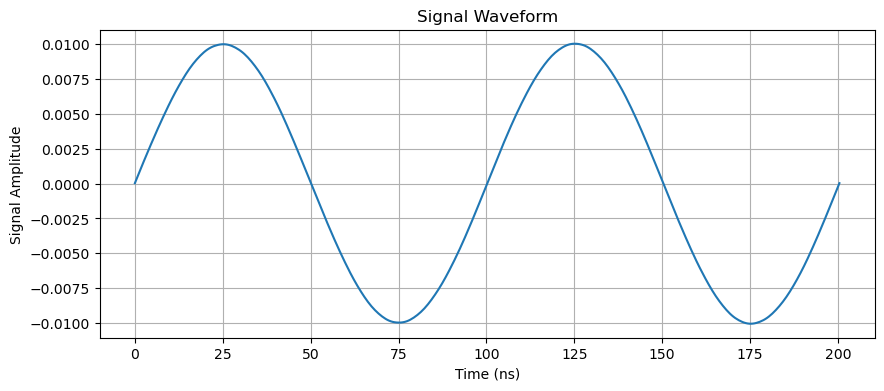

Forward simulation time: 5.96 s
Jacobian computation time: 10.38 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391841, adj=0.391844, ratio=1.0000
  t=50.23: fd=0.392695, adj=0.392698, ratio=1.0000
  t=100.46: fd=0.390706, adj=0.390710, ratio=1.0000
  t=150.68: fd=0.394029, adj=0.394032, ratio=1.0000
  t=200.41: fd=0.391841, adj=0.391844, ratio=1.0000
Forward simulation time: 5.13 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51121205e-08 -3.83037056e-03 -1.52252379e-02
 -3.38802201e-02]
FinDiff J[:,0] = [ 0.00276951 -0.00026387 -0.00466347 -0.01695653 -0.03797322]
Ratio: [0.00000000e+00 5.72710091e-05 8.21356215e-01 8.97898397e-01
 8.92213449e-01]
Forward simulation time: 5.69 s
Iter 40: res=0.060168, res_trial=0.060168, mu=1.000000e-08


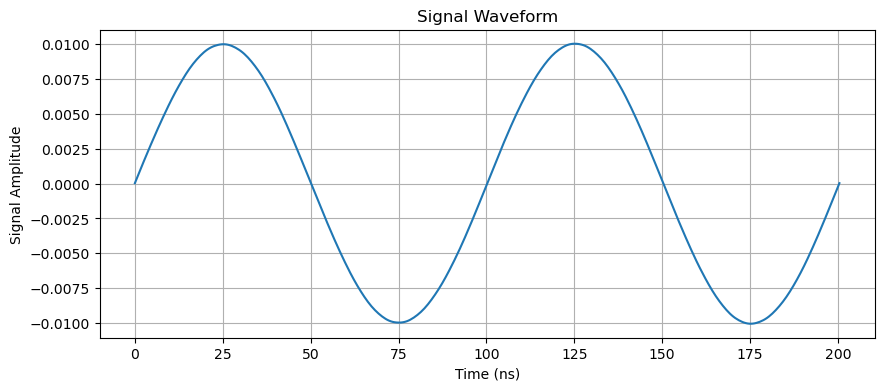

Forward simulation time: 5.23 s
Jacobian computation time: 10.30 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391838, adj=0.391841, ratio=1.0000
  t=50.23: fd=0.392696, adj=0.392699, ratio=1.0000
  t=100.46: fd=0.390706, adj=0.390709, ratio=1.0000
  t=150.68: fd=0.394029, adj=0.394032, ratio=1.0000
  t=200.41: fd=0.391838, adj=0.391841, ratio=1.0000
Forward simulation time: 5.60 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51120333e-08 -3.83034848e-03 -1.52251493e-02
 -3.38800352e-02]
FinDiff J[:,0] = [ 0.00146519  0.00383473 -0.00772486 -0.01311121 -0.03520708]
Ratio: [ 0.00000000e+00 -3.94082948e-06  4.95847139e-01  1.16123141e+00
  9.62307500e-01]
Forward simulation time: 5.63 s
Iter 41: res=0.060168, res_trial=0.060167, mu=1.000000e-08


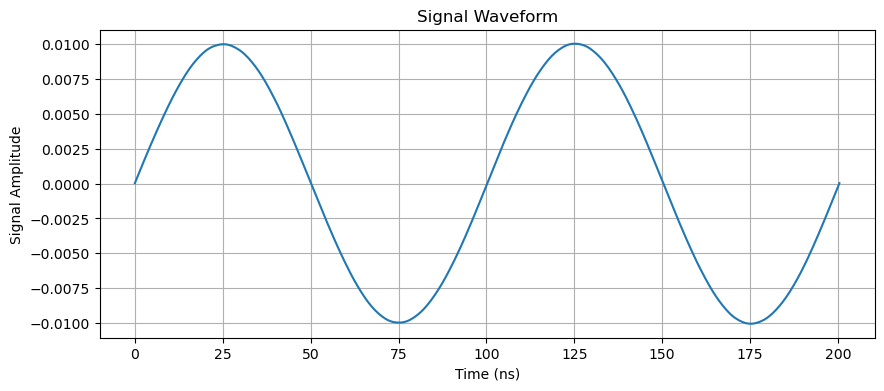

Forward simulation time: 5.54 s
Jacobian computation time: 10.31 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391836, adj=0.391839, ratio=1.0000
  t=50.23: fd=0.392697, adj=0.392700, ratio=1.0000
  t=100.46: fd=0.390705, adj=0.390708, ratio=1.0000
  t=150.68: fd=0.394029, adj=0.394033, ratio=1.0000
  t=200.41: fd=0.391836, adj=0.391839, ratio=1.0000
Forward simulation time: 5.30 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51119473e-08 -3.83032670e-03 -1.52250619e-02
 -3.38798520e-02]
FinDiff J[:,0] = [-0.00196625 -0.00253453 -0.00362294 -0.01606893 -0.02531747]
Ratio: [-0.00000000e+00  5.96243144e-06  1.05724181e+00  9.47484599e-01
  1.33820075e+00]
Forward simulation time: 5.64 s
Iter 42: res=0.060167, res_trial=0.060167, mu=1.000000e-08


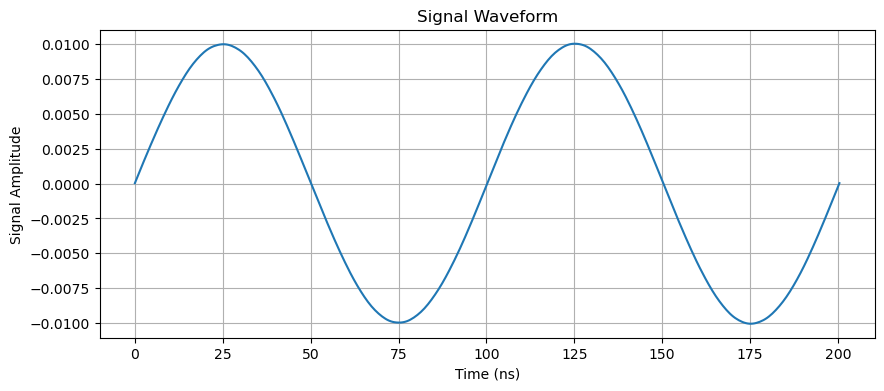

Forward simulation time: 5.50 s
Jacobian computation time: 12.38 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391833, adj=0.391837, ratio=1.0000
  t=50.23: fd=0.392698, adj=0.392701, ratio=1.0000
  t=100.46: fd=0.390704, adj=0.390707, ratio=1.0000
  t=150.68: fd=0.394030, adj=0.394033, ratio=1.0000
  t=200.41: fd=0.391833, adj=0.391837, ratio=1.0000
Forward simulation time: 7.39 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51118624e-08 -3.83030520e-03 -1.52249756e-02
 -3.38796715e-02]
FinDiff J[:,0] = [-0.00331388 -0.00624425 -0.00279373 -0.01943259 -0.03682356]
Ratio: [-0.00000000e+00  2.42012642e-06  1.37103390e+00  7.83476382e-01
  9.20054129e-01]
Forward simulation time: 6.51 s
Iter 43: res=0.060167, res_trial=0.060166, mu=1.000000e-08


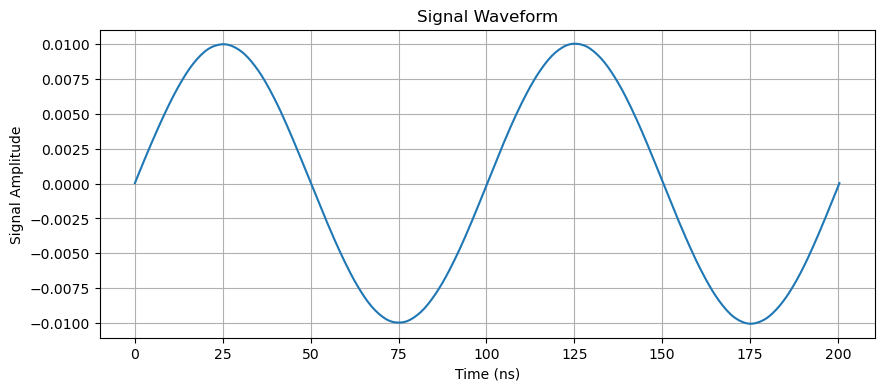

Forward simulation time: 5.59 s
Jacobian computation time: 10.40 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391831, adj=0.391834, ratio=1.0000
  t=50.23: fd=0.392699, adj=0.392702, ratio=1.0000
  t=100.46: fd=0.390703, adj=0.390706, ratio=1.0000
  t=150.68: fd=0.394030, adj=0.394033, ratio=1.0000
  t=200.41: fd=0.391831, adj=0.391834, ratio=1.0000
Forward simulation time: 5.73 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51117788e-08 -3.83028401e-03 -1.52248906e-02
 -3.38794931e-02]
FinDiff J[:,0] = [ 0.00354561  0.00298993 -0.00820534 -0.01423839 -0.03103309]
Ratio: [ 0.00000000e+00 -5.05422782e-06  4.66803787e-01  1.06928438e+00
  1.09172142e+00]
Forward simulation time: 5.35 s
Iter 44: res=0.060166, res_trial=0.060166, mu=1.000000e-08


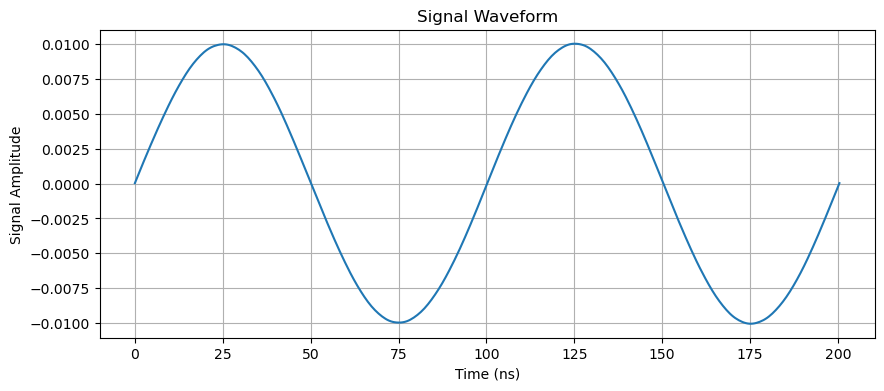

Forward simulation time: 5.64 s
Jacobian computation time: 10.51 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391829, adj=0.391832, ratio=1.0000
  t=50.23: fd=0.392700, adj=0.392703, ratio=1.0000
  t=100.46: fd=0.390702, adj=0.390706, ratio=1.0000
  t=150.68: fd=0.394031, adj=0.394034, ratio=1.0000
  t=200.41: fd=0.391829, adj=0.391832, ratio=1.0000
Forward simulation time: 5.53 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51116961e-08 -3.83026308e-03 -1.52248065e-02
 -3.38793164e-02]
FinDiff J[:,0] = [-0.00250562  0.00272713 -0.00591798 -0.01817581 -0.03164942]
Ratio: [-0.00000000e+00 -5.54123640e-06  6.47224709e-01  8.37641028e-01
  1.07045614e+00]
Forward simulation time: 5.70 s
Iter 45: res=0.060166, res_trial=0.060165, mu=1.000000e-08


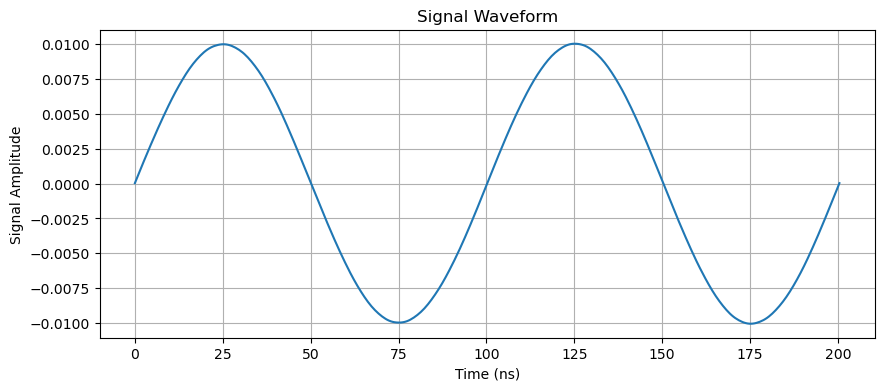

Forward simulation time: 5.31 s
Jacobian computation time: 10.68 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391827, adj=0.391830, ratio=1.0000
  t=50.23: fd=0.392701, adj=0.392704, ratio=1.0000
  t=100.46: fd=0.390702, adj=0.390705, ratio=1.0000
  t=150.68: fd=0.394031, adj=0.394034, ratio=1.0000
  t=200.41: fd=0.391827, adj=0.391830, ratio=1.0000
Forward simulation time: 5.38 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51116147e-08 -3.83024244e-03 -1.52247237e-02
 -3.38791421e-02]
FinDiff J[:,0] = [ 0.00177761 -0.00265785 -0.00554943 -0.0157178  -0.03575824]
Ratio: [0.00000000e+00 5.68565201e-06 6.90204883e-01 9.68629461e-01
 9.47449806e-01]
Forward simulation time: 5.53 s
Iter 46: res=0.060165, res_trial=0.060165, mu=1.000000e-08


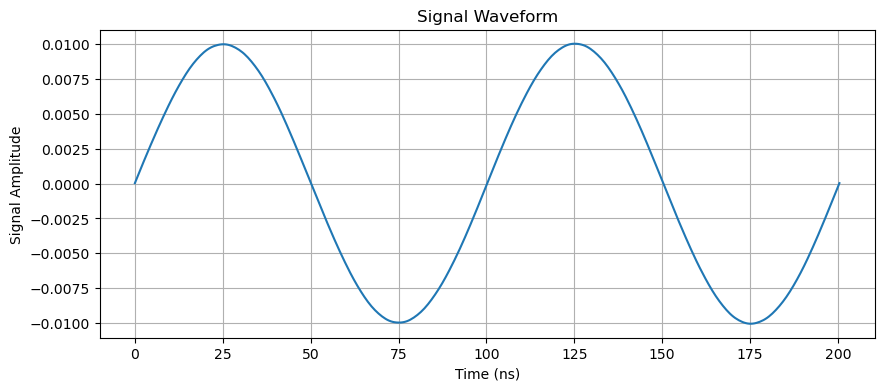

Forward simulation time: 5.29 s
Jacobian computation time: 10.24 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391824, adj=0.391828, ratio=1.0000
  t=50.23: fd=0.392702, adj=0.392705, ratio=1.0000
  t=100.46: fd=0.390701, adj=0.390704, ratio=1.0000
  t=150.68: fd=0.394031, adj=0.394035, ratio=1.0000
  t=200.41: fd=0.391824, adj=0.391828, ratio=1.0000
Forward simulation time: 5.79 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51115339e-08 -3.83022197e-03 -1.52246415e-02
 -3.38789691e-02]
FinDiff J[:,0] = [-0.00138669 -0.00172821 -0.00401919 -0.01960233 -0.03149872]
Ratio: [-0.00000000e+00  8.74405034e-06  9.52983558e-01  7.76675276e-01
  1.07556644e+00]
Forward simulation time: 5.58 s
Iter 47: res=0.060165, res_trial=0.060164, mu=1.000000e-08


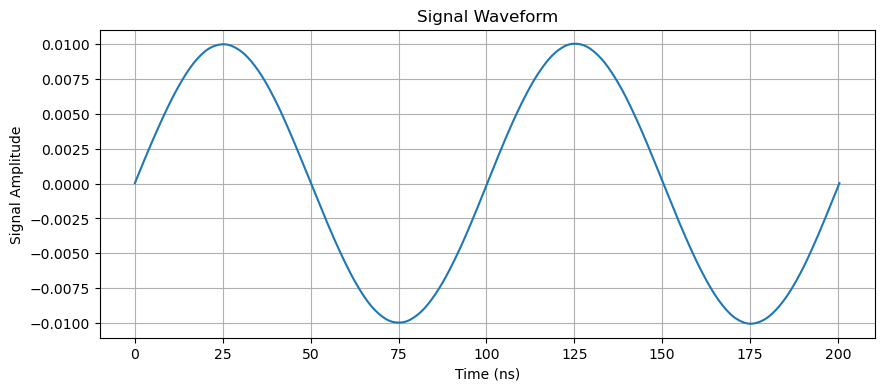

Forward simulation time: 5.83 s
Jacobian computation time: 10.44 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391822, adj=0.391825, ratio=1.0000
  t=50.23: fd=0.392703, adj=0.392706, ratio=1.0000
  t=100.46: fd=0.390700, adj=0.390704, ratio=1.0000
  t=150.68: fd=0.394032, adj=0.394035, ratio=1.0000
  t=200.41: fd=0.391822, adj=0.391825, ratio=1.0000
Forward simulation time: 5.53 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51114547e-08 -3.83020192e-03 -1.52245611e-02
 -3.38787993e-02]
FinDiff J[:,0] = [-0.00149214 -0.00278447 -0.00781724 -0.01517811 -0.03212917]
Ratio: [-0.00000000e+00  5.42705200e-06  4.89968692e-01  1.00306058e+00
  1.05445615e+00]
Forward simulation time: 5.19 s
Iter 48: res=0.060164, res_trial=0.060164, mu=1.000000e-08


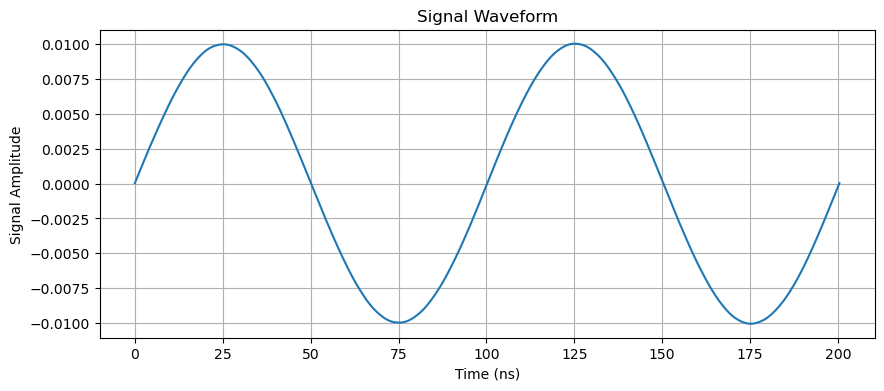

Forward simulation time: 5.59 s
Jacobian computation time: 10.15 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391820, adj=0.391823, ratio=1.0000
  t=50.23: fd=0.392704, adj=0.392707, ratio=1.0000
  t=100.46: fd=0.390700, adj=0.390703, ratio=1.0000
  t=150.68: fd=0.394032, adj=0.394035, ratio=1.0000
  t=200.41: fd=0.391820, adj=0.391823, ratio=1.0000
Forward simulation time: 5.63 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51113764e-08 -3.83018208e-03 -1.52244815e-02
 -3.38786314e-02]
FinDiff J[:,0] = [ 0.00013167 -0.00428223 -0.00706525 -0.01647289 -0.03235057]
Ratio: [0.00000000e+00 3.52885437e-06 5.42115327e-01 9.24214083e-01
 1.04723453e+00]
Forward simulation time: 5.75 s
Iter 49: res=0.060164, res_trial=0.060163, mu=1.000000e-08


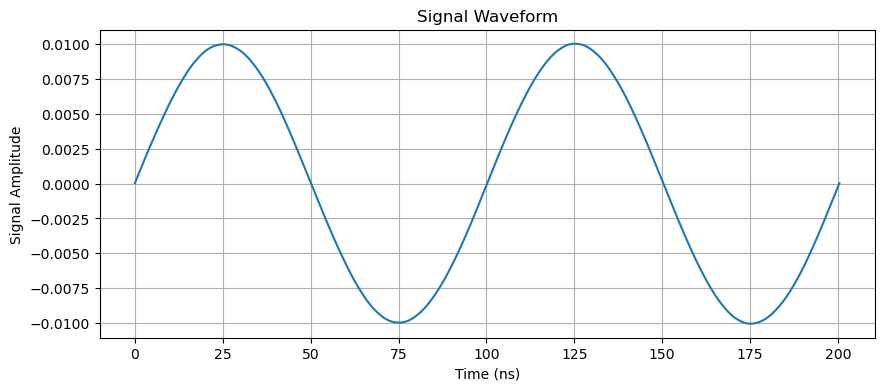

Forward simulation time: 5.32 s
Jacobian computation time: 10.03 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391818, adj=0.391821, ratio=1.0000
  t=50.23: fd=0.392705, adj=0.392708, ratio=1.0000
  t=100.46: fd=0.390699, adj=0.390702, ratio=1.0000
  t=150.68: fd=0.394033, adj=0.394036, ratio=1.0000
  t=200.41: fd=0.391818, adj=0.391821, ratio=1.0000
Forward simulation time: 5.87 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51112993e-08 -3.83016255e-03 -1.52244031e-02
 -3.38784661e-02]
FinDiff J[:,0] = [-4.57135103e-03  4.85327001e-05 -4.04521785e-03 -1.95625136e-02
 -3.39401591e-02]
Ratio: [-0.00000000e+00 -3.11363251e-04  9.46837153e-01  7.78243706e-01
  9.98182301e-01]
Forward simulation time: 5.24 s
Iter 50: res=0.060163, res_trial=0.060163, mu=1.000000e-08


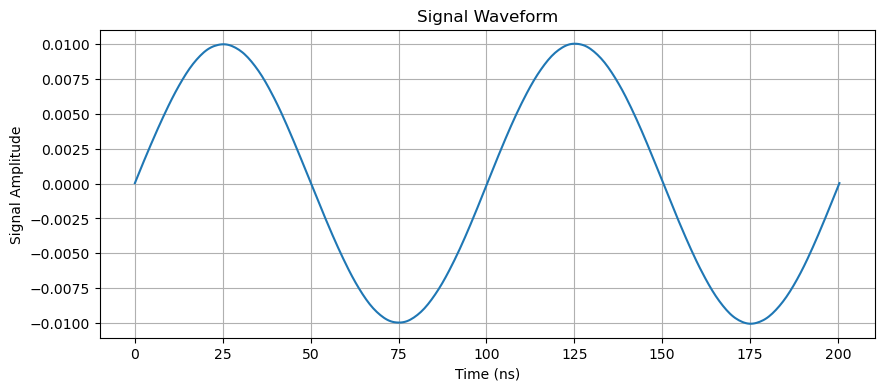

Forward simulation time: 5.83 s
Jacobian computation time: 10.34 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391816, adj=0.391819, ratio=1.0000
  t=50.23: fd=0.392706, adj=0.392709, ratio=1.0000
  t=100.46: fd=0.390699, adj=0.390702, ratio=1.0000
  t=150.68: fd=0.394033, adj=0.394036, ratio=1.0000
  t=200.41: fd=0.391816, adj=0.391819, ratio=1.0000
Forward simulation time: 5.54 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51112232e-08 -3.83014327e-03 -1.52243257e-02
 -3.38783020e-02]
FinDiff J[:,0] = [-0.00319097  0.00157252 -0.00687548 -0.01969112 -0.03318968]
Ratio: [-0.00000000e+00 -9.60957554e-06  5.57072832e-01  7.73156894e-01
  1.02074811e+00]
Forward simulation time: 5.99 s
Iter 51: res=0.060163, res_trial=0.060162, mu=1.000000e-08


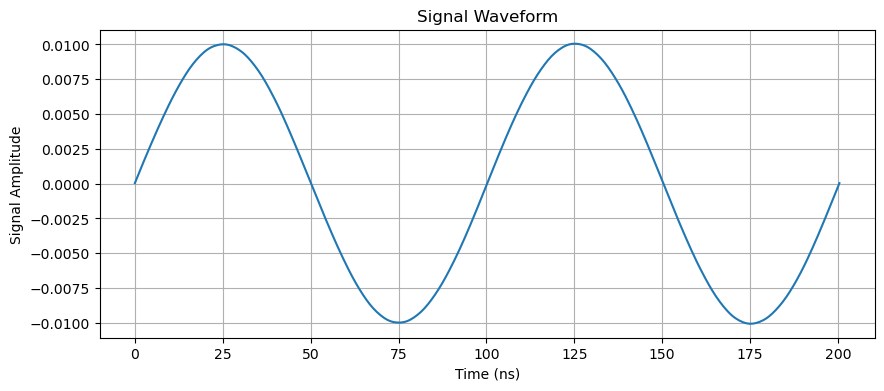

Forward simulation time: 5.38 s
Jacobian computation time: 10.37 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391814, adj=0.391817, ratio=1.0000
  t=50.23: fd=0.392707, adj=0.392710, ratio=1.0000
  t=100.46: fd=0.390698, adj=0.390701, ratio=1.0000
  t=150.68: fd=0.394033, adj=0.394036, ratio=1.0000
  t=200.41: fd=0.391814, adj=0.391817, ratio=1.0000
Forward simulation time: 5.80 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51111481e-08 -3.83012423e-03 -1.52242493e-02
 -3.38781406e-02]
FinDiff J[:,0] = [ 0.00247476  0.00069189 -0.00952521 -0.01551209 -0.03696185]
Ratio: [ 0.00000000e+00 -2.18404837e-05  4.02104091e-01  9.81444083e-01
  9.16570491e-01]
Forward simulation time: 5.86 s
Iter 52: res=0.060162, res_trial=0.060162, mu=1.000000e-08


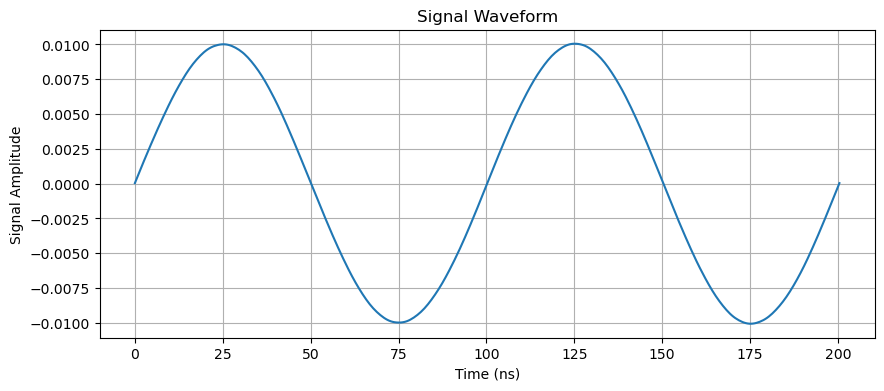

Forward simulation time: 5.83 s
Jacobian computation time: 10.29 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391812, adj=0.391815, ratio=1.0000
  t=50.23: fd=0.392708, adj=0.392711, ratio=1.0000
  t=100.46: fd=0.390698, adj=0.390701, ratio=1.0000
  t=150.68: fd=0.394034, adj=0.394037, ratio=1.0000
  t=200.41: fd=0.391812, adj=0.391815, ratio=1.0000
Forward simulation time: 5.24 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51110739e-08 -3.83010545e-03 -1.52241739e-02
 -3.38779806e-02]
FinDiff J[:,0] = [ 0.00279795 -0.00059288 -0.00415014 -0.01136377 -0.02790371]
Ratio: [0.00000000e+00 2.54877022e-05 9.22886219e-01 1.33971139e+00
 1.21410326e+00]
Forward simulation time: 5.61 s
Iter 53: res=0.060162, res_trial=0.060162, mu=1.000000e-08


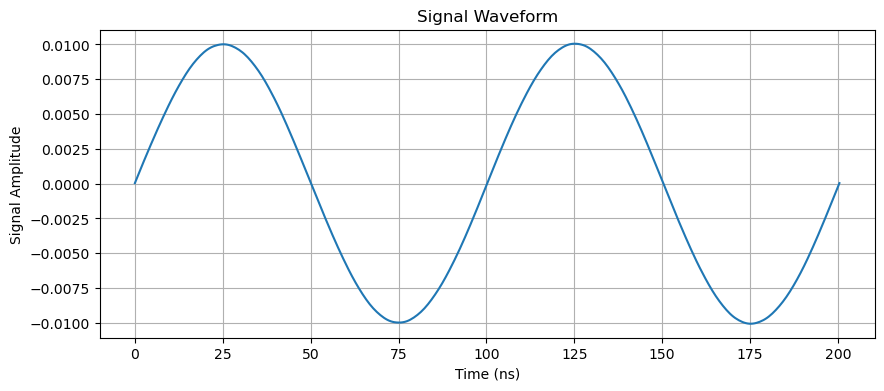

Forward simulation time: 5.60 s
Jacobian computation time: 10.25 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391810, adj=0.391813, ratio=1.0000
  t=50.23: fd=0.392708, adj=0.392712, ratio=1.0000
  t=100.46: fd=0.390697, adj=0.390700, ratio=1.0000
  t=150.68: fd=0.394034, adj=0.394037, ratio=1.0000
  t=200.41: fd=0.391810, adj=0.391813, ratio=1.0000
Forward simulation time: 5.94 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51110010e-08 -3.83008699e-03 -1.52240998e-02
 -3.38778232e-02]
FinDiff J[:,0] = [-0.00537832  0.00030917 -0.00096801 -0.01181331 -0.03465987]
Ratio: [-0.00000000e+00 -4.88762122e-05  3.95665926e+00  1.28872451e+00
  9.77436578e-01]
Forward simulation time: 5.40 s
Iter 54: res=0.060162, res_trial=0.060161, mu=1.000000e-08


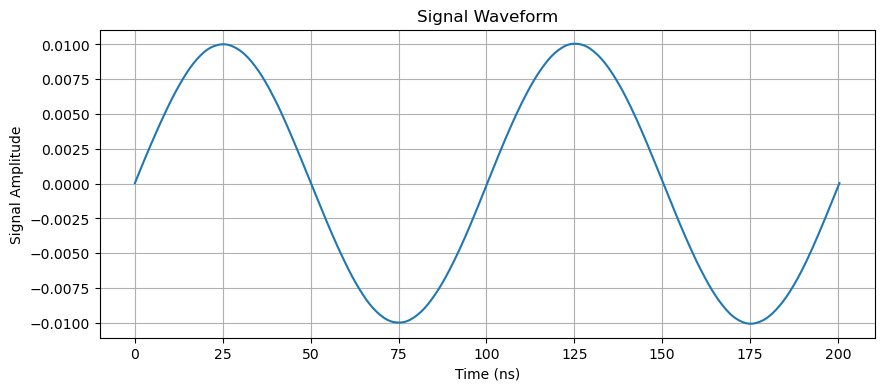

Forward simulation time: 5.80 s
Jacobian computation time: 10.48 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391808, adj=0.391811, ratio=1.0000
  t=50.23: fd=0.392709, adj=0.392712, ratio=1.0000
  t=100.46: fd=0.390697, adj=0.390700, ratio=1.0000
  t=150.68: fd=0.394034, adj=0.394037, ratio=1.0000
  t=200.41: fd=0.391808, adj=0.391811, ratio=1.0000
Forward simulation time: 5.74 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51109290e-08 -3.83006874e-03 -1.52240266e-02
 -3.38776677e-02]
FinDiff J[:,0] = [-0.00239039 -0.00257931 -0.00657612 -0.0159943  -0.03031616]
Ratio: [-0.00000000e+00  5.85852721e-06  5.82420464e-01  9.51840466e-01
  1.11747869e+00]
Forward simulation time: 5.24 s
Iter 55: res=0.060161, res_trial=0.060161, mu=1.000000e-08


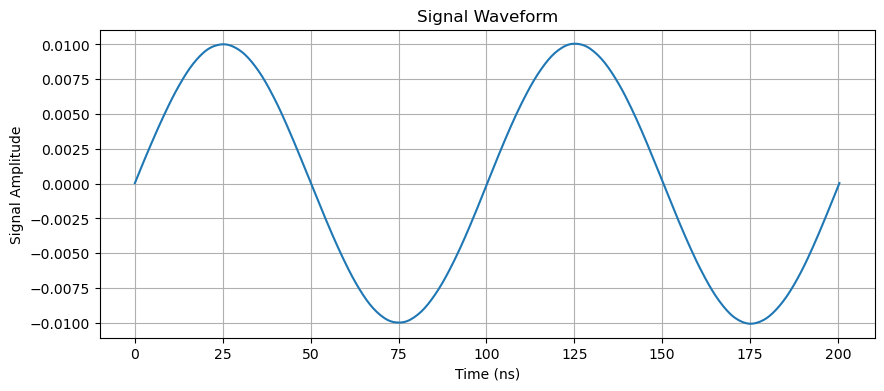

Forward simulation time: 5.73 s
Jacobian computation time: 10.14 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391806, adj=0.391809, ratio=1.0000
  t=50.23: fd=0.392710, adj=0.392713, ratio=1.0000
  t=100.46: fd=0.390696, adj=0.390699, ratio=1.0000
  t=150.68: fd=0.394035, adj=0.394038, ratio=1.0000
  t=200.41: fd=0.391806, adj=0.391809, ratio=1.0000
Forward simulation time: 5.57 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51108580e-08 -3.83005073e-03 -1.52239544e-02
 -3.38775142e-02]
FinDiff J[:,0] = [-0.00260375  0.00071313 -0.00697706 -0.01847161 -0.03319965]
Ratio: [-0.00000000e+00 -2.11896247e-05  5.48949319e-01  8.24181143e-01
  1.02041785e+00]
Forward simulation time: 5.96 s
Iter 56: res=0.060161, res_trial=0.060160, mu=1.000000e-08


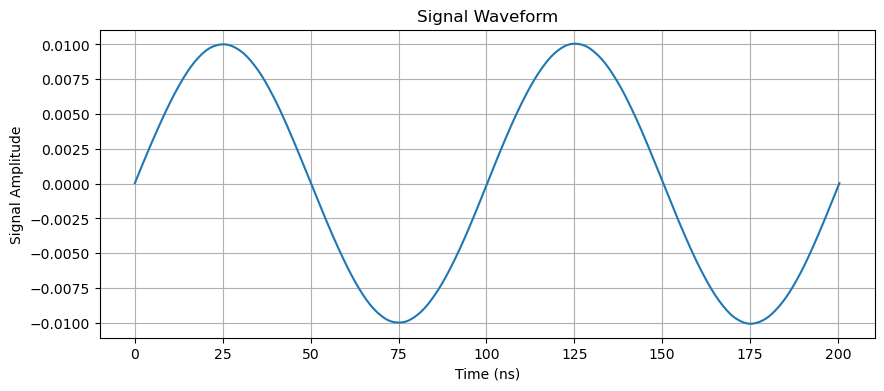

Forward simulation time: 5.39 s
Jacobian computation time: 10.72 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391804, adj=0.391807, ratio=1.0000
  t=50.23: fd=0.392711, adj=0.392714, ratio=1.0000
  t=100.46: fd=0.390696, adj=0.390699, ratio=1.0000
  t=150.68: fd=0.394035, adj=0.394038, ratio=1.0000
  t=200.41: fd=0.391804, adj=0.391807, ratio=1.0000
Forward simulation time: 5.51 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51107880e-08 -3.83003300e-03 -1.52238833e-02
 -3.38773628e-02]
FinDiff J[:,0] = [-0.00033757 -0.00237707 -0.01274143 -0.01640471 -0.03169021]
Ratio: [-0.00000000e+00  6.35688881e-06  3.00596850e-01  9.28018802e-01
  1.06901669e+00]
Forward simulation time: 5.57 s
Iter 57: res=0.060160, res_trial=0.060160, mu=1.000000e-08


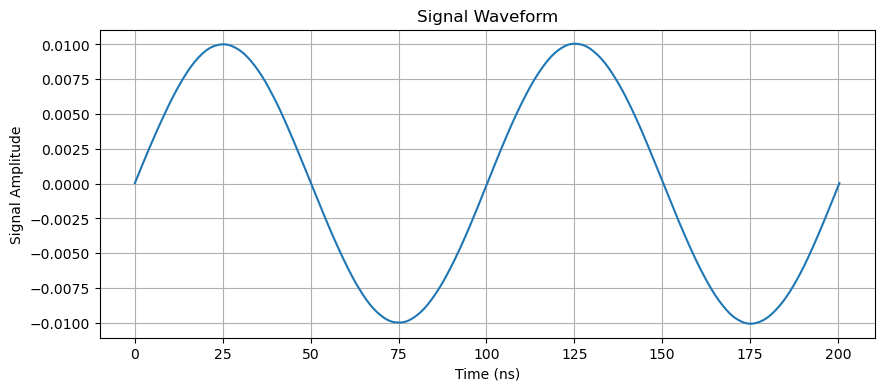

Forward simulation time: 5.42 s
Jacobian computation time: 10.31 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391802, adj=0.391805, ratio=1.0000
  t=50.23: fd=0.392712, adj=0.392715, ratio=1.0000
  t=100.46: fd=0.390695, adj=0.390698, ratio=1.0000
  t=150.68: fd=0.394035, adj=0.394038, ratio=1.0000
  t=200.41: fd=0.391802, adj=0.391805, ratio=1.0000
Forward simulation time: 5.61 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51107191e-08 -3.83001549e-03 -1.52238132e-02
 -3.38772135e-02]
FinDiff J[:,0] = [ 0.0017545  -0.00123458 -0.0103654  -0.01863246 -0.03439459]
Ratio: [0.00000000e+00 1.22395186e-05 3.69500176e-01 8.17058845e-01
 9.84957621e-01]
Forward simulation time: 5.63 s
Iter 58: res=0.060160, res_trial=0.060160, mu=1.000000e-08


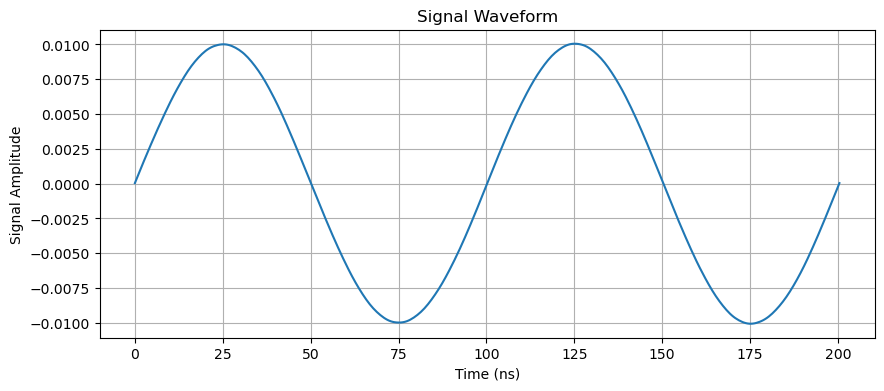

Forward simulation time: 5.96 s
Jacobian computation time: 10.23 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391801, adj=0.391804, ratio=1.0000
  t=50.23: fd=0.392712, adj=0.392715, ratio=1.0000
  t=100.46: fd=0.390695, adj=0.390698, ratio=1.0000
  t=150.68: fd=0.394036, adj=0.394039, ratio=1.0000
  t=200.41: fd=0.391801, adj=0.391804, ratio=1.0000
Forward simulation time: 5.69 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51106508e-08 -3.82999831e-03 -1.52237438e-02
 -3.38770653e-02]
FinDiff J[:,0] = [-0.00355114  0.00056703 -0.00135478 -0.01614229 -0.03455008]
Ratio: [-0.00000000e+00 -2.66489342e-05  2.82702667e+00  9.43096863e-01
  9.80520609e-01]
Forward simulation time: 5.37 s
Iter 59: res=0.060160, res_trial=0.060159, mu=1.000000e-08


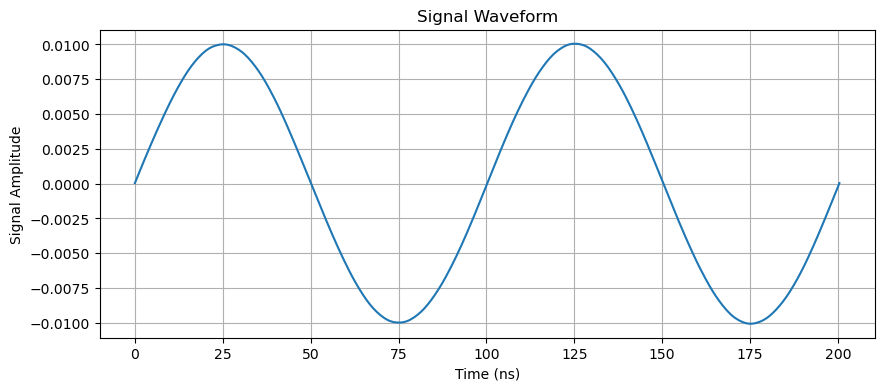

Forward simulation time: 5.52 s
Jacobian computation time: 10.15 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391799, adj=0.391802, ratio=1.0000
  t=50.23: fd=0.392713, adj=0.392716, ratio=1.0000
  t=100.46: fd=0.390695, adj=0.390698, ratio=1.0000
  t=150.68: fd=0.394036, adj=0.394039, ratio=1.0000
  t=200.41: fd=0.391799, adj=0.391802, ratio=1.0000
Forward simulation time: 5.41 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51105836e-08 -3.82998128e-03 -1.52236755e-02
 -3.38769196e-02]
FinDiff J[:,0] = [-0.00082395  0.00487123 -0.0017438  -0.01731834 -0.02999655]
Ratio: [-0.00000000e+00 -3.10200823e-06  2.19634141e+00  8.79049450e-01
  1.12936053e+00]
Forward simulation time: 5.72 s
Iter 60: res=0.060159, res_trial=0.060159, mu=1.000000e-08


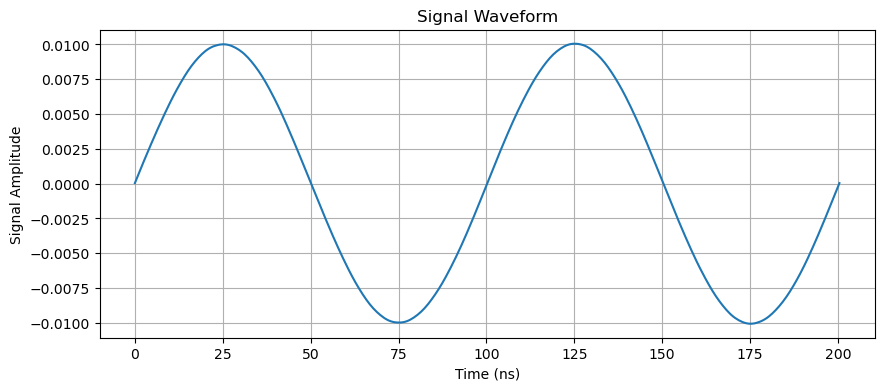

Forward simulation time: 5.24 s
Jacobian computation time: 10.20 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391797, adj=0.391800, ratio=1.0000
  t=50.23: fd=0.392714, adj=0.392717, ratio=1.0000
  t=100.46: fd=0.390694, adj=0.390697, ratio=1.0000
  t=150.68: fd=0.394036, adj=0.394039, ratio=1.0000
  t=200.41: fd=0.391797, adj=0.391800, ratio=1.0000
Forward simulation time: 5.50 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51105172e-08 -3.82996446e-03 -1.52236080e-02
 -3.38767753e-02]
FinDiff J[:,0] = [ 0.00147559  0.00330805 -0.00062919 -0.01808264 -0.03630837]
Ratio: [ 0.00000000e+00 -4.56780497e-06  6.08714455e+00  8.41890923e-01
  9.33029261e-01]
Forward simulation time: 5.44 s
Iter 61: res=0.060159, res_trial=0.060159, mu=1.000000e-08


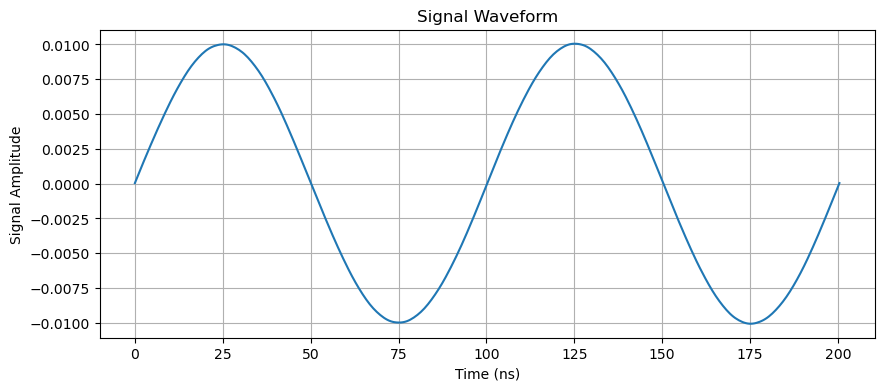

Forward simulation time: 5.60 s
Jacobian computation time: 10.10 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391795, adj=0.391798, ratio=1.0000
  t=50.23: fd=0.392714, adj=0.392717, ratio=1.0000
  t=100.46: fd=0.390694, adj=0.390697, ratio=1.0000
  t=150.68: fd=0.394036, adj=0.394040, ratio=1.0000
  t=200.41: fd=0.391795, adj=0.391798, ratio=1.0000
Forward simulation time: 5.13 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51104520e-08 -3.82994795e-03 -1.52235417e-02
 -3.38766335e-02]
FinDiff J[:,0] = [ 0.00612042 -0.00217206 -0.00300342 -0.01685897 -0.03383515]
Ratio: [0.00000000e+00 6.95674102e-06 1.27519452e+00 9.02993813e-01
 1.00122619e+00]
Forward simulation time: 5.62 s
Iter 62: res=0.060159, res_trial=0.060159, mu=1.000000e-08


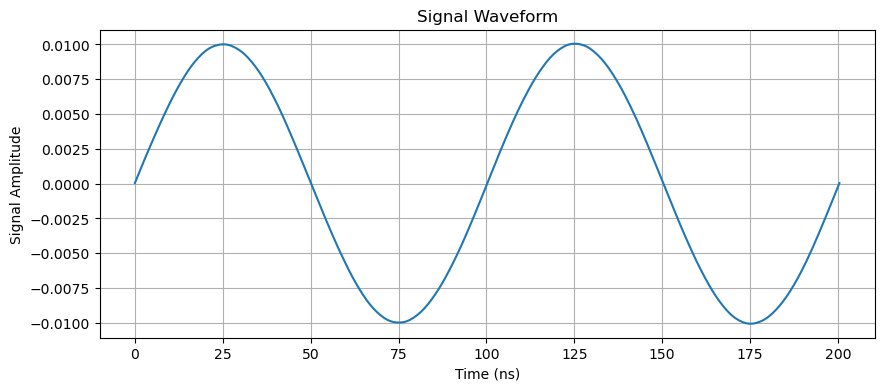

Forward simulation time: 5.64 s
Jacobian computation time: 10.22 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391794, adj=0.391797, ratio=1.0000
  t=50.23: fd=0.392715, adj=0.392718, ratio=1.0000
  t=100.46: fd=0.390694, adj=0.390697, ratio=1.0000
  t=150.68: fd=0.394037, adj=0.394040, ratio=1.0000
  t=200.41: fd=0.391794, adj=0.391797, ratio=1.0000
Forward simulation time: 5.74 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51103872e-08 -3.82993153e-03 -1.52234758e-02
 -3.38764923e-02]
FinDiff J[:,0] = [ 0.00278176  0.00537174 -0.00406457 -0.01885723 -0.03310556]
Ratio: [ 0.00000000e+00 -2.81294349e-06  9.42271189e-01  8.07301964e-01
  1.02328722e+00]
Forward simulation time: 5.08 s
Iter 63: res=0.060159, res_trial=0.060158, mu=1.000000e-08


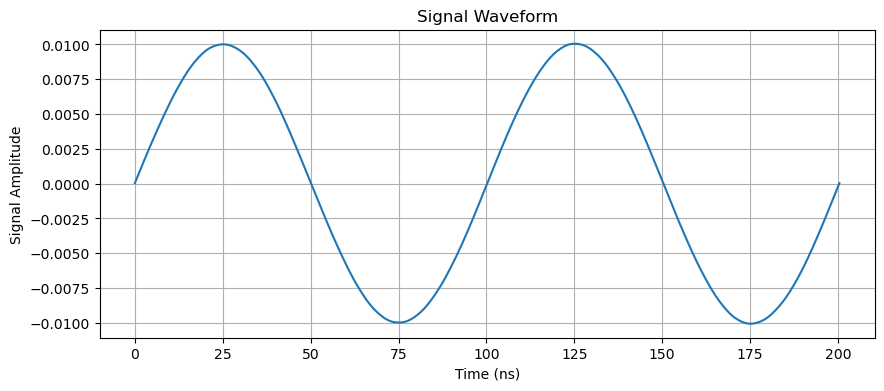

Forward simulation time: 5.42 s
Jacobian computation time: 10.22 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391792, adj=0.391795, ratio=1.0000
  t=50.23: fd=0.392716, adj=0.392719, ratio=1.0000
  t=100.46: fd=0.390693, adj=0.390696, ratio=1.0000
  t=150.68: fd=0.394037, adj=0.394040, ratio=1.0000
  t=200.41: fd=0.391792, adj=0.391795, ratio=1.0000
Forward simulation time: 5.46 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51103236e-08 -3.82991541e-03 -1.52234111e-02
 -3.38763536e-02]
FinDiff J[:,0] = [ 0.00562594  0.00278589 -0.00522689 -0.01572854 -0.03331959]
Ratio: [ 0.00000000e+00 -5.42387269e-06  7.32733367e-01  9.67884613e-01
  1.01670971e+00]
Forward simulation time: 5.17 s
Iter 64: res=0.060158, res_trial=0.060158, mu=1.000000e-08


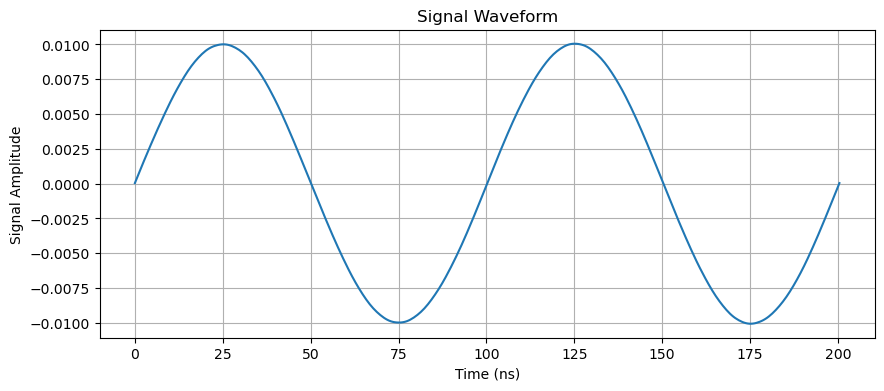

Forward simulation time: 5.53 s
Jacobian computation time: 10.09 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391790, adj=0.391793, ratio=1.0000
  t=50.23: fd=0.392716, adj=0.392719, ratio=1.0000
  t=100.46: fd=0.390693, adj=0.390696, ratio=1.0000
  t=150.68: fd=0.394037, adj=0.394040, ratio=1.0000
  t=200.41: fd=0.391790, adj=0.391793, ratio=1.0000
Forward simulation time: 5.55 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51102608e-08 -3.82989951e-03 -1.52233473e-02
 -3.38762167e-02]
FinDiff J[:,0] = [ 5.91010241e-05  8.72246810e-03 -5.68817691e-03 -1.28730732e-02
 -3.86203874e-02]
Ratio: [ 0.00000000e+00 -1.73233775e-06  6.73308789e-01  1.18257288e+00
  8.77158905e-01]
Forward simulation time: 5.65 s
Iter 65: res=0.060158, res_trial=0.060158, mu=1.000000e-08


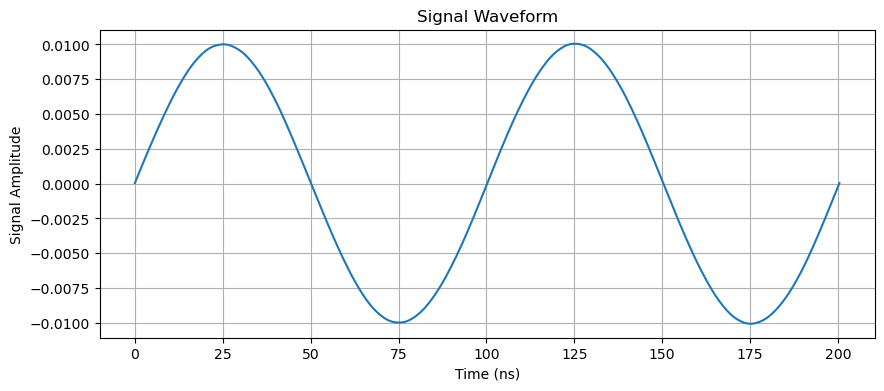

Forward simulation time: 5.29 s
Jacobian computation time: 10.60 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391789, adj=0.391792, ratio=1.0000
  t=50.23: fd=0.392717, adj=0.392720, ratio=1.0000
  t=100.46: fd=0.390693, adj=0.390696, ratio=1.0000
  t=150.68: fd=0.394038, adj=0.394041, ratio=1.0000
  t=200.41: fd=0.391789, adj=0.391792, ratio=1.0000
Forward simulation time: 5.52 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51101989e-08 -3.82988383e-03 -1.52232844e-02
 -3.38760818e-02]
FinDiff J[:,0] = [-4.54588256e-05 -4.75696509e-03 -6.36809798e-03 -1.54956287e-02
 -3.35956007e-02]
Ratio: [-0.00000000e+00  3.17643678e-06  6.01417227e-01  9.82424443e-01
  1.00834874e+00]
Forward simulation time: 5.63 s
Iter 66: res=0.060158, res_trial=0.060157, mu=1.000000e-08


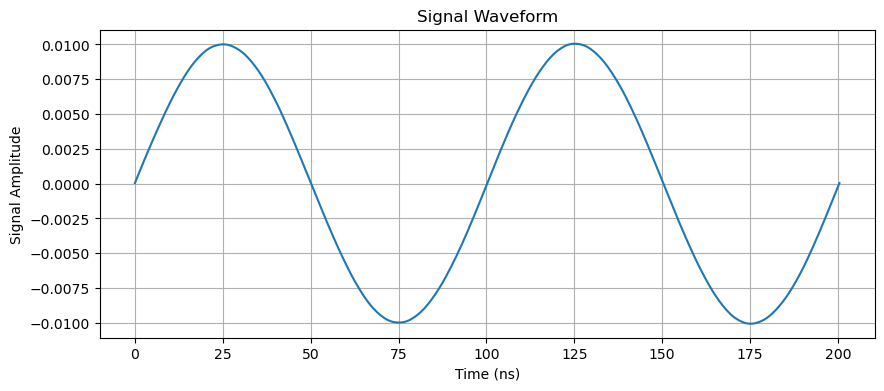

Forward simulation time: 5.23 s
Jacobian computation time: 9.89 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391787, adj=0.391790, ratio=1.0000
  t=50.23: fd=0.392717, adj=0.392721, ratio=1.0000
  t=100.46: fd=0.390692, adj=0.390695, ratio=1.0000
  t=150.68: fd=0.394038, adj=0.394041, ratio=1.0000
  t=200.41: fd=0.391787, adj=0.391790, ratio=1.0000
Forward simulation time: 5.48 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51101376e-08 -3.82986830e-03 -1.52232221e-02
 -3.38759479e-02]
FinDiff J[:,0] = [ 0.00364915  0.00272906 -0.00493685 -0.01778626 -0.03686212]
Ratio: [ 0.00000000e+00 -5.53675947e-06  7.75771203e-01  8.55897792e-01
  9.18990761e-01]
Forward simulation time: 5.54 s
Iter 67: res=0.060157, res_trial=0.060157, mu=1.000000e-08


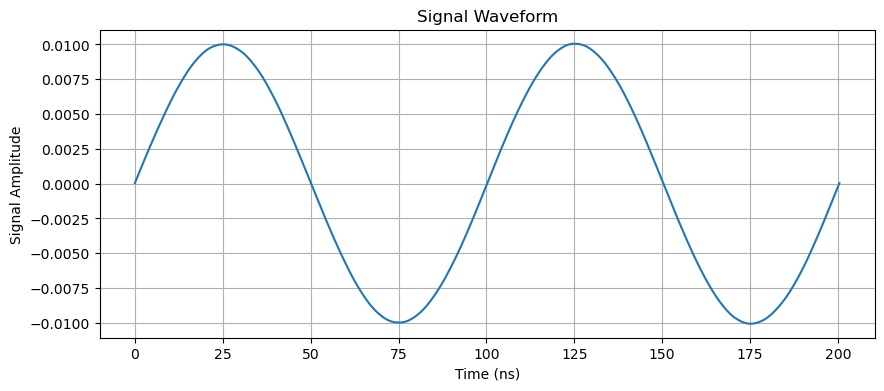

Forward simulation time: 5.62 s
Jacobian computation time: 10.06 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391785, adj=0.391788, ratio=1.0000
  t=50.23: fd=0.392718, adj=0.392721, ratio=1.0000
  t=100.46: fd=0.390692, adj=0.390695, ratio=1.0000
  t=150.68: fd=0.394038, adj=0.394041, ratio=1.0000
  t=200.41: fd=0.391785, adj=0.391788, ratio=1.0000
Forward simulation time: 5.54 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51100771e-08 -3.82985297e-03 -1.52231606e-02
 -3.38758156e-02]
FinDiff J[:,0] = [-0.00196529 -0.00012781 -0.00207106 -0.00866194 -0.02894096]
Ratio: [-0.00000000e+00  1.18221602e-04  1.84922692e+00  1.75747693e+00
  1.17051469e+00]
Forward simulation time: 5.32 s
Iter 68: res=0.060157, res_trial=0.060157, mu=1.000000e-08


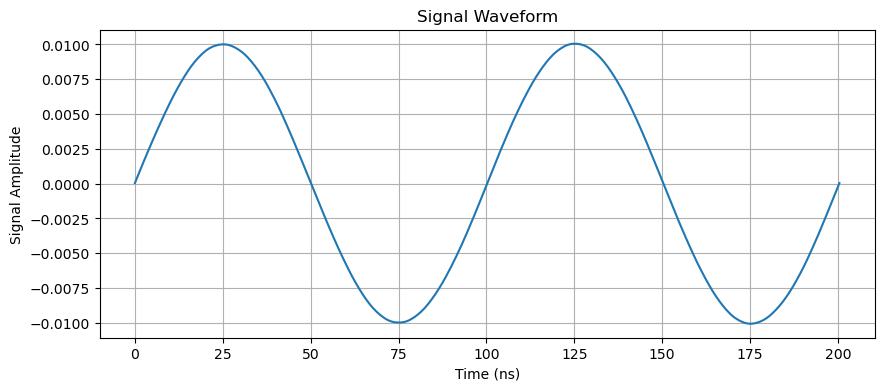

Forward simulation time: 5.84 s
Jacobian computation time: 10.26 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391784, adj=0.391787, ratio=1.0000
  t=50.23: fd=0.392719, adj=0.392722, ratio=1.0000
  t=100.46: fd=0.390692, adj=0.390695, ratio=1.0000
  t=150.68: fd=0.394038, adj=0.394042, ratio=1.0000
  t=200.41: fd=0.391784, adj=0.391787, ratio=1.0000
Forward simulation time: 5.89 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51100176e-08 -3.82983791e-03 -1.52231001e-02
 -3.38756851e-02]
FinDiff J[:,0] = [ 0.00067279 -0.0005442   0.00049697 -0.01593639 -0.03704184]
Ratio: [ 0.00000000e+00  2.77653163e-05 -7.70643399e+00  9.55241546e-01
  9.14524942e-01]
Forward simulation time: 5.94 s
Iter 69: res=0.060157, res_trial=0.060157, mu=1.000000e-08


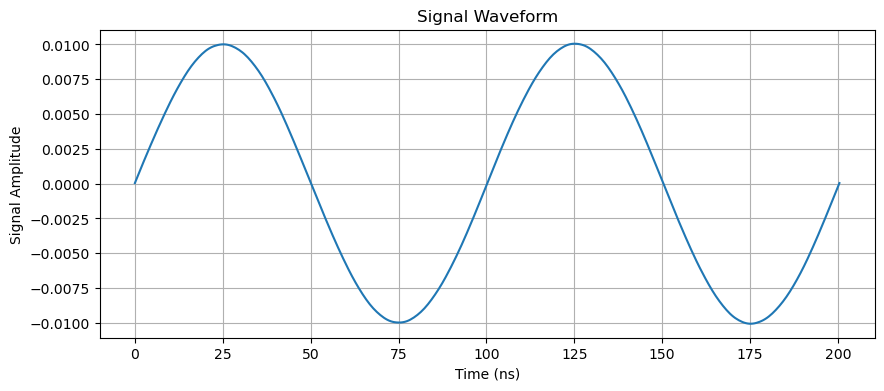

Forward simulation time: 5.31 s
Jacobian computation time: 10.46 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391782, adj=0.391785, ratio=1.0000
  t=50.23: fd=0.392719, adj=0.392722, ratio=1.0000
  t=100.46: fd=0.390692, adj=0.390695, ratio=1.0000
  t=150.68: fd=0.394039, adj=0.394042, ratio=1.0000
  t=200.41: fd=0.391782, adj=0.391785, ratio=1.0000
Forward simulation time: 5.72 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51099587e-08 -3.82982297e-03 -1.52230402e-02
 -3.38755560e-02]
FinDiff J[:,0] = [-0.00128225  0.00208414 -0.00606324 -0.01654231 -0.03375458]
Ratio: [-0.00000000e+00 -7.24998507e-06  6.31646525e-01  9.20248651e-01
  1.00358391e+00]
Forward simulation time: 5.53 s
Iter 70: res=0.060157, res_trial=0.060156, mu=1.000000e-08


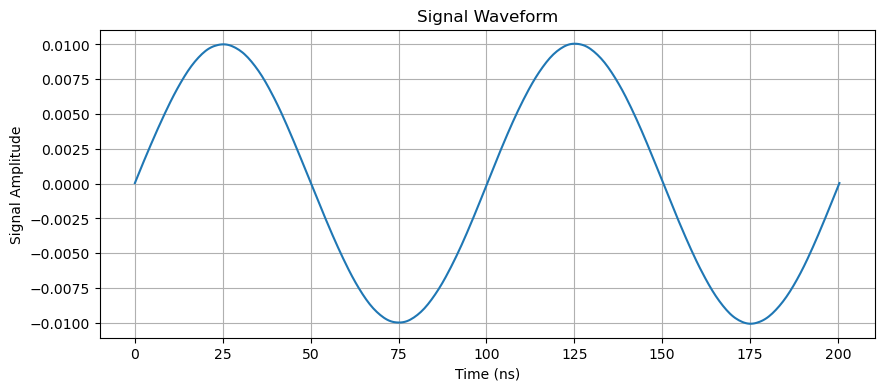

Forward simulation time: 5.61 s
Jacobian computation time: 10.54 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391781, adj=0.391784, ratio=1.0000
  t=50.23: fd=0.392720, adj=0.392723, ratio=1.0000
  t=100.46: fd=0.390691, adj=0.390694, ratio=1.0000
  t=150.68: fd=0.394039, adj=0.394042, ratio=1.0000
  t=200.41: fd=0.391781, adj=0.391784, ratio=1.0000
Forward simulation time: 5.38 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51099006e-08 -3.82980827e-03 -1.52229812e-02
 -3.38754290e-02]
FinDiff J[:,0] = [-1.03426385e-03  1.52836632e-06 -1.90296239e-03 -1.43981257e-02
 -3.57934567e-02]
Ratio: [-0.         -0.00988631  2.01255069  1.05728909  0.94641401]
Forward simulation time: 5.68 s
Iter 71: res=0.060156, res_trial=0.060156, mu=1.000000e-08


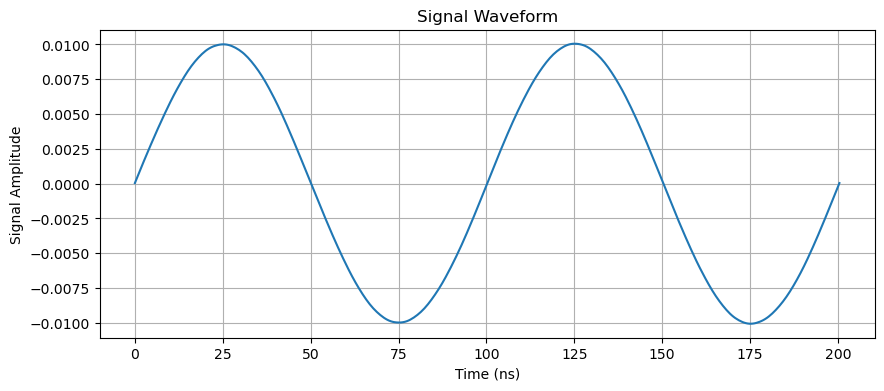

Forward simulation time: 5.65 s
Jacobian computation time: 10.38 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391779, adj=0.391782, ratio=1.0000
  t=50.23: fd=0.392720, adj=0.392723, ratio=1.0000
  t=100.46: fd=0.390691, adj=0.390694, ratio=1.0000
  t=150.68: fd=0.394039, adj=0.394042, ratio=1.0000
  t=200.41: fd=0.391779, adj=0.391782, ratio=1.0000
Forward simulation time: 5.78 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51098433e-08 -3.82979376e-03 -1.52229229e-02
 -3.38753029e-02]
FinDiff J[:,0] = [ 0.0011939   0.00272397 -0.00612999 -0.01557672 -0.03878239]
Ratio: [ 0.00000000e+00 -5.54699551e-06  6.24763558e-01  9.77287012e-01
  8.73471317e-01]
Forward simulation time: 5.26 s
Iter 72: res=0.060156, res_trial=0.060156, mu=1.000000e-08


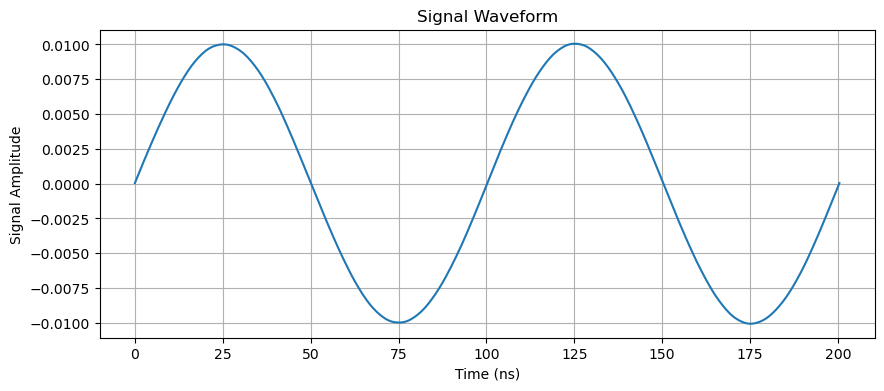

Forward simulation time: 5.61 s
Jacobian computation time: 10.24 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391778, adj=0.391781, ratio=1.0000
  t=50.23: fd=0.392721, adj=0.392724, ratio=1.0000
  t=100.46: fd=0.390691, adj=0.390694, ratio=1.0000
  t=150.68: fd=0.394039, adj=0.394043, ratio=1.0000
  t=200.41: fd=0.391778, adj=0.391781, ratio=1.0000
Forward simulation time: 7.32 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51097868e-08 -3.82977944e-03 -1.52228655e-02
 -3.38751790e-02]
FinDiff J[:,0] = [ 0.00164323  0.00255066 -0.00247887 -0.0130064  -0.03511384]
Ratio: [ 0.00000000e+00 -5.92386915e-06  1.54496922e+00  1.17041319e+00
  9.64724453e-01]
Forward simulation time: 7.25 s
Iter 73: res=0.060156, res_trial=0.060156, mu=1.000000e-08


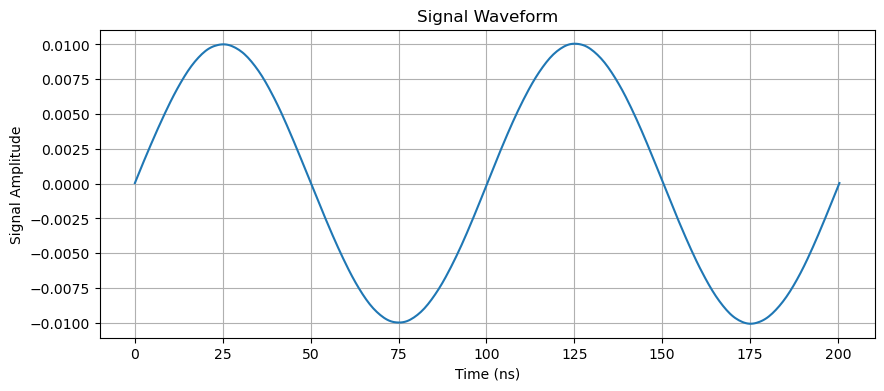

Forward simulation time: 6.12 s
Jacobian computation time: 10.35 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391776, adj=0.391779, ratio=1.0000
  t=50.23: fd=0.392721, adj=0.392724, ratio=1.0000
  t=100.46: fd=0.390691, adj=0.390694, ratio=1.0000
  t=150.68: fd=0.394040, adj=0.394043, ratio=1.0000
  t=200.41: fd=0.391776, adj=0.391779, ratio=1.0000
Forward simulation time: 5.85 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51097310e-08 -3.82976530e-03 -1.52228087e-02
 -3.38750561e-02]
FinDiff J[:,0] = [-0.00089357 -0.00016195  0.00264986 -0.01533731 -0.0305477 ]
Ratio: [-0.00000000e+00  9.32973665e-05 -1.44526959e+00  9.92534496e-01
  1.10892332e+00]
Forward simulation time: 6.12 s
Iter 74: res=0.060156, res_trial=0.060156, mu=1.000000e-08


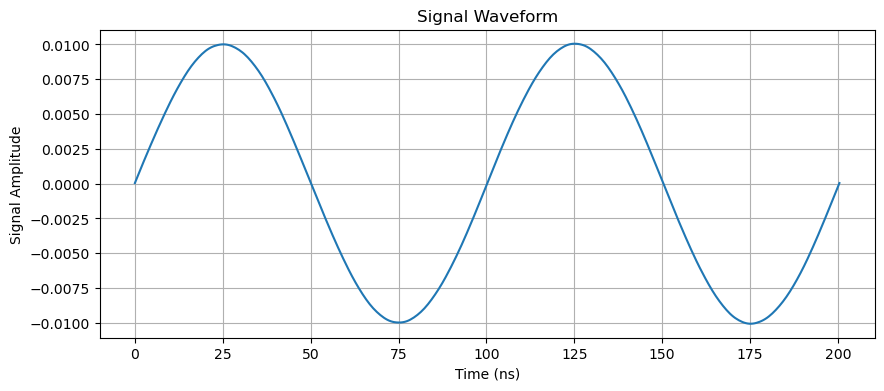

Forward simulation time: 6.31 s
Jacobian computation time: 10.70 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391775, adj=0.391778, ratio=1.0000
  t=50.23: fd=0.392722, adj=0.392725, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390694, ratio=1.0000
  t=150.68: fd=0.394040, adj=0.394043, ratio=1.0000
  t=200.41: fd=0.391775, adj=0.391778, ratio=1.0000
Forward simulation time: 5.62 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51096759e-08 -3.82975134e-03 -1.52227527e-02
 -3.38749350e-02]
FinDiff J[:,0] = [-0.00060629  0.00377534 -0.00108286 -0.01925564 -0.04005107]
Ratio: [-0.00000000e+00 -4.00220093e-06  3.53668508e+00  7.90560561e-01
  8.45793439e-01]
Forward simulation time: 5.78 s
Iter 75: res=0.060156, res_trial=0.060155, mu=1.000000e-08


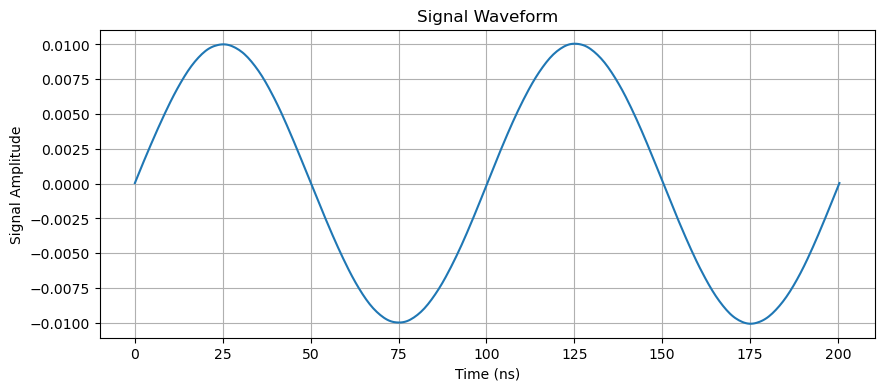

Forward simulation time: 5.40 s
Jacobian computation time: 10.78 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391773, adj=0.391777, ratio=1.0000
  t=50.23: fd=0.392722, adj=0.392725, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394040, adj=0.394043, ratio=1.0000
  t=200.41: fd=0.391773, adj=0.391777, ratio=1.0000
Forward simulation time: 6.67 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51096214e-08 -3.82973755e-03 -1.52226974e-02
 -3.38748154e-02]
FinDiff J[:,0] = [ 0.00268651 -0.00542228 -0.0015127  -0.01727199 -0.03177142]
Ratio: [0.00000000e+00 2.78658068e-06 2.53171906e+00 8.81351885e-01
 1.06620400e+00]
Forward simulation time: 5.69 s
Iter 76: res=0.060155, res_trial=0.060155, mu=1.000000e-08


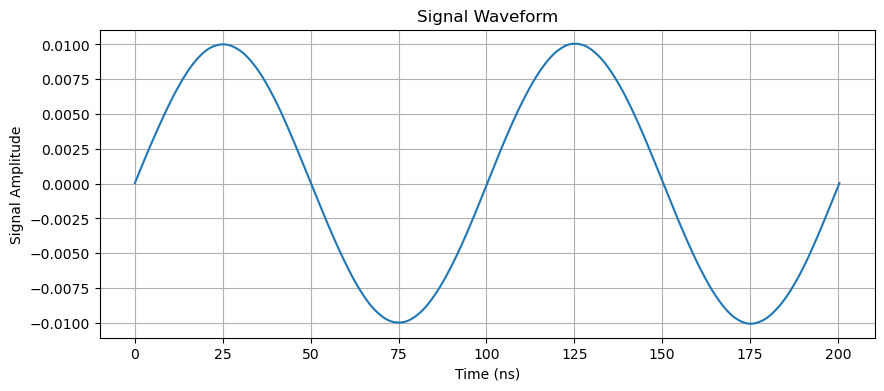

Forward simulation time: 5.93 s
Jacobian computation time: 10.65 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391772, adj=0.391775, ratio=1.0000
  t=50.23: fd=0.392723, adj=0.392726, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394040, adj=0.394043, ratio=1.0000
  t=200.41: fd=0.391772, adj=0.391775, ratio=1.0000
Forward simulation time: 5.75 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51095676e-08 -3.82972390e-03 -1.52226426e-02
 -3.38746964e-02]
FinDiff J[:,0] = [ 0.00211153  0.00373111 -0.00405099 -0.01276954 -0.03596758]
Ratio: [ 0.00000000e+00 -4.04961276e-06  9.45380524e-01  1.19210617e+00
  9.41811915e-01]
Forward simulation time: 5.63 s
Iter 77: res=0.060155, res_trial=0.060155, mu=1.000000e-08


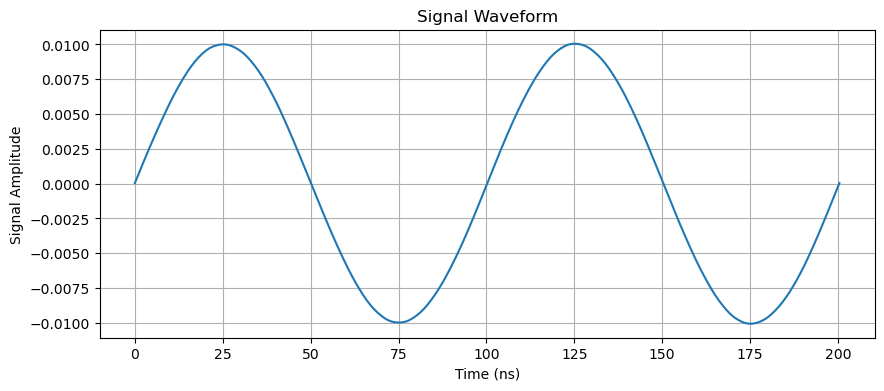

Forward simulation time: 6.33 s
Jacobian computation time: 10.29 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391771, adj=0.391774, ratio=1.0000
  t=50.23: fd=0.392723, adj=0.392726, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394044, ratio=1.0000
  t=200.41: fd=0.391771, adj=0.391774, ratio=1.0000
Forward simulation time: 5.61 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51095146e-08 -3.82971047e-03 -1.52225887e-02
 -3.38745794e-02]
FinDiff J[:,0] = [ 0.00084548 -0.00342334 -0.00503139 -0.01927918 -0.03656217]
Ratio: [0.00000000e+00 4.41367671e-06 7.61163723e-01 7.89586835e-01
 9.26492678e-01]
Forward simulation time: 5.79 s
Iter 78: res=0.060155, res_trial=0.060155, mu=1.000000e-08


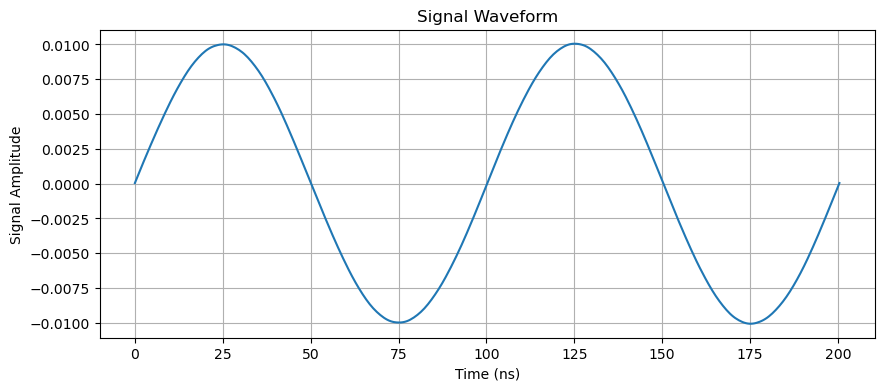

Forward simulation time: 5.25 s
Jacobian computation time: 10.71 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391769, adj=0.391772, ratio=1.0000
  t=50.23: fd=0.392724, adj=0.392727, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394044, ratio=1.0000
  t=200.41: fd=0.391769, adj=0.391772, ratio=1.0000
Forward simulation time: 5.71 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51094620e-08 -3.82969715e-03 -1.52225352e-02
 -3.38744635e-02]
FinDiff J[:,0] = [-0.00251197 -0.00049522 -0.00360871 -0.01748538 -0.03542285]
Ratio: [-0.00000000e+00  3.05108776e-05  1.06123700e+00  8.70586622e-01
  9.56288350e-01]
Forward simulation time: 5.62 s
Iter 79: res=0.060155, res_trial=0.060154, mu=1.000000e-08


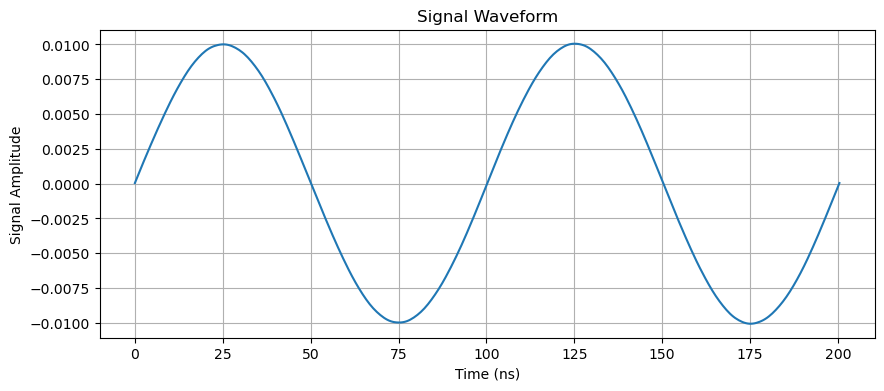

Forward simulation time: 5.81 s
Jacobian computation time: 10.25 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391768, adj=0.391771, ratio=1.0000
  t=50.23: fd=0.392724, adj=0.392727, ratio=1.0000
  t=100.46: fd=0.390690, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394044, ratio=1.0000
  t=200.41: fd=0.391768, adj=0.391771, ratio=1.0000
Forward simulation time: 5.31 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51094102e-08 -3.82968404e-03 -1.52224827e-02
 -3.38743492e-02]
FinDiff J[:,0] = [ 0.00449554  0.00066591 -0.00379339 -0.01568613 -0.03517767]
Ratio: [ 0.00000000e+00 -2.26900331e-05  1.00956739e+00  9.70442310e-01
  9.62950363e-01]
Forward simulation time: 5.81 s
Iter 80: res=0.060154, res_trial=0.060154, mu=1.000000e-08


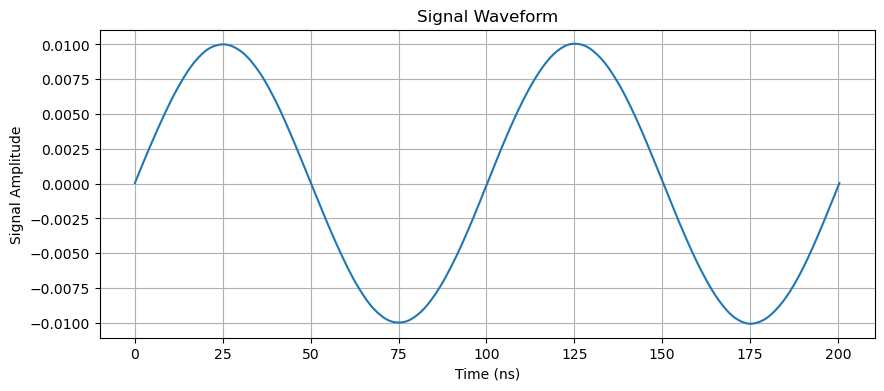

Forward simulation time: 5.60 s
Jacobian computation time: 10.42 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391767, adj=0.391770, ratio=1.0000
  t=50.23: fd=0.392725, adj=0.392728, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390693, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394044, ratio=1.0000
  t=200.41: fd=0.391767, adj=0.391770, ratio=1.0000
Forward simulation time: 7.56 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51093591e-08 -3.82967109e-03 -1.52224306e-02
 -3.38742363e-02]
FinDiff J[:,0] = [ 0.00280662 -0.00375607 -0.00294362 -0.01753622 -0.03332463]
Ratio: [0.00000000e+00 4.02265103e-06 1.30100820e+00 8.68056759e-01
 1.01649238e+00]
Forward simulation time: 7.11 s
Iter 81: res=0.060154, res_trial=0.060154, mu=1.000000e-08


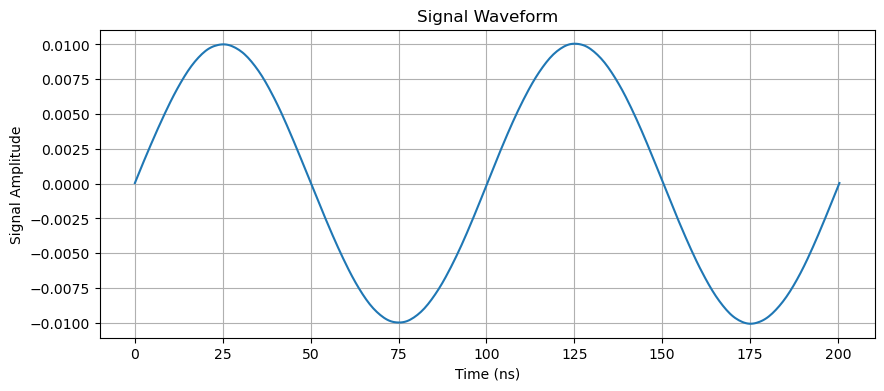

Forward simulation time: 7.42 s
Jacobian computation time: 10.96 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391765, adj=0.391768, ratio=1.0000
  t=50.23: fd=0.392725, adj=0.392728, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394044, ratio=1.0000
  t=200.41: fd=0.391765, adj=0.391768, ratio=1.0000
Forward simulation time: 5.65 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51093088e-08 -3.82965835e-03 -1.52223796e-02
 -3.38741253e-02]
FinDiff J[:,0] = [ 0.00017632 -0.00025893 -0.00317505 -0.01179512 -0.03639133]
Ratio: [0.00000000e+00 5.83533336e-05 1.20617194e+00 1.29056544e+00
 9.30829603e-01]
Forward simulation time: 5.38 s
Iter 82: res=0.060154, res_trial=0.060154, mu=1.000000e-08


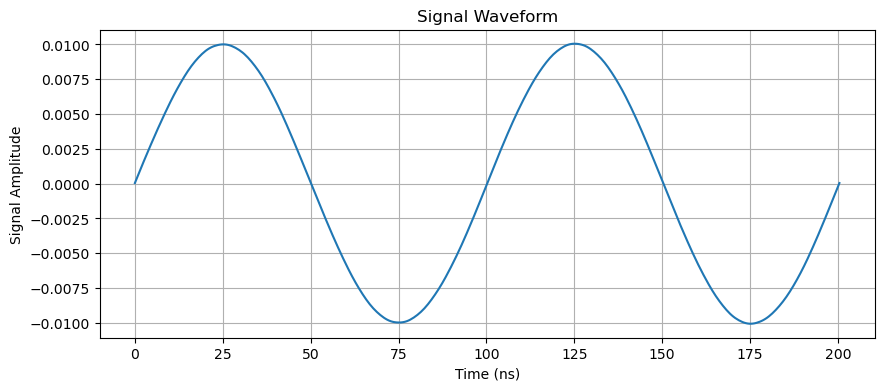

Forward simulation time: 5.69 s
Jacobian computation time: 10.14 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391764, adj=0.391767, ratio=1.0000
  t=50.23: fd=0.392725, adj=0.392728, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394041, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391764, adj=0.391767, ratio=1.0000
Forward simulation time: 5.67 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51092589e-08 -3.82964569e-03 -1.52223288e-02
 -3.38740144e-02]
FinDiff J[:,0] = [ 0.00414698 -0.00621996 -0.00827009 -0.01050684 -0.03236304]
Ratio: [0.00000000e+00 2.42915851e-06 4.63072070e-01 1.44880237e+00
 1.04668820e+00]
Forward simulation time: 5.85 s
Iter 83: res=0.060154, res_trial=0.060154, mu=1.000000e-08


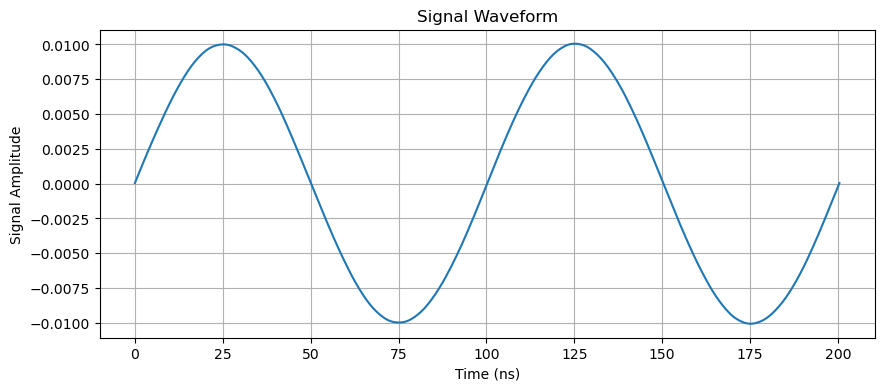

Forward simulation time: 5.25 s
Jacobian computation time: 13.42 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391763, adj=0.391766, ratio=1.0000
  t=50.23: fd=0.392726, adj=0.392729, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391763, adj=0.391766, ratio=1.0000
Forward simulation time: 5.52 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51092098e-08 -3.82963326e-03 -1.52222789e-02
 -3.38739057e-02]
FinDiff J[:,0] = [ 0.00302982  0.00271568 -0.00143862 -0.01359121 -0.03584878]
Ratio: [ 0.00000000e+00 -5.56369751e-06  2.66201462e+00  1.12000911e+00
  9.44910879e-01]
Forward simulation time: 5.58 s
Iter 84: res=0.060154, res_trial=0.060154, mu=1.000000e-08


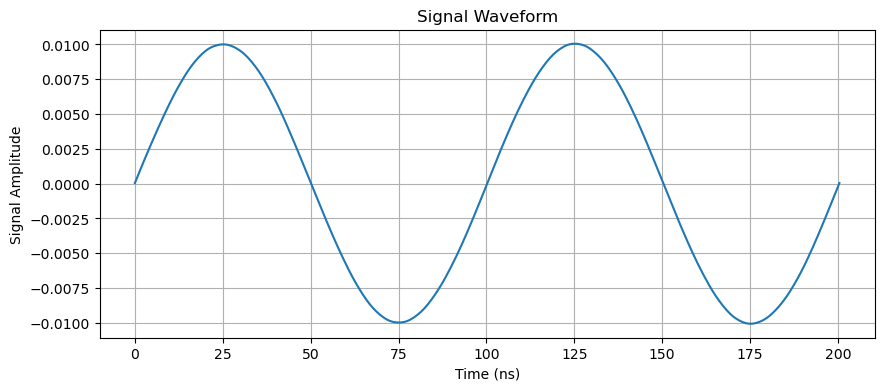

Forward simulation time: 7.78 s
Jacobian computation time: 11.18 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391762, adj=0.391765, ratio=1.0000
  t=50.23: fd=0.392726, adj=0.392729, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391762, adj=0.391765, ratio=1.0000
Forward simulation time: 2610.70 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51091609e-08 -3.82962089e-03 -1.52222292e-02
 -3.38737972e-02]
FinDiff J[:,0] = [ 0.00436211 -0.00339798 -0.00229972 -0.01522179 -0.03919745]
Ratio: [0.00000000e+00 4.44651571e-06 1.66525541e+00 1.00002894e+00
 8.64183605e-01]
Forward simulation time: 5.47 s
Iter 85: res=0.060154, res_trial=0.060154, mu=1.000000e-08


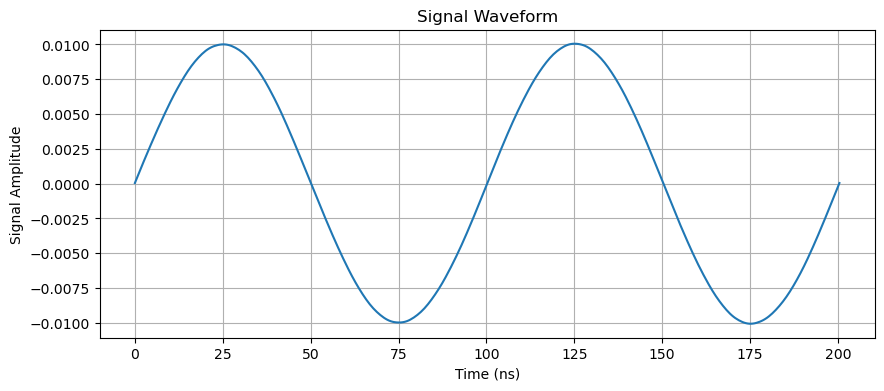

Forward simulation time: 5.64 s
Jacobian computation time: 10.17 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391760, adj=0.391763, ratio=1.0000
  t=50.23: fd=0.392727, adj=0.392730, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391760, adj=0.391763, ratio=1.0000
Forward simulation time: 5.60 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51091129e-08 -3.82960873e-03 -1.52221804e-02
 -3.38736908e-02]
FinDiff J[:,0] = [-0.00108519  0.00096537  0.00399652 -0.02144087 -0.03547467]
Ratio: [-0.00000000e+00 -1.56511137e-05 -9.58235176e-01  7.09961009e-01
  9.54869847e-01]
Forward simulation time: 5.11 s
Iter 86: res=0.060154, res_trial=0.060153, mu=1.000000e-08


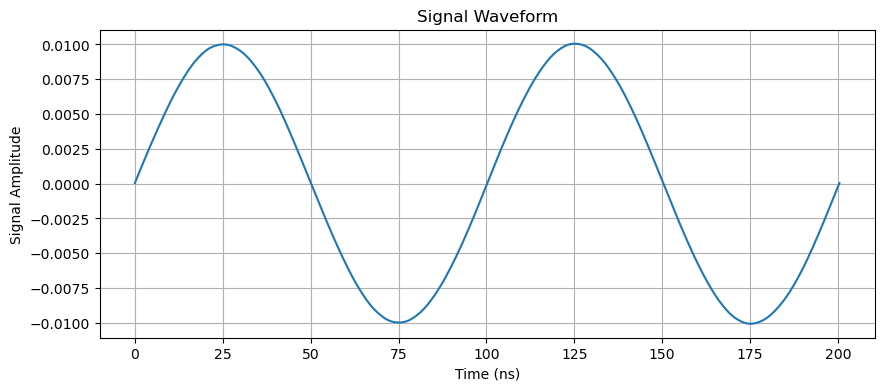

Forward simulation time: 5.61 s
Jacobian computation time: 10.07 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391759, adj=0.391762, ratio=1.0000
  t=50.23: fd=0.392727, adj=0.392730, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391759, adj=0.391762, ratio=1.0000
Forward simulation time: 5.44 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51090655e-08 -3.82959673e-03 -1.52221323e-02
 -3.38735854e-02]
FinDiff J[:,0] = [-0.00180423  0.00215811 -0.00553241 -0.01299814 -0.03322087]
Ratio: [-0.00000000e+00 -7.00107491e-06  6.92211679e-01  1.17110082e+00
  1.01964791e+00]
Forward simulation time: 5.69 s
Iter 87: res=0.060153, res_trial=0.060153, mu=1.000000e-08


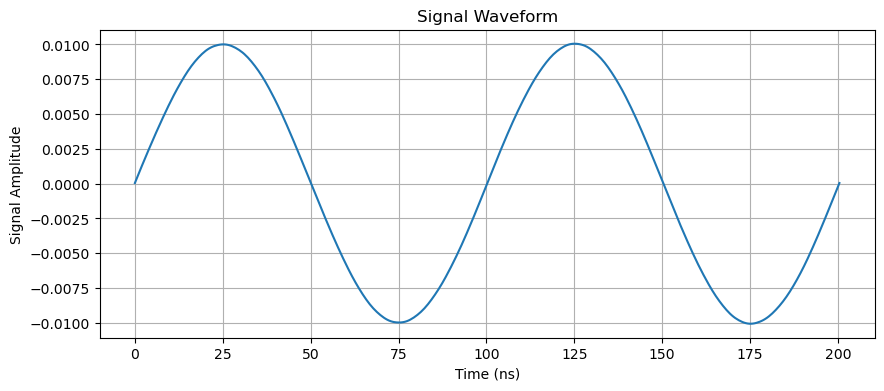

Forward simulation time: 5.17 s
Jacobian computation time: 9.97 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391758, adj=0.391761, ratio=1.0000
  t=50.23: fd=0.392727, adj=0.392730, ratio=1.0000
  t=100.46: fd=0.390689, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394045, ratio=1.0000
  t=200.41: fd=0.391758, adj=0.391761, ratio=1.0000
Forward simulation time: 5.73 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51090187e-08 -3.82958486e-03 -1.52220846e-02
 -3.38734817e-02]
FinDiff J[:,0] = [ 0.00279649 -0.00223061 -0.00603618 -0.01451064 -0.04063318]
Ratio: [0.00000000e+00 6.77348415e-06 6.34438424e-01 1.04902950e+00
 8.33640972e-01]
Forward simulation time: 5.63 s
Iter 88: res=0.060153, res_trial=0.060153, mu=1.000000e-08


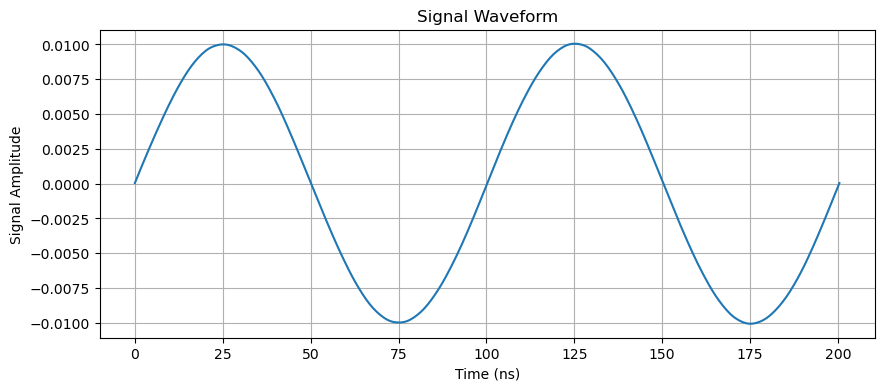

Forward simulation time: 5.68 s
Jacobian computation time: 10.25 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391757, adj=0.391760, ratio=1.0000
  t=50.23: fd=0.392728, adj=0.392731, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390692, ratio=1.0000
  t=150.68: fd=0.394042, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391757, adj=0.391760, ratio=1.0000
Forward simulation time: 5.28 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51089725e-08 -3.82957315e-03 -1.52220376e-02
 -3.38733790e-02]
FinDiff J[:,0] = [-0.00131068  0.00010186 -0.00588158 -0.01768679 -0.0354227 ]
Ratio: [-0.00000000e+00 -1.48324066e-04  6.51113164e-01  8.60644569e-01
  9.56261968e-01]
Forward simulation time: 5.70 s
Iter 89: res=0.060153, res_trial=0.060153, mu=1.000000e-08


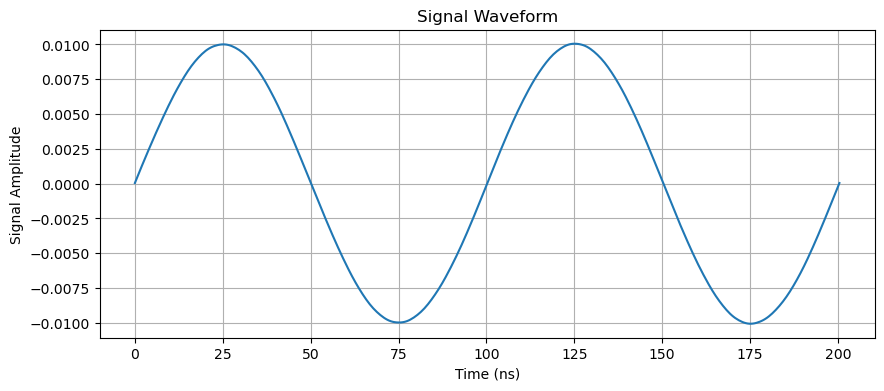

Forward simulation time: 5.63 s
Jacobian computation time: 10.13 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391756, adj=0.391759, ratio=1.0000
  t=50.23: fd=0.392728, adj=0.392731, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391756, adj=0.391759, ratio=1.0000
Forward simulation time: 5.78 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51089267e-08 -3.82956156e-03 -1.52219911e-02
 -3.38732769e-02]
FinDiff J[:,0] = [-0.00025032  0.00337837  0.00328948 -0.01881592 -0.03346176]
Ratio: [-0.00000000e+00 -4.47224916e-06 -1.16418362e+00  8.08995144e-01
  1.01229809e+00]
Forward simulation time: 5.35 s
Iter 90: res=0.060153, res_trial=0.060153, mu=1.000000e-08


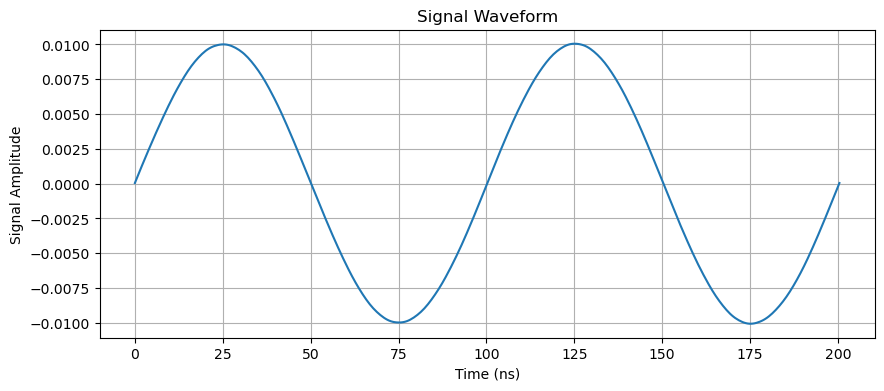

Forward simulation time: 5.63 s
Jacobian computation time: 12.51 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391755, adj=0.391758, ratio=1.0000
  t=50.23: fd=0.392728, adj=0.392732, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391755, adj=0.391758, ratio=1.0000
Forward simulation time: 6.31 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51088816e-08 -3.82955012e-03 -1.52219452e-02
 -3.38731763e-02]
FinDiff J[:,0] = [-0.00309434  0.00375407 -0.00491882 -0.01629987 -0.03669175]
Ratio: [-0.00000000e+00 -4.02466534e-06  7.78549919e-01  9.33868878e-01
  9.23182366e-01]
Forward simulation time: 5.44 s
Iter 91: res=0.060153, res_trial=0.060152, mu=1.000000e-08


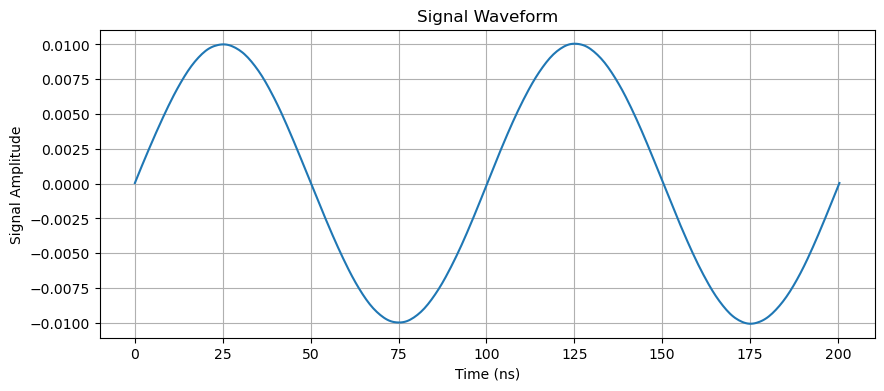

Forward simulation time: 8.23 s
Jacobian computation time: 14.46 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391753, adj=0.391756, ratio=1.0000
  t=50.23: fd=0.392729, adj=0.392732, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391753, adj=0.391756, ratio=1.0000
Forward simulation time: 8.04 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51088368e-08 -3.82953878e-03 -1.52218997e-02
 -3.38730762e-02]
FinDiff J[:,0] = [-2.52313392e-05 -7.37798644e-04 -5.03973649e-03 -1.65900126e-02
 -3.44560401e-02]
Ratio: [-0.00000000e+00  2.04782658e-05  7.59868851e-01  9.17533947e-01
  9.83080937e-01]
Forward simulation time: 8.27 s
Iter 92: res=0.060152, res_trial=0.060152, mu=1.000000e-08


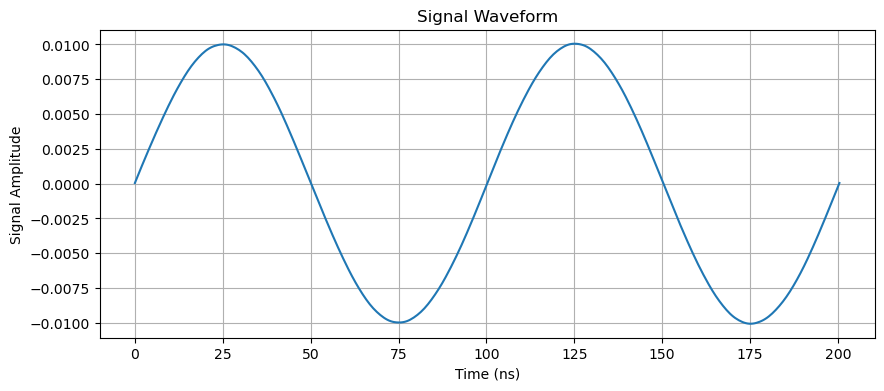

Forward simulation time: 7.96 s
Jacobian computation time: 15.47 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391752, adj=0.391755, ratio=1.0000
  t=50.23: fd=0.392729, adj=0.392732, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391752, adj=0.391755, ratio=1.0000
Forward simulation time: 8.31 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51087928e-08 -3.82952764e-03 -1.52218550e-02
 -3.38729785e-02]
FinDiff J[:,0] = [ 0.0024985   0.00016372 -0.0081105  -0.01410663 -0.03095123]
Ratio: [ 0.00000000e+00 -9.22852367e-05  4.72169169e-01  1.07905690e+00
  1.09439842e+00]
Forward simulation time: 8.04 s
Iter 93: res=0.060152, res_trial=0.060152, mu=1.000000e-08


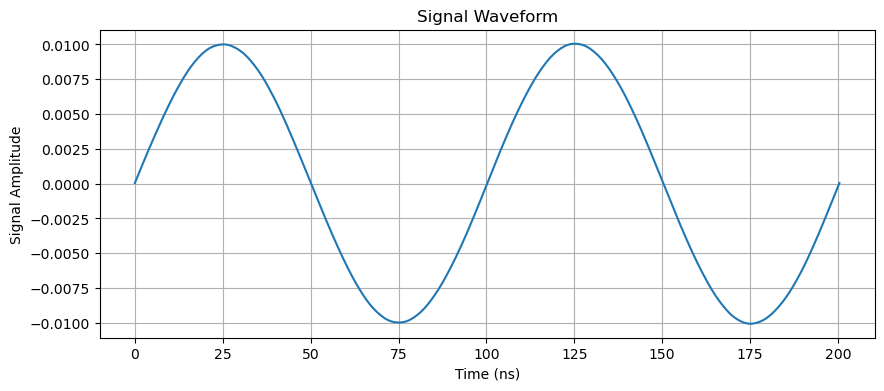

Forward simulation time: 7.60 s
Jacobian computation time: 13.63 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391751, adj=0.391754, ratio=1.0000
  t=50.23: fd=0.392729, adj=0.392733, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391751, adj=0.391754, ratio=1.0000
Forward simulation time: 6.47 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51087491e-08 -3.82951655e-03 -1.52218105e-02
 -3.38728809e-02]
FinDiff J[:,0] = [-0.00017071 -0.00331463 -0.00483715 -0.01182944 -0.03527511]
Ratio: [-0.00000000e+00  4.55820052e-06  7.91689112e-01  1.28677327e+00
  9.60248738e-01]
Forward simulation time: 5.66 s
Iter 94: res=0.060152, res_trial=0.060152, mu=1.000000e-08


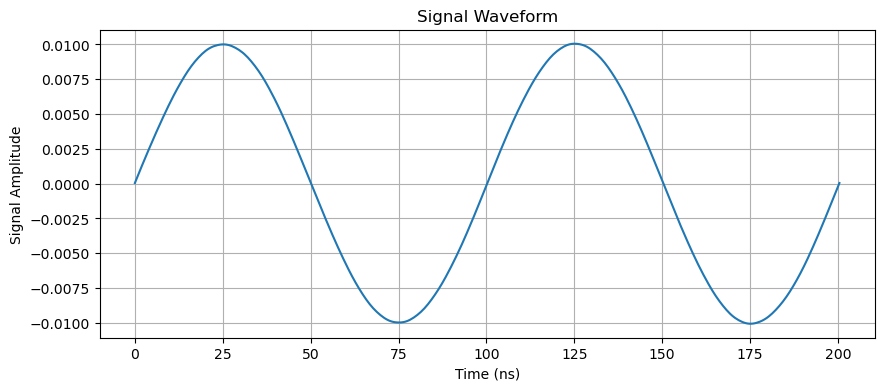

Forward simulation time: 5.91 s
Jacobian computation time: 10.36 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391750, adj=0.391753, ratio=1.0000
  t=50.23: fd=0.392730, adj=0.392733, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391750, adj=0.391753, ratio=1.0000
Forward simulation time: 5.64 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51087059e-08 -3.82950563e-03 -1.52217667e-02
 -3.38727841e-02]
FinDiff J[:,0] = [-0.00105331 -0.00203328 -0.00561363 -0.01588003 -0.03569726]
Ratio: [-0.00000000e+00  7.43070123e-06  6.82179671e-01  9.58547988e-01
  9.48890266e-01]
Forward simulation time: 5.25 s
Iter 95: res=0.060152, res_trial=0.060152, mu=1.000000e-08


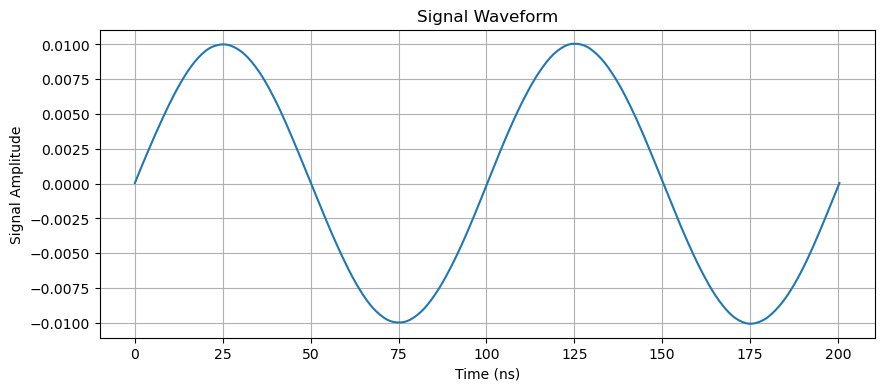

Forward simulation time: 5.66 s
Jacobian computation time: 10.33 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391749, adj=0.391752, ratio=1.0000
  t=50.23: fd=0.392730, adj=0.392733, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394046, ratio=1.0000
  t=200.41: fd=0.391749, adj=0.391752, ratio=1.0000
Forward simulation time: 5.55 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51086635e-08 -3.82949488e-03 -1.52217235e-02
 -3.38726893e-02]
FinDiff J[:,0] = [ 0.00302716 -0.0052621  -0.00116793 -0.01997387 -0.0296703 ]
Ratio: [0.00000000e+00 2.87122069e-06 3.27887781e+00 7.62081670e-01
 1.14163637e+00]
Forward simulation time: 5.88 s
Iter 96: res=0.060152, res_trial=0.060152, mu=1.000000e-08


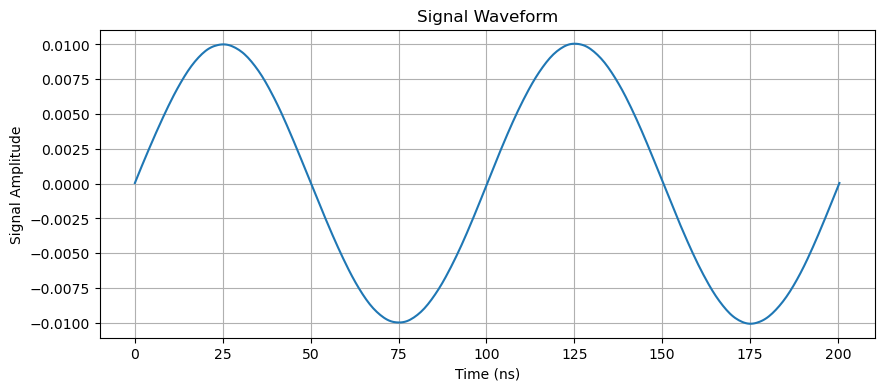

Forward simulation time: 5.29 s
Jacobian computation time: 10.20 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391748, adj=0.391751, ratio=1.0000
  t=50.23: fd=0.392730, adj=0.392733, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394043, adj=0.394047, ratio=1.0000
  t=200.41: fd=0.391748, adj=0.391751, ratio=1.0000
Forward simulation time: 5.84 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51086214e-08 -3.82948422e-03 -1.52216808e-02
 -3.38725953e-02]
FinDiff J[:,0] = [ 0.00383504 -0.00114201 -0.00270107 -0.01590909 -0.03749097]
Ratio: [0.00000000e+00 1.32298878e-05 1.41776750e+00 9.56791413e-01
 9.03486678e-01]
Forward simulation time: 5.62 s
Iter 97: res=0.060152, res_trial=0.060151, mu=1.000000e-08


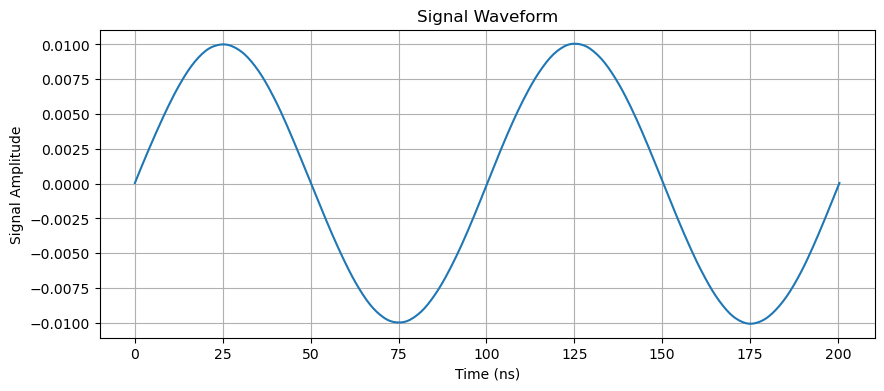

Forward simulation time: 5.63 s
Jacobian computation time: 10.11 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391747, adj=0.391750, ratio=1.0000
  t=50.23: fd=0.392731, adj=0.392734, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394044, adj=0.394047, ratio=1.0000
  t=200.41: fd=0.391747, adj=0.391750, ratio=1.0000
Forward simulation time: 5.21 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51085799e-08 -3.82947369e-03 -1.52216386e-02
 -3.38725025e-02]
FinDiff J[:,0] = [-0.00362096 -0.00466048 -0.00297923 -0.01571856 -0.03838359]
Ratio: [-0.00000000e+00  3.24185078e-06  1.28539242e+00  9.68386372e-01
  8.82473441e-01]
Forward simulation time: 5.72 s
Iter 98: res=0.060151, res_trial=0.060151, mu=1.000000e-08


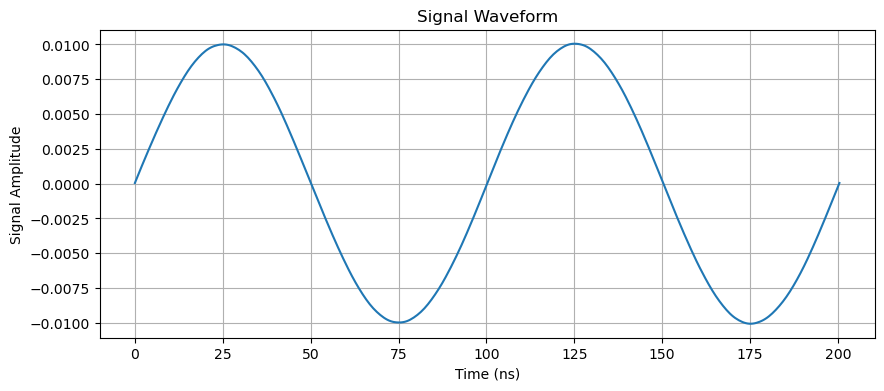

Forward simulation time: 5.43 s
Jacobian computation time: 9.76 s
=== Chain Rule 验证 ===
  t=0.00: fd=0.391746, adj=0.391749, ratio=1.0000
  t=50.23: fd=0.392731, adj=0.392734, ratio=1.0000
  t=100.46: fd=0.390688, adj=0.390691, ratio=1.0000
  t=150.68: fd=0.394044, adj=0.394047, ratio=1.0000
  t=200.41: fd=0.391746, adj=0.391749, ratio=1.0000
Forward simulation time: 5.70 s
dimension check:  (439, 99) (439,)
Adjoint J[:,0] = [ 0.00000000e+00 -1.51085387e-08 -3.82946327e-03 -1.52215967e-02
 -3.38724101e-02]
FinDiff J[:,0] = [ 0.00445718  0.00481143 -0.00211269 -0.02201798 -0.03451337]
Ratio: [ 0.00000000e+00 -3.14013436e-06  1.81259894e+00  6.91325788e-01
  9.81428684e-01]
Forward simulation time: 5.06 s
Iter 99: res=0.060151, res_trial=0.060151, mu=1.000000e-08


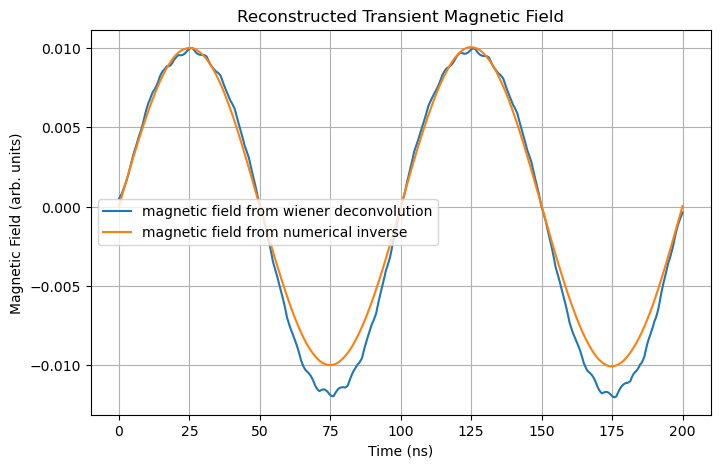

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


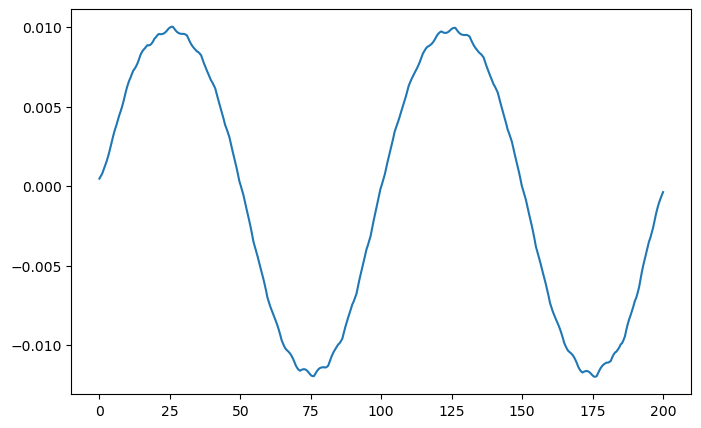

figure of the initial guess signal


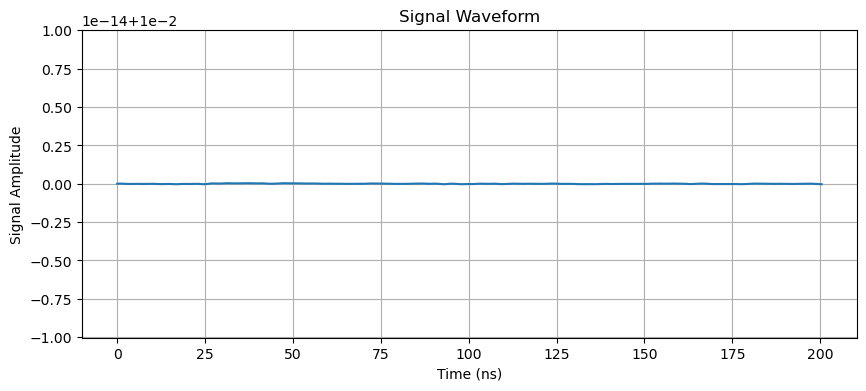

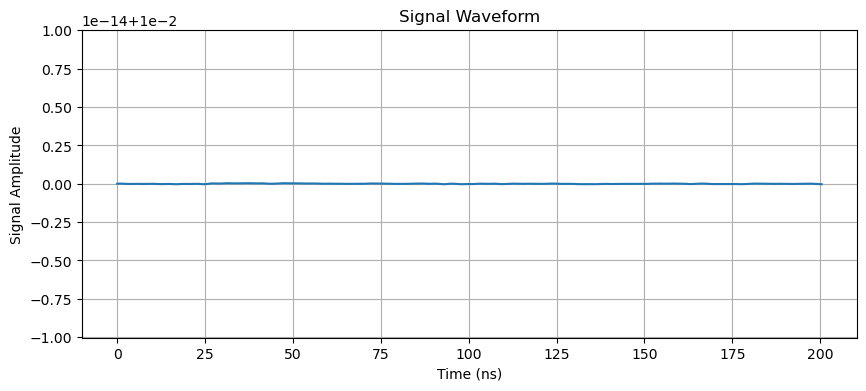

KeyboardInterrupt: 

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

data = joblib.load('temp_data.joblib')
qubit = data['qubit']
control_pulse = data['control_pulse']
p_meas = data['p_meas']
B_lists = data['B_lists']
B = data['B']
Phi = data['Phi']

analysis = Analysis()
plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.show()

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis, forward_simulation

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)


# Phi = Signal(type = 4, t_list = np.linspace(0, 200, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100)
# Phi.plot()
# result_test = forward_simulation(qubit, Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()

result_test = forward_simulation(qubit, control_pulse, Phi, scan_list, )
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit0 = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)
# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.1,
    state = 0,
    n_levels = 2
)
psi_e = basis(qubit.n_levels, 1)
H_0 = qubit.get_hamiltonian_rwa(qubit0.frequency)
t_rabi = np.linspace(0, 5, 100)
composite_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit0.frequency)
H_t = lambda t: H_0 + composite_pulse.get_hamiltonian(t)
result = mesolve(H_t, qubit.state, composite_pulse.t_list, [], e_ops=[psi_e * psi_e.dag()])
p_e = result.expect[0]

print(f"Final excited state probability: {p_e[-1]}")

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()

t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
kernel_roll = np.roll(kernel, -max_index)
t_max = t_samples[max_index]
t_shift = t_samples - t_max
t_roll = np.roll(t_shift, -max_index)

control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_shift]

t_Phi = np.linspace(0, 160, 100)
Phi = Signal(type = 2, t_list = t_Phi)
Phi_list = [Phi.value_at(t) for t in t_Phi]
dt = t_samples[1] - t_samples[0]

delta_p = dt * np.convolve(kernel, Phi_list, mode='full')  # 模拟等效时间采样测量结果，长度为A+B-1 

B = Analysis.wiener_deconvolution(delta_p, kernel, dt, lambdas = 0.0)

print(f'B: {B}')
#delta_p_new = np.convolve(kernel, B, mode='full')  # 用重建的B重新卷积得到测量结果 


plt.figure(figsize=(8, 5))
#plt.plot(t_Phi, Phi_list, label='Phi Signal')
plt.plot(t_Phi, B, label='Reconstructed B Field')
plt.xlabel('Time (ns)')
plt.ylabel('B Field (arb. units)')
plt.title('Reconstructed B Field from Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_samples,kernel_id, label='Ideal Kernel')
plt.plot(t_samples, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

# TODO
- 讨论这些idea的可行性，优先级，以及实现细节
- 完善瞬态磁场协议，增加灵敏度
    - 幅度问题：kernel，反卷积，信号项的系数（响应函数） [参考内容](https://arena.ai/c/019cf09a-0e16-784f-a01f-e8143027d668)
        - 解决：调整stim_pulse 幅度，lambda，使用非线性响应
    - 二阶响应：get_kernel函数和wiener_deconvolution函数中都默认了线性响应，扩展支持二阶响应[参考1](https://arena.ai/c/019d05bf-7b8a-7b86-bed0-a2ecc7924267)[参考2](idea/nonlinear_response_extension.md)
        - 该方法不支持存在负值的磁场。对于有突变函数，该方法可以修正磁场的幅值，
    - 利用优化算法还原磁场信号，如Levenbeig-Marquardt算法
    - 负磁场问题：当前只能测量单一方向的磁场，无法测量负磁场，考虑增加测量负磁场的协议，如添加检测磁场方向的参数。
- 增加更多协议，如spin echo, dynamical decoupling，PEA等 
    - PEA[参考内容](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)[参考2](https://arena.ai/c/019d3830-65e0-700e-960f-376e49b26cd4)
    - 基于微分的传感协议[参考1](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)[参考2](https://arena.ai/c/019d058c-0104-75ba-b70b-b9dac257dfcf)[参考3](https://arena.ai/c/019d058b-7ccd-7b38-98f7-32e97af73ae9)[参考4](idea/differential_sensing_scheme.md)[参考5](https://arena.ai/c/019d3830-65e0-700e-960f-376e49b26cd4)
- 增加实际情况的模拟，如噪声、非理想脉冲等
- 优化程序结构，优化各个模块的接口设计，以及模块内部的实现细节，使得代码更清晰易懂，易于维护和扩展
    - 如，全局统一时间间隔，将数值列表转换为numpy数组，统一使用numpy数组进行计算等
    - 统一全局时间轴，避免在不同模块中使用不同的时间列表，导致混乱和错误
- 优化程序效率，如使用GPU加速，优化算法，使用joblib进行并行计算，以及优化mesolve的传入量，避免用lambda等[参考](https://arena.ai/c/019d38a2-eda2-7dc0-bfb1-200f52db8e0f)
    - 传入函数
        - 解决：
            - 对重复调用的函数和列表进行预计算
            - 避免使用Python对象，如Python回调函数，Qobj等，尽量使用qutip的列表函数和numpy数组等
    - GPU加速，算法优化，joblib
- 完善demo，增加交互性
- 撰写README.md
<!-- - 实验室实习 [参考内容](https://arena.ai/c/019cf0a9-ca57-7e1e-bdd9-b0d7ea303a19)
-->

# TODO in detail
- 完善瞬态磁场传感，生成报告图表
    - 全密度矩阵模拟
    - 正负磁场
- 加噪声
- 实现ramsey，spin echo，CPMG协议，并比较其对于噪声和能级泄露的优势
- 实现差分回波协议[参考](https://arena.ai/c/019d7121-a5db-797d-bb40-6b9a0c370a39)
- 综合比较以上所有协议在Transmon qubit上的性能，包括时间分辨率，灵敏度等
- spinecho和现有的滑动测量结合，发挥spinecho可以得到磁场导数的优势（微分传感，选做）
- 并行优化，代码结构优化，demo实现
- 结题报告

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)


t_rabi = np.linspace(0, 40, 100)
Phi = Signal(type = 2, t_list = t_rabi, amplitude = 0.1)
noise = qubit.generate_1f_noise(t_rabi, amplitude=0.001, f_min=1e-3, f_max=1e3)
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, noise+Phi.signal, label='1/f Noise')
#plt.ylim(0.1-0.01, 0.1+0.01)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude (arb. units)')
plt.title('Generated 1/f Noise')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
t_rabi =  np.linspace(0, 200, 400)
Phi = Signal(type = 4, t_list = np.linspace(0, 200, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100)
Phi.plot()
B = (1 / np.pi) * np.arccos((0.000001 + qubit.frequency + qubit.EC) ** 2 / (8 * qubit.EC * qubit.EJ))  # 根据Transmon的频率-磁场关系，得到磁场响应
print(f'B: {B} ')
'''
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, B, label='B Field from Phi')
plt.xlabel('Time (ns)') 
plt.ylabel('B Field (arb. units)')
plt.title('B Field from Phi Signal')
plt.grid()
plt.show()
'''

In [ ]:
import qutip as qt
print(qt.__version__)  # 5.2.0

# 简单测试
H = qt.sigmaz()
psi0 = qt.basis(2, 0)
tlist = [0, 0.1]

# 不设 options
result1 = qt.mesolve(H, psi0, tlist, [], [])
print(f"Without options: {result1.states[0].shape}")  # 应该是 (2,2)

# 设 options
options = qt.Options(store_states=True)
result2 = qt.mesolve(H, psi0, tlist, [], [], options=options)
print(f"With options: {result2.states[0].shape}")  # 应该是 (2,2)

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


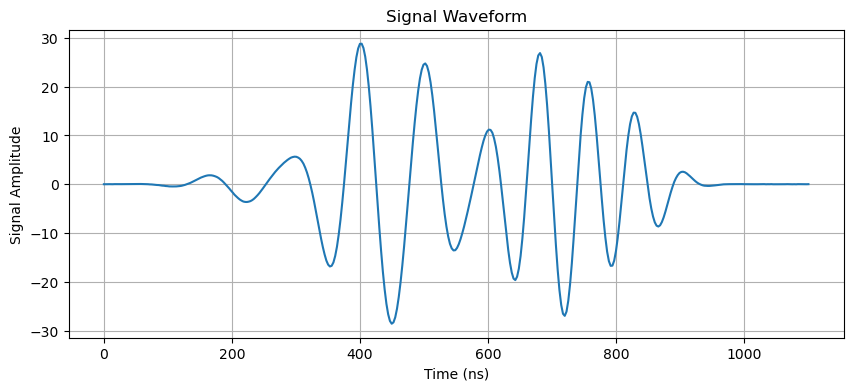

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

Phi = Signal(type = 7, t_list = np.linspace(0, 1100, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100, noise_level = 0.01)
Phi.plot()

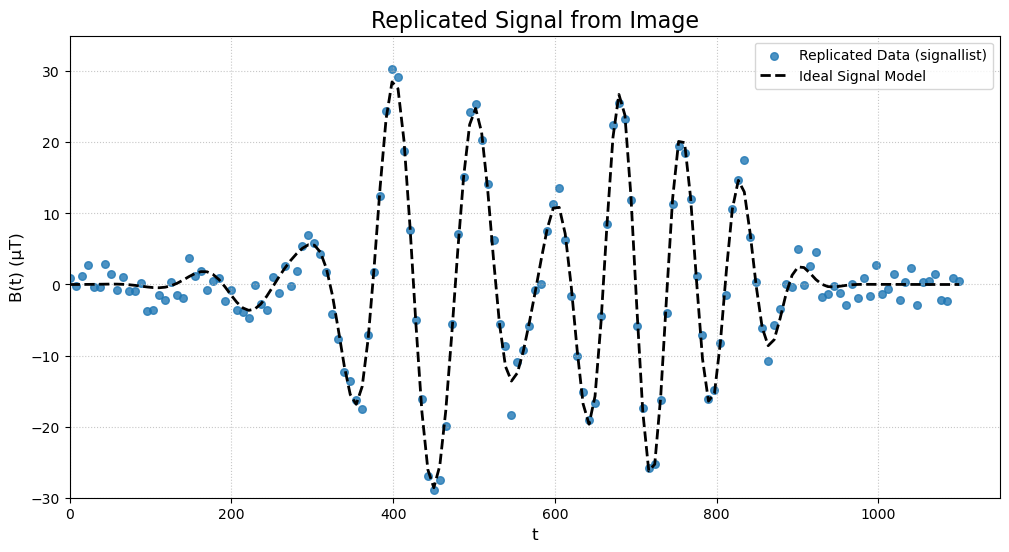

--- Generated tlist ---
tlist = [0.00, 7.38, 14.77, 22.15, 29.53, 36.91, 44.30, 51.68, 59.06, 66.44, 73.83, 81.21, 88.59, 95.97, 103.36, 110.74, 118.12, 125.50, 132.89, 140.27, 147.65, 155.03, 162.42, 169.80, 177.18, 184.56, 191.95, 199.33, 206.71, 214.09, 221.48, 228.86, 236.24, 243.62, 251.01, 258.39, 265.77, 273.15, 280.54, 287.92, 295.30, 302.68, 310.07, 317.45, 324.83, 332.21, 339.60, 346.98, 354.36, 361.74, 369.13, 376.51, 383.89, 391.28, 398.66, 406.04, 413.42, 420.81, 428.19, 435.57, 442.95, 450.34, 457.72, 465.10, 472.48, 479.87, 487.25, 494.63, 502.01, 509.40, 516.78, 524.16, 531.54, 538.93, 546.31, 553.69, 561.07, 568.46, 575.84, 583.22, 590.60, 597.99, 605.37, 612.75, 620.13, 627.52, 634.90, 642.28, 649.66, 657.05, 664.43, 671.81, 679.19, 686.58, 693.96, 701.34, 708.72, 716.11, 723.49, 730.87, 738.26, 745.64, 753.02, 760.40, 767.79, 775.17, 782.55, 789.93, 797.32, 804.70, 812.08, 819.46, 826.85, 834.23, 841.61, 848.99, 856.38, 863.76, 871.14, 878.52, 885.91, 893.29, 900.67,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义生成信号的函数 ---

def generate_replicated_signal(num_points=150, noise_level=1.8, seed=42):
    """
    生成复现的信号数据。

    参数:
    num_points (int): 数据点的数量。
    noise_level (float): 添加的高斯噪声的标准差 (sigma)。
    seed (int): 随机数种子，用于保证结果可复现。

    返回:
    tuple: (tlist, signallist)，分别为时间列表和信号列表。
    """
    
    # 定义高斯调制余弦波包的辅助函数
    def wave_packet(t, A, t0, w, f, phi):
        """
        t: 时间数组
        A: 振幅
        t0: 波包中心时间
        w: 高斯包络的宽度 (标准差)
        f: 频率
        phi: 相位
        """
        return A * np.exp(-(t - t0)**2 / (2 * w**2)) * np.cos(2 * np.pi * f * (t - t0) + phi)

    # --- 2. 创建时间轴 (tlist) ---
    tlist = np.linspace(0, 1100, num_points)

    # --- 3. 构建理想信号 (黑色虚线) ---
    # 通过叠加5个不同的波包来模拟复杂信号
    # 参数 (A, t0, w, f, phi) 是根据原始图像目测估算的

    # 第一个大波包 (t≈400)
    p1 = wave_packet(tlist, A=30, t0=420, w=60, f=0.01, phi=0.4 * np.pi)
    
    # 第二个大波包 (t≈700)
    p2 = wave_packet(tlist, A=28, t0=700, w=70, f=0.0125, phi=0.5 * np.pi)

    # 中间的次级波包 (t≈500)
    p3 = wave_packet(tlist, A=14, t0=515, w=35, f=0.011, phi=0.25 * np.pi)

    # 右侧的次级波包 (t≈820)
    p4 = wave_packet(tlist, A=12, t0=825, w=45, f=0.012, phi=0)

    # 初始的小波包 (t≈250)
    p5 = wave_packet(tlist, A=4.0, t0=250, w=70, f=0.0083, phi=1.5 * np.pi)

    # 将所有波包相加得到最终的理想信号
    signal_ideal = p1 + p2 + p3 + p4 + p5

    # --- 4. 添加高斯噪声 ---
    # 设置随机数种子以确保每次运行结果相同
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
    
    # 最终的信号列表 (蓝色数据点)
    signallist = signal_ideal + noise
    
    return tlist, signallist, signal_ideal

# --- 5. 生成数据并绘制图像以供验证 ---
tlist, signallist, signal_ideal = generate_replicated_signal()

# 绘制复现的信号图
plt.figure(figsize=(12, 6))
plt.scatter(tlist, signallist, s=30, alpha=0.8, label='Replicated Data (signallist)')
plt.plot(tlist, signal_ideal, 'k--', linewidth=2, label='Ideal Signal Model')
plt.title("Replicated Signal from Image", fontsize=16)
plt.xlabel("t", fontsize=12)
plt.ylabel("B(t) (μT)", fontsize=12)
plt.xlim(0, 1150)
plt.ylim(-30, 35)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# --- 6. 打印生成的 tlist 和 signallist ---
# 为了方便复制，将列表格式化输出
print("--- Generated tlist ---")
print("tlist = [", end="")
print(*[f"{t:.2f}" for t in tlist], sep=", ", end="]\n\n")

print("--- Generated signallist ---")
print("signallist = [", end="")
print(*[f"{val:.4f}" for val in signallist], sep=", ", end="]\n")